# การวิเคราะห์ภาพรวมการจัดซื้อจัดจ้างภาครัฐ

Notebook สำหรับวิเคราะห์ข้อมูล กราฟ overview

> วิธีใช้กับปีอื่น: เปลี่ยนค่า `YEAR` ในเซลล์ **SETUP** ด้านล่างเพียงจุดเดียว เช่น `2568` หรือ `2569` แล้วเลือก **Runtime → Run all** ใน Google Colab


## GitHub / Display-only version

Notebook นี้อ่านข้อมูลตาม `YEAR` และแสดงกราฟหรือตารางภายใน Notebook เท่านั้น โดยไม่บันทึกไฟล์ผลลัพธ์ลงเครื่องของผู้รัน

ก่อนรัน ให้กำหนด `BASE_OUTPUT_PATH` ในเซลล์ PARAMETERS ให้ชี้ไปยังโฟลเดอร์ที่มีข้อมูล 3 ไฟล์ของปีที่เลือก:

- `project_overview_{YEAR}.csv`
- `analysis_output/07_top10_project_budget_{YEAR}.csv`
- `analysis_output/07_lower10_project_budget_{YEAR}.csv`

ไฟล์ข้อมูลขนาดใหญ่ไม่ได้รวมอยู่ใน Repository ผู้รันต้องเตรียมข้อมูลไว้ในเครื่อง, Colab Runtime หรือ Google Drive ของตนเอง


In [1]:
# ============================================================
# PARAMETERS : เปลี่ยนปีและตำแหน่งข้อมูลจาก Cell นี้เพียงจุดเดียว
# ============================================================

YEAR = 2567  # เปลี่ยนเป็น 2567, 2568, 2569 หรือปีอื่นที่มีโครงสร้างไฟล์เดียวกัน

# False = ใช้ข้อมูลจากโฟลเดอร์ในเครื่องหรือ Colab Runtime
# True  = Mount Google Drive ของผู้รัน แล้วอ่านข้อมูลจาก Path ที่กำหนดด้านล่าง
USE_GOOGLE_DRIVE = True

# ค่าเริ่มต้นสำหรับ Repository: วางข้อมูลไว้ใน ./data/overview_output
# หากข้อมูลอยู่ตำแหน่งอื่น ให้แก้ BASE_OUTPUT_PATH เพียงบรรทัดนี้
#BASE_OUTPUT_PATH = "./data/overview_output"

# ตัวอย่างเมื่อใช้ Google Drive ของผู้รัน:
# USE_GOOGLE_DRIVE = True
BASE_OUTPUT_PATH = "/content/drive/MyDrive/DADS5001/project_1_dads5001/notebook/overview_output"

# GitHub Version แสดงกราฟและตารางใน Notebook เท่านั้น
# ไม่มีการบันทึก SVG, PNG, CSV, JSON หรือสร้างโฟลเดอร์ผลลัพธ์
SAVE_OUTPUTS = False


In [2]:
# ============================================================
# SETUP : Google Drive, Libraries, ตำแหน่งไฟล์ และฟอนต์ภาษาไทย
# ============================================================

# เชื่อมต่อ Google Drive เฉพาะเมื่อผู้รันเลือก USE_GOOGLE_DRIVE = True
# Notebook จึงสามารถเปิดจาก GitHub แล้วใช้กับ Local Jupyter หรือ Colab ได้
if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
    except ImportError as error:
        raise RuntimeError(
            "USE_GOOGLE_DRIVE=True ใช้ได้เมื่อรันบน Google Colab เท่านั้น"
        ) from error

    drive.mount("/content/drive")

# Import Libraries ที่ใช้ตลอดทั้ง Notebook ไว้เพียงจุดเดียว
import gc
import os
import tempfile
import textwrap
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.table import Table
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator


# ============================================================
# ตำแหน่งไฟล์ตามปีงบประมาณที่กำหนดในเซลล์ PARAMETERS
# ============================================================

year_path = os.path.join(BASE_OUTPUT_PATH, str(YEAR))
output_path = os.path.join(year_path, "analysis_output")
figure_path = os.path.join(output_path, "figures")

# ข้อมูลนำเข้าหลัก 3 ไฟล์จะเปลี่ยนตาม YEAR โดยอัตโนมัติ
project_overview_file = os.path.join(
    year_path,
    f"project_overview_{YEAR}.csv"
)

top10_budget_file = os.path.join(
    output_path,
    f"07_top10_project_budget_{YEAR}.csv"
)

lower10_budget_file = os.path.join(
    output_path,
    f"07_lower10_project_budget_{YEAR}.csv"
)

# เก็บ Path ไว้ใน Dictionary เพื่อให้ตรวจสอบไฟล์ได้ในจุดเดียว
input_files = {
    "project_overview": project_overview_file,
    "top10_project_budget": top10_budget_file,
    "lower10_project_budget": lower10_budget_file
}

# คง Alias เดิมไว้เพื่อให้ Code ส่วนเก่าที่อ้าง csv_file_path ยังทำงานได้
csv_file_path = project_overview_file

# GitHub Version ไม่สร้าง output_path หรือ figure_path
# ตัวแปรทั้งสองยังคงใช้คำนวณตำแหน่งไฟล์ข้อมูล Top 10 และ Lower 10


def figure_files(file_stem):
    # สร้าง Path ของไฟล์ SVG และ PNG โดยเติมปีงบประมาณให้อัตโนมัติ
    svg_path = os.path.join(figure_path, f"{file_stem}_{YEAR}.svg")
    png_path = os.path.join(figure_path, f"{file_stem}_{YEAR}.png")
    return svg_path, png_path


# ============================================================
# ฟอนต์ภาษาไทยสำหรับ Google Colab
# ============================================================

font_path = os.path.join(tempfile.gettempdir(), "NotoSansThai.ttf")
font_url = (
    "https://raw.githubusercontent.com/google/fonts/main/"
    "ofl/notosansthai/NotoSansThai%5Bwdth%2Cwght%5D.ttf"
)

# ดาวน์โหลดเฉพาะเมื่อยังไม่มีไฟล์ฟอนต์ใน Colab Runtime
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

font_manager.fontManager.addfont(font_path)
thai_font = font_manager.FontProperties(fname=font_path).get_name()

# ตั้งค่าการแสดงภาษาไทยและทำตัวอักษรใน SVG เป็น Vector Path
plt.rcParams["font.family"] = thai_font
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["svg.fonttype"] = "path"

print(f"ปีงบประมาณที่เลือก : {YEAR}")
print("Input files:")
for input_name, input_path in input_files.items():
    print(f"- {input_name}: {input_path}")
print("Analysis data path :", output_path)
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


Mounted at /content/drive
ปีงบประมาณที่เลือก : 2567
Input files:
- project_overview: /content/drive/MyDrive/DADS5001/project_1_dads5001/notebook/overview_output/2567/project_overview_2567.csv
- top10_project_budget: /content/drive/MyDrive/DADS5001/project_1_dads5001/notebook/overview_output/2567/analysis_output/07_top10_project_budget_2567.csv
- lower10_project_budget: /content/drive/MyDrive/DADS5001/project_1_dads5001/notebook/overview_output/2567/analysis_output/07_lower10_project_budget_2567.csv
Analysis data path : /content/drive/MyDrive/DADS5001/project_1_dads5001/notebook/overview_output/2567/analysis_output


In [3]:
# ============================================================
# IMPORT : ข้อมูลภาพรวมการจัดซื้อจัดจ้าง
# ============================================================

# ตรวจสอบข้อมูลนำเข้าทั้ง 3 ไฟล์ก่อนโหลด project_overview ซึ่งมีขนาดใหญ่
# เพื่อให้ทราบไฟล์ที่ขาดทันทีโดยไม่เสีย RAM และเวลา Import โดยไม่จำเป็น
missing_input_files = {
    input_name: input_path
    for input_name, input_path in input_files.items()
    if not os.path.exists(input_path)
}

if missing_input_files:
    missing_file_message = "\n".join(
        f"- {input_name}: {input_path}"
        for input_name, input_path in missing_input_files.items()
    )
    raise FileNotFoundError(
        "ไม่พบข้อมูลนำเข้าที่จำเป็นสำหรับปีงบประมาณ "
        f"{YEAR}:\n{missing_file_message}\n"
        "กรุณาตรวจสอบค่า YEAR และตำแหน่งไฟล์ใน Google Drive"
    )

# โหลดเฉพาะ Features ที่ใช้ใน Notebook เพื่อควบคุมการใช้ RAM
required_columns = [
    "รหัสโครงการ",
    "ชื่อประเภทโครงการ",
    "ชื่อหน่วยงาน",
    "สังกัด",
    "วงเงินงบประมาณ (บาท)",
    "ราคากลาง (บาท)",
    "ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)",
    "จังหวัด",
    "เขต/อำเภอ",
    "สถานะโครงการ",
    "dept_match_status",
    "จำนวนผู้ชนะ"
]

# กำหนดรหัสโครงการเป็น String เพราะเป็น Identifier ไม่ใช่ตัวเลขสำหรับคำนวณ
# คอลัมน์ข้อความที่มีค่าซ้ำจำนวนมากใช้ Category เพื่อลดการใช้หน่วยความจำ
column_dtypes = {
    "รหัสโครงการ": "string",
    "ชื่อประเภทโครงการ": "category",
    "ชื่อหน่วยงาน": "category",
    "สังกัด": "category",
    "จังหวัด": "category",
    "เขต/อำเภอ": "category",
    "สถานะโครงการ": "category",
    "dept_match_status": "category",
    "จำนวนผู้ชนะ": "int32"
}

required_column_set = set(required_columns)

project_overview_df = pd.read_csv(
    project_overview_file,
    usecols=lambda column: column.strip() in required_column_set,
    dtype=column_dtypes,
    low_memory=True
)

# ลบช่องว่างที่อาจแฝงอยู่หน้าหรือท้ายชื่อคอลัมน์ของข้อมูลต้นฉบับ
project_overview_df.columns = project_overview_df.columns.str.strip()

# ตรวจสอบเฉพาะ Features หลักที่ทุกส่วนวิเคราะห์ต้องใช้
missing_columns = [
    column for column in required_columns
    if column not in project_overview_df.columns
]

if missing_columns:
    raise KeyError(
        "ข้อมูลขาดคอลัมน์ที่จำเป็น: " + ", ".join(missing_columns)
    )

print(f"Import สำเร็จ: {len(project_overview_df):,} แถว")
print("✅ ตรวจพบข้อมูลนำเข้าครบทั้ง 3 ไฟล์")


Import สำเร็จ: 5,428,289 แถว
✅ ตรวจพบข้อมูลนำเข้าครบทั้ง 3 ไฟล์


## ตรวจสอบโครงสร้างข้อมูล


In [4]:
# ============================================================
# แสดง Feature + Data Type + Missing
# ============================================================

# สร้างตารางสรุปโครงสร้างของ DataFrame
feature_summary_df = pd.DataFrame({
    "Feature": project_overview_df.columns,
    "Data Type": project_overview_df.dtypes.astype(str).values,
    "จำนวน Missing": project_overview_df.isna().sum().values
})

# คำนวณร้อยละของ Missing ในแต่ละ Feature
feature_summary_df["ร้อยละ Missing"] = (
    feature_summary_df["จำนวน Missing"] / len(project_overview_df) * 100
).round(4)

display(feature_summary_df)


,Feature,Data Type,จำนวน Missing,ร้อยละ Missing
0,รหัสโครงการ,string,0,0.0000
1,ชื่อประเภทโครงการ,category,0,0.0000
2,ชื่อหน่วยงาน,category,0,0.0000
3,สังกัด,category,178562,3.2895
4,วงเงินงบประมาณ (บาท),float64,0,0.0000
5,ราคากลาง (บาท),float64,32178,0.5928
6,ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงกา...,float64,0,0.0000
7,จังหวัด,category,219,0.0040
8,เขต/อำเภอ,category,219,0.0040
9,สถานะโครงการ,category,0,0.0000


## Analysis 1 — ตัวเลขภาพรวม


In [5]:
# ============================================================
# ANALYSIS 1 : ภาพรวมการจัดซื้อจัดจ้างตามปีงบประมาณที่เลือก
# ============================================================


# กำหนดชื่อคอลัมน์ไว้เป็นตัวแปร เพื่อให้ Code ด้านล่างอ่านง่าย
budget_col = "วงเงินงบประมาณ (บาท)"
agreed_col = "ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)"

# นับจำนวนโครงการทั้งหมด
# ข้อมูลนี้เป็น 1 Project = 1 Row ดังนั้นจำนวนแถว = จำนวนโครงการ
total_projects = len(project_overview_df)

# รวมวงเงินงบประมาณของทุกโครงการ
total_budget = project_overview_df[budget_col].sum()

# รวมราคาที่ตกลงซื้อ / จ้างของทุกโครงการ
total_agreed = project_overview_df[agreed_col].sum()

# คำนวณส่วนต่างระหว่างวงเงินที่ตั้งไว้กับราคาที่ตกลงซื้อ / จ้าง
# หมายเหตุ: ค่านี้ไม่เรียกว่า "Saving" เพราะวงเงินงบประมาณไม่ใช่ราคากลาง
budget_agreed_gap = total_budget - total_agreed

# คำนวณว่าราคาตกลงรวมคิดเป็นกี่เปอร์เซ็นต์ของวงเงินงบประมาณรวม
agreed_budget_percent = total_agreed / total_budget * 100

# หาค่าเฉลี่ยและค่ามัธยฐานของวงเงินงบประมาณต่อโครงการ
mean_budget = project_overview_df[budget_col].mean()
median_budget = project_overview_df[budget_col].median()

# หาวงเงินงบประมาณต่ำสุดและสูงสุด
min_budget = project_overview_df[budget_col].min()
max_budget = project_overview_df[budget_col].max()

# หา "ทั้งแถว" ของโครงการที่มีวงเงินต่ำสุดและสูงสุด
# idxmin() / idxmax() หา Index แล้ว .loc ใช้ดึงข้อมูลทั้งแถวนั้น
min_project = project_overview_df.loc[project_overview_df[budget_col].idxmin()]
max_project = project_overview_df.loc[project_overview_df[budget_col].idxmax()]


In [6]:
# ============================================================
# แสดงผลตัวเลขภาพรวม
# ============================================================

print("=" * 90)
print(f"ภาพรวมการจัดซื้อจัดจ้างภาครัฐ ปีงบประมาณ {YEAR}")
print("=" * 90)

# ภาพรวมจำนวนโครงการและมูลค่า
print(f"จำนวนโครงการทั้งหมด               : {total_projects:,.0f} โครงการ")
print(f"วงเงินงบประมาณรวม                  : {total_budget:,.2f} บาท")
print(f"                                     ({total_budget / 1_000_000_000:,.2f} พันล้านบาท)")
print(f"ราคาที่ตกลงซื้อ / จ้างรวม           : {total_agreed:,.2f} บาท")
print(f"                                     ({total_agreed / 1_000_000_000:,.2f} พันล้านบาท)")

print("-" * 90)

# เปรียบเทียบวงเงินงบประมาณกับราคาที่ตกลง
print(f"ส่วนต่างวงเงินกับราคาตกลง           : {budget_agreed_gap:,.2f} บาท")
print(f"ราคาตกลงคิดเป็น                     : {agreed_budget_percent:.2f}% ของวงเงินงบประมาณรวม")

print("-" * 90)

# แสดงค่ากลางของขนาดโครงการ
print(f"งบประมาณเฉลี่ยต่อโครงการ            : {mean_budget:,.2f} บาท")
print(f"มัธยฐานงบประมาณต่อโครงการ          : {median_budget:,.2f} บาท")

print("-" * 90)

# แสดงโครงการที่มีวงเงินต่ำสุด พร้อมประเภทโครงการและหน่วยงาน
print(f"งบประมาณต่ำสุด                      : {min_budget:,.2f} บาท")
print(f"  ประเภทโครงการ                     : {min_project['ชื่อประเภทโครงการ']}")
print(f"  หน่วยงาน                           : {min_project['ชื่อหน่วยงาน']}")

print()

# แสดงโครงการที่มีวงเงินสูงสุด พร้อมประเภทโครงการและหน่วยงาน
print(f"งบประมาณสูงสุด                      : {max_budget:,.2f} บาท")
print(f"  ประเภทโครงการ                     : {max_project['ชื่อประเภทโครงการ']}")
print(f"  หน่วยงาน                           : {max_project['ชื่อหน่วยงาน']}")


ภาพรวมการจัดซื้อจัดจ้างภาครัฐ ปีงบประมาณ 2567
จำนวนโครงการทั้งหมด               : 5,428,289 โครงการ
วงเงินงบประมาณรวม                  : 1,243,189,989,284.88 บาท
                                     (1,243.19 พันล้านบาท)
ราคาที่ตกลงซื้อ / จ้างรวม           : 1,171,653,828,954.19 บาท
                                     (1,171.65 พันล้านบาท)
------------------------------------------------------------------------------------------
ส่วนต่างวงเงินกับราคาตกลง           : 71,536,160,330.69 บาท
ราคาตกลงคิดเป็น                     : 94.25% ของวงเงินงบประมาณรวม
------------------------------------------------------------------------------------------
งบประมาณเฉลี่ยต่อโครงการ            : 229,020.60 บาท
มัธยฐานงบประมาณต่อโครงการ          : 20,650.00 บาท
------------------------------------------------------------------------------------------
งบประมาณต่ำสุด                      : 40.65 บาท
  ประเภทโครงการ                     : ซื้อ
  หน่วยงาน                           : องค์การบริหารส่วนตำบลวัง

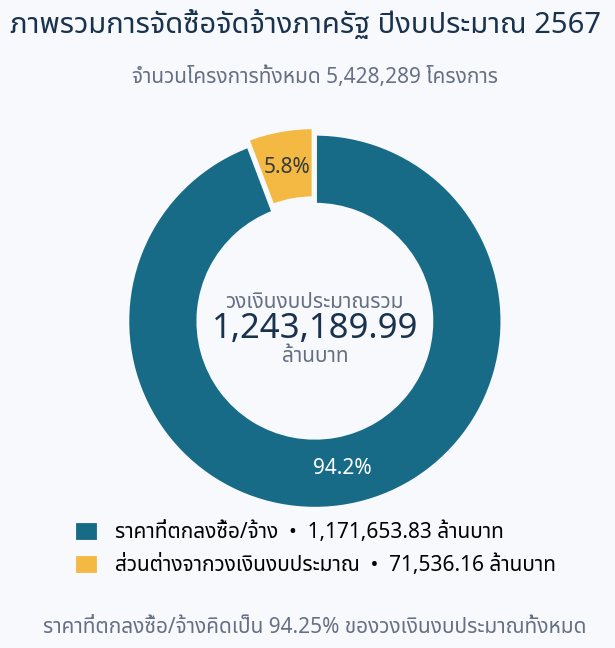

In [7]:
# ============================================================
# GRAPH 1 : ภาพรวมวงเงินงบประมาณและราคาที่ตกลงซื้อ/จ้าง
# ============================================================

svg_file, png_file = figure_files("01_procurement_overview_donut")

# =========================================================
# 2) ข้อมูลการจัดซื้อจัดจ้าง
# =========================================================

# ส่วนต่างระหว่างวงเงินงบประมาณกับราคาที่ตกลง
budget_difference = budget_agreed_gap

values = [total_agreed, budget_difference]

labels = [
    "ราคาที่ตกลงซื้อ/จ้าง",
    "ส่วนต่างจากวงเงินงบประมาณ"
]

colors = ["#176B87", "#F4B942"]


# =========================================================
# 3) สร้างกราฟโดนัท
# =========================================================
fig, ax = plt.subplots(figsize=(7.5, 7), facecolor="#F7F9FC")
ax.set_facecolor("#F7F9FC")

wedges, _, percentage_texts = ax.pie(
    values,
    colors=colors,
    startangle=90,
    counterclock=False,
    explode=(0, 0.035),
    autopct=lambda pct: f"{pct:,.1f}%",
    pctdistance=0.80,
    wedgeprops={
        "width": 0.38,
        "edgecolor": "#F7F9FC",
        "linewidth": 3
    }
)

# ปรับข้อความเปอร์เซ็นต์ให้อ่านง่าย
for i, text in enumerate(percentage_texts):
    text.set_fontsize(15)
    text.set_fontweight("bold")
    text.set_color("white" if i == 0 else "#343A40")


# =========================================================
# 4) ข้อความตรงกลางกราฟ
# =========================================================
ax.text(
    0, 0.10,
    "วงเงินงบประมาณรวม",
    ha="center",
    va="center",
    fontsize=15,
    color="#667085"
)

ax.text(
    0, -0.04,
    f"{total_budget / 1e6:,.2f}",
    ha="center",
    va="center",
    fontsize=25,
    fontweight="bold",
    color="#19324D"
)

ax.text(
    0, -0.19,
    "ล้านบาท",
    ha="center",
    va="center",
    fontsize=15,
    color="#667085"
)


# =========================================================
# 5) ชื่อกราฟและรายละเอียด
# =========================================================
fig.suptitle(
    f"ภาพรวมการจัดซื้อจัดจ้างภาครัฐ ปีงบประมาณ {YEAR}",
    fontsize=21,
    fontweight="bold",
    color="#19324D",
    y=0.96
)

ax.set_title(
    f"จำนวนโครงการทั้งหมด {total_projects:,.0f} โครงการ",
    fontsize=15,
    color="#667085",
    pad=18
)

legend_labels = [
    f"{labels[0]}  •  {total_agreed / 1e6:,.2f} ล้านบาท",
    f"{labels[1]}  •  {budget_difference / 1e6:,.2f} ล้านบาท"
]

ax.legend(
    wedges,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=1,
    frameon=False,
    fontsize=15,
    handlelength=1.2,
    handleheight=1.2
)

ax.text(
    0.5, -0.25,
    "ราคาที่ตกลงซื้อ/จ้างคิดเป็น "
    f"{total_agreed / total_budget * 100:,.2f}% ของวงเงินงบประมาณทั้งหมด",
    transform=ax.transAxes,
    ha="center",
    fontsize=15,
    color="#667085"
)

# =========================================================
# 6) ปรับ Layout และบันทึกกราฟ
# =========================================================

ax.axis("equal")
plt.subplots_adjust(
    top=0.82,
    bottom=0.22
)

# บันทึก SVG — ขยายโดยไม่แตก
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

# บันทึก PNG ความละเอียดสูง
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

# แสดงกราฟใน Colab
plt.show()
plt.close(fig)

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

print()

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


## Analysis 2 — สรุปตามประเภทโครงการ


In [8]:
# ============================================================
# ANALYSIS 2 : สรุปข้อมูลตามประเภทโครงการ
# ============================================================

# สร้างตารางใหม่จาก project_overview_df ทุกครั้ง
# groupby() = รวมโครงการที่มี "ชื่อประเภทโครงการ" เดียวกันไว้ด้วยกัน
project_type_df = project_overview_df.groupby("ชื่อประเภทโครงการ", dropna=False).agg(
    project_count=("รหัสโครงการ", "size"),                 # จำนวนโครงการ
    total_budget=("วงเงินงบประมาณ (บาท)", "sum"),          # วงเงินรวม
    average_budget=("วงเงินงบประมาณ (บาท)", "mean")        # วงเงินเฉลี่ย
).reset_index()

# ใช้จำนวนโครงการและวงเงินรวมจาก Analysis 1 เป็นฐานในการหาร้อยละ
# ตัวแปรทั้งสองคำนวณไว้แล้ว จึงไม่ต้องรวมข้อมูลขนาดใหญ่ซ้ำอีกครั้ง

# คำนวณสัดส่วนของแต่ละประเภทเมื่อเทียบกับข้อมูลทั้งหมด
project_type_df["project_share"] = project_type_df["project_count"] / total_projects * 100
project_type_df["budget_share"] = project_type_df["total_budget"] / total_budget * 100

# เรียงจากประเภทที่มีจำนวนโครงการมากที่สุดไปน้อยที่สุด
project_type_df = project_type_df.sort_values("project_count", ascending=False).reset_index(drop=True)

# เปลี่ยนชื่อคอลัมน์เป็นภาษาไทย หลังจากคำนวณและเรียงข้อมูลเสร็จแล้ว
project_type_df = project_type_df.rename(columns={
    "project_count": "จำนวนโครงการ",
    "total_budget": "วงเงินรวม (บาท)",
    "average_budget": "วงเงินเฉลี่ย (บาท)",
    "project_share": "สัดส่วนจำนวนโครงการ (ร้อยละ)",
    "budget_share": "สัดส่วนวงเงิน (ร้อยละ)"
})

# แสดงตาราง
display(project_type_df)


/tmp/ipykernel_742/1226239224.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  project_type_df = project_overview_df.groupby("ชื่อประเภทโครงการ", dropna=False).agg(


,ชื่อประเภทโครงการ,จำนวนโครงการ,วงเงินรวม (บาท),วงเงินเฉลี่ย (บาท),สัดส่วนจำนวนโครงการ (ร้อยละ),สัดส่วนวงเงิน (ร้อยละ)
0,ซื้อ,3433701,4.637816e+11,1.350676e+05,63.255678,37.305770
1,จ้างทำของ/จ้างเหมาบริการ,1631402,2.187885e+11,1.341108e+05,30.053706,17.598963
2,จ้างก่อสร้าง,302830,5.226767e+11,1.725974e+06,5.578738,42.043185
3,เช่า,56579,2.741270e+10,4.845032e+05,1.042299,2.205029
4,จ้างออกแบบ,1995,1.937503e+09,9.711797e+05,0.036752,0.155849
5,จ้างที่ปรึกษา,1491,7.740430e+09,5.191435e+06,0.027467,0.622626
6,จ้างควบคุมงาน,205,8.000731e+08,3.902795e+06,0.003777,0.064356
7,จ้างออกแบบและควบคุมงานก่อสร้าง,86,5.246550e+07,6.100640e+05,0.001584,0.004220


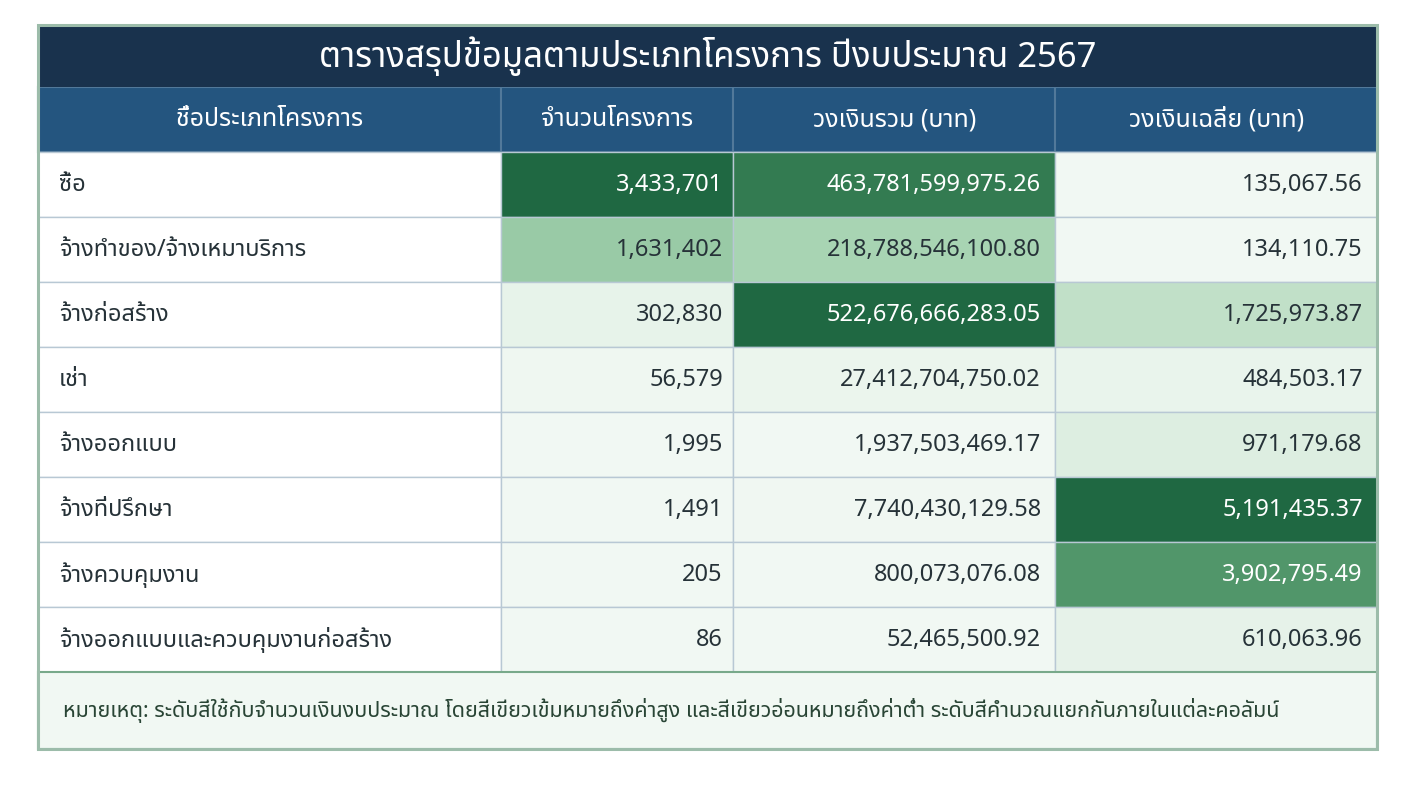

In [9]:
# ============================================================
# TABLE 2 : สรุปข้อมูลตามประเภทโครงการ
# ============================================================

svg_file, png_file = figure_files("03_project_type_summary_table")

# ============================================================
# 2) เตรียมข้อมูล
# ============================================================

columns_to_show = [
    "ชื่อประเภทโครงการ",
    "จำนวนโครงการ",
    "วงเงินรวม (บาท)",
    "วงเงินเฉลี่ย (บาท)"
]

table_export_df = project_type_df[columns_to_show].copy()

table_export_df["ชื่อประเภทโครงการ"] = (
    table_export_df["ชื่อประเภทโครงการ"]
    # แปลง Category เป็น String ก่อน จึงเติมข้อความที่ไม่อยู่ใน Category เดิมได้
    .astype("string")
    .fillna("ไม่ระบุประเภท")
)

# เรียงตามจำนวนโครงการจากมากไปน้อย
table_export_df = (
    table_export_df
    .sort_values("จำนวนโครงการ", ascending=False)
    .reset_index(drop=True)
)

numeric_columns = [
    "จำนวนโครงการ",
    "วงเงินรวม (บาท)",
    "วงเงินเฉลี่ย (บาท)"
]

# ตรวจสอบให้คอลัมน์ตัวเลขเป็น Numeric
for column in numeric_columns:
    table_export_df[column] = pd.to_numeric(
        table_export_df[column],
        errors="coerce"
    ).fillna(0)

# ============================================================
# 3) จัดรูปแบบข้อความสำหรับแสดงในตาราง
# ============================================================

cell_text = []

for _, row in table_export_df.iterrows():
    cell_text.append(
        [
            row["ชื่อประเภทโครงการ"],
            f'{row["จำนวนโครงการ"]:,.0f}',
            f'{row["วงเงินรวม (บาท)"]:,.2f}',
            f'{row["วงเงินเฉลี่ย (บาท)"]:,.2f}'
        ]
    )

# ============================================================
# 4) กำหนดชุดสี
# ============================================================

title_color = "#19324D"
header_color = "#24557F"
header_border_color = "#52799A"

text_color = "#263238"
border_color = "#B8C8D4"
name_background = "#FFFFFF"
note_background = "#F1F8F3"
note_border_color = "#78A98A"

# สีเขียวอ่อน → สีเขียวเข้ม
green_scale = LinearSegmentedColormap.from_list(
    "table_green_scale",
    [
        "#F1F8F3",
        "#D9ECDD",
        "#AED7B8",
        "#75B589",
        "#438A5E",
        "#1F6842"
    ]
)

# คำนวณระดับสีแยกภายในแต่ละคอลัมน์
column_normalizers = {}

for column in numeric_columns:
    minimum = table_export_df[column].min()
    maximum = table_export_df[column].max()

    if minimum == maximum:
        maximum = minimum + 1

    column_normalizers[column] = Normalize(
        vmin=minimum,
        vmax=maximum
    )

# ============================================================
# 5) สร้างพื้นที่ตาราง
# ============================================================

fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")

# ตำแหน่งองค์ประกอบทั้งหมด
left = 0.02
width = 0.96

title_bottom = 0.90
title_height = 0.08

table_bottom = 0.14
table_height = 0.76

note_bottom = 0.04
note_height = 0.10

# ============================================================
# 6) ส่วนชื่อเรื่อง
# ============================================================

ax.add_patch(
    Rectangle(
        (left, title_bottom),
        width,
        title_height,
        transform=ax.transAxes,
        facecolor=title_color,
        edgecolor=title_color,
        linewidth=0
    )
)

ax.text(
    0.5,
    title_bottom + title_height / 2,
    (
        f"ตารางสรุปข้อมูลตามประเภทโครงการ "
        f"ปีงบประมาณ {YEAR}"
    ),
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=25,
    fontweight="bold",
    color="white"
)

# ============================================================
# 7) สร้างตาราง
# ============================================================

table = ax.table(
    cellText=cell_text,
    colLabels=columns_to_show,
    cellLoc="right",
    colLoc="center",
    colWidths=[0.36, 0.18, 0.25, 0.25],
    bbox=[
        left,
        table_bottom,
        width,
        table_height
    ]
)

table.auto_set_font_size(False)
table.set_fontsize(17)

# ============================================================
# 8) ตกแต่งหัวคอลัมน์
# ============================================================

for column_index in range(len(columns_to_show)):
    header_cell = table[(0, column_index)]

    header_cell.set_facecolor(header_color)
    header_cell.set_edgecolor(header_border_color)
    header_cell.set_linewidth(1.5)

    header_text = header_cell.get_text()
    header_text.set_color("white")
    header_text.set_fontsize(18)
    header_text.set_fontweight("bold")
    header_text.set_ha("center")
    header_text.set_va("center")

# ============================================================
# 9) ตกแต่งเซลล์ข้อมูล
# ============================================================

for row_index in range(len(table_export_df)):
    for column_index, column_name in enumerate(columns_to_show):
        cell = table[(row_index + 1, column_index)]
        cell.set_edgecolor(border_color)
        cell.set_linewidth(1.0)
        cell.PAD = 0.045

        cell_text_object = cell.get_text()
        cell_text_object.set_fontsize(17)
        cell_text_object.set_va("center")

        if column_name == "ชื่อประเภทโครงการ":
            # ชื่อประเภทเป็นพื้นสีขาวทุกแถว
            cell.set_facecolor(name_background)
            cell_text_object.set_color(text_color)
            cell_text_object.set_fontweight("semibold")
            cell_text_object.set_ha("left")

        else:
            # ไล่สีเขียวเฉพาะคอลัมน์ตัวเลข
            numeric_value = table_export_df.loc[
                row_index,
                column_name
            ]

            normalized_value = column_normalizers[
                column_name
            ](numeric_value)

            cell.set_facecolor(
                green_scale(normalized_value)
            )

            # ใช้ตัวอักษรสีขาวเมื่อพื้นหลังเข้ม
            if normalized_value >= 0.68:
                cell_text_object.set_color("white")
            else:
                cell_text_object.set_color(text_color)

            cell_text_object.set_fontweight("semibold")
            cell_text_object.set_ha("right")

# ============================================================
# 10) ส่วนหมายเหตุ — กว้างเท่ากับตาราง
# ============================================================

ax.add_patch(
    Rectangle(
        (left, note_bottom),
        width,
        note_height,
        transform=ax.transAxes,
        facecolor=note_background,
        edgecolor=note_border_color,
        linewidth=1.5
    )
)

ax.text(
    left + 0.018,
    note_bottom + note_height / 2,
    (
        "หมายเหตุ: ระดับสีใช้กับจำนวนเงินงบประมาณ "
        "โดยสีเขียวเข้มหมายถึงค่าสูง และสีเขียวอ่อนหมายถึงค่าต่ำ "
        "ระดับสีคำนวณแยกกันภายในแต่ละคอลัมน์"
    ),
    transform=ax.transAxes,
    ha="left",
    va="center",
    fontsize=15.5,
    color="#294535"
)

# ============================================================
# 11) เส้นขอบรอบตารางทั้งหมด
# ============================================================

ax.add_patch(
    Rectangle(
        (left, note_bottom),
        width,
        title_bottom + title_height - note_bottom,
        transform=ax.transAxes,
        facecolor="none",
        edgecolor="#9CBCAA",
        linewidth=2.2
    )
)

# ============================================================
# 12) บันทึกไฟล์
# ============================================================

# SVG: ขยายได้โดยไม่แตก
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

# PNG: ความละเอียดสูงสำหรับใช้งานทั่วไป
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

plt.show()
plt.close(fig)

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


## Analysis 3 — สรุปตามจังหวัด


In [10]:
# ============================================================
# ANALYSIS 3 : สรุปข้อมูลการจัดซื้อจัดจ้างตามจังหวัด
# ============================================================

# นับโครงการที่ไม่มีข้อมูลจังหวัด
missing_province = (
    project_overview_df["จังหวัด"]
    .isna()
    .sum()
)

# ใช้ชื่อคอลัมน์ภาษาอังกฤษระหว่าง Aggregate
province_df = (
    project_overview_df
    .groupby("จังหวัด")
    .agg(
        project_count=(
            "รหัสโครงการ",
            "size"
        ),
        total_budget=(
            "วงเงินงบประมาณ (บาท)",
            "sum"
        ),
        average_budget=(
            "วงเงินงบประมาณ (บาท)",
            "mean"
        )
    )
    .reset_index()
)

# เปลี่ยนชื่อเป็นภาษาไทยด้วย String
# เพื่อหลีกเลี่ยงปัญหา Unicode จากชื่อ Keyword ภาษาไทย
province_df = province_df.rename(
    columns={
        "project_count": "จำนวนโครงการ",
        "total_budget": "วงเงินรวม (บาท)",
        "average_budget": "วงเงินเฉลี่ย (บาท)"
    }
)

# เรียงตามวงเงินรวมจากมากไปน้อย
province_df = (
    province_df
    .sort_values(
        "วงเงินรวม (บาท)",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    f"จำนวนจังหวัดที่พบในข้อมูล     : "
    f"{province_df['จังหวัด'].nunique():,} จังหวัด"
)

print(
    f"โครงการที่ไม่มีข้อมูลจังหวัด   : "
    f"{missing_province:,} โครงการ"
)


display(province_df)


จำนวนจังหวัดที่พบในข้อมูล     : 77 จังหวัด
โครงการที่ไม่มีข้อมูลจังหวัด   : 219 โครงการ


/tmp/ipykernel_742/3045955376.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("จังหวัด")


,จังหวัด,จำนวนโครงการ,วงเงินรวม (บาท),วงเงินเฉลี่ย (บาท)
0,กรุงเทพมหานคร,287016,3.320983e+11,1.157072e+06
1,ชลบุรี,118482,4.072149e+10,3.436934e+05
2,นนทบุรี,79215,3.675866e+10,4.640366e+05
3,นครราชสีมา,190691,3.318854e+10,1.740435e+05
4,เชียงใหม่,182452,3.163454e+10,1.733855e+05
...,...,...,...,...
72,ระนอง,19017,4.094834e+09,2.153249e+05
73,แม่ฮ่องสอน,36493,3.967734e+09,1.087259e+05
74,พังงา,30094,3.919448e+09,1.302402e+05
75,สิงห์บุรี,23646,3.343725e+09,1.414076e+05


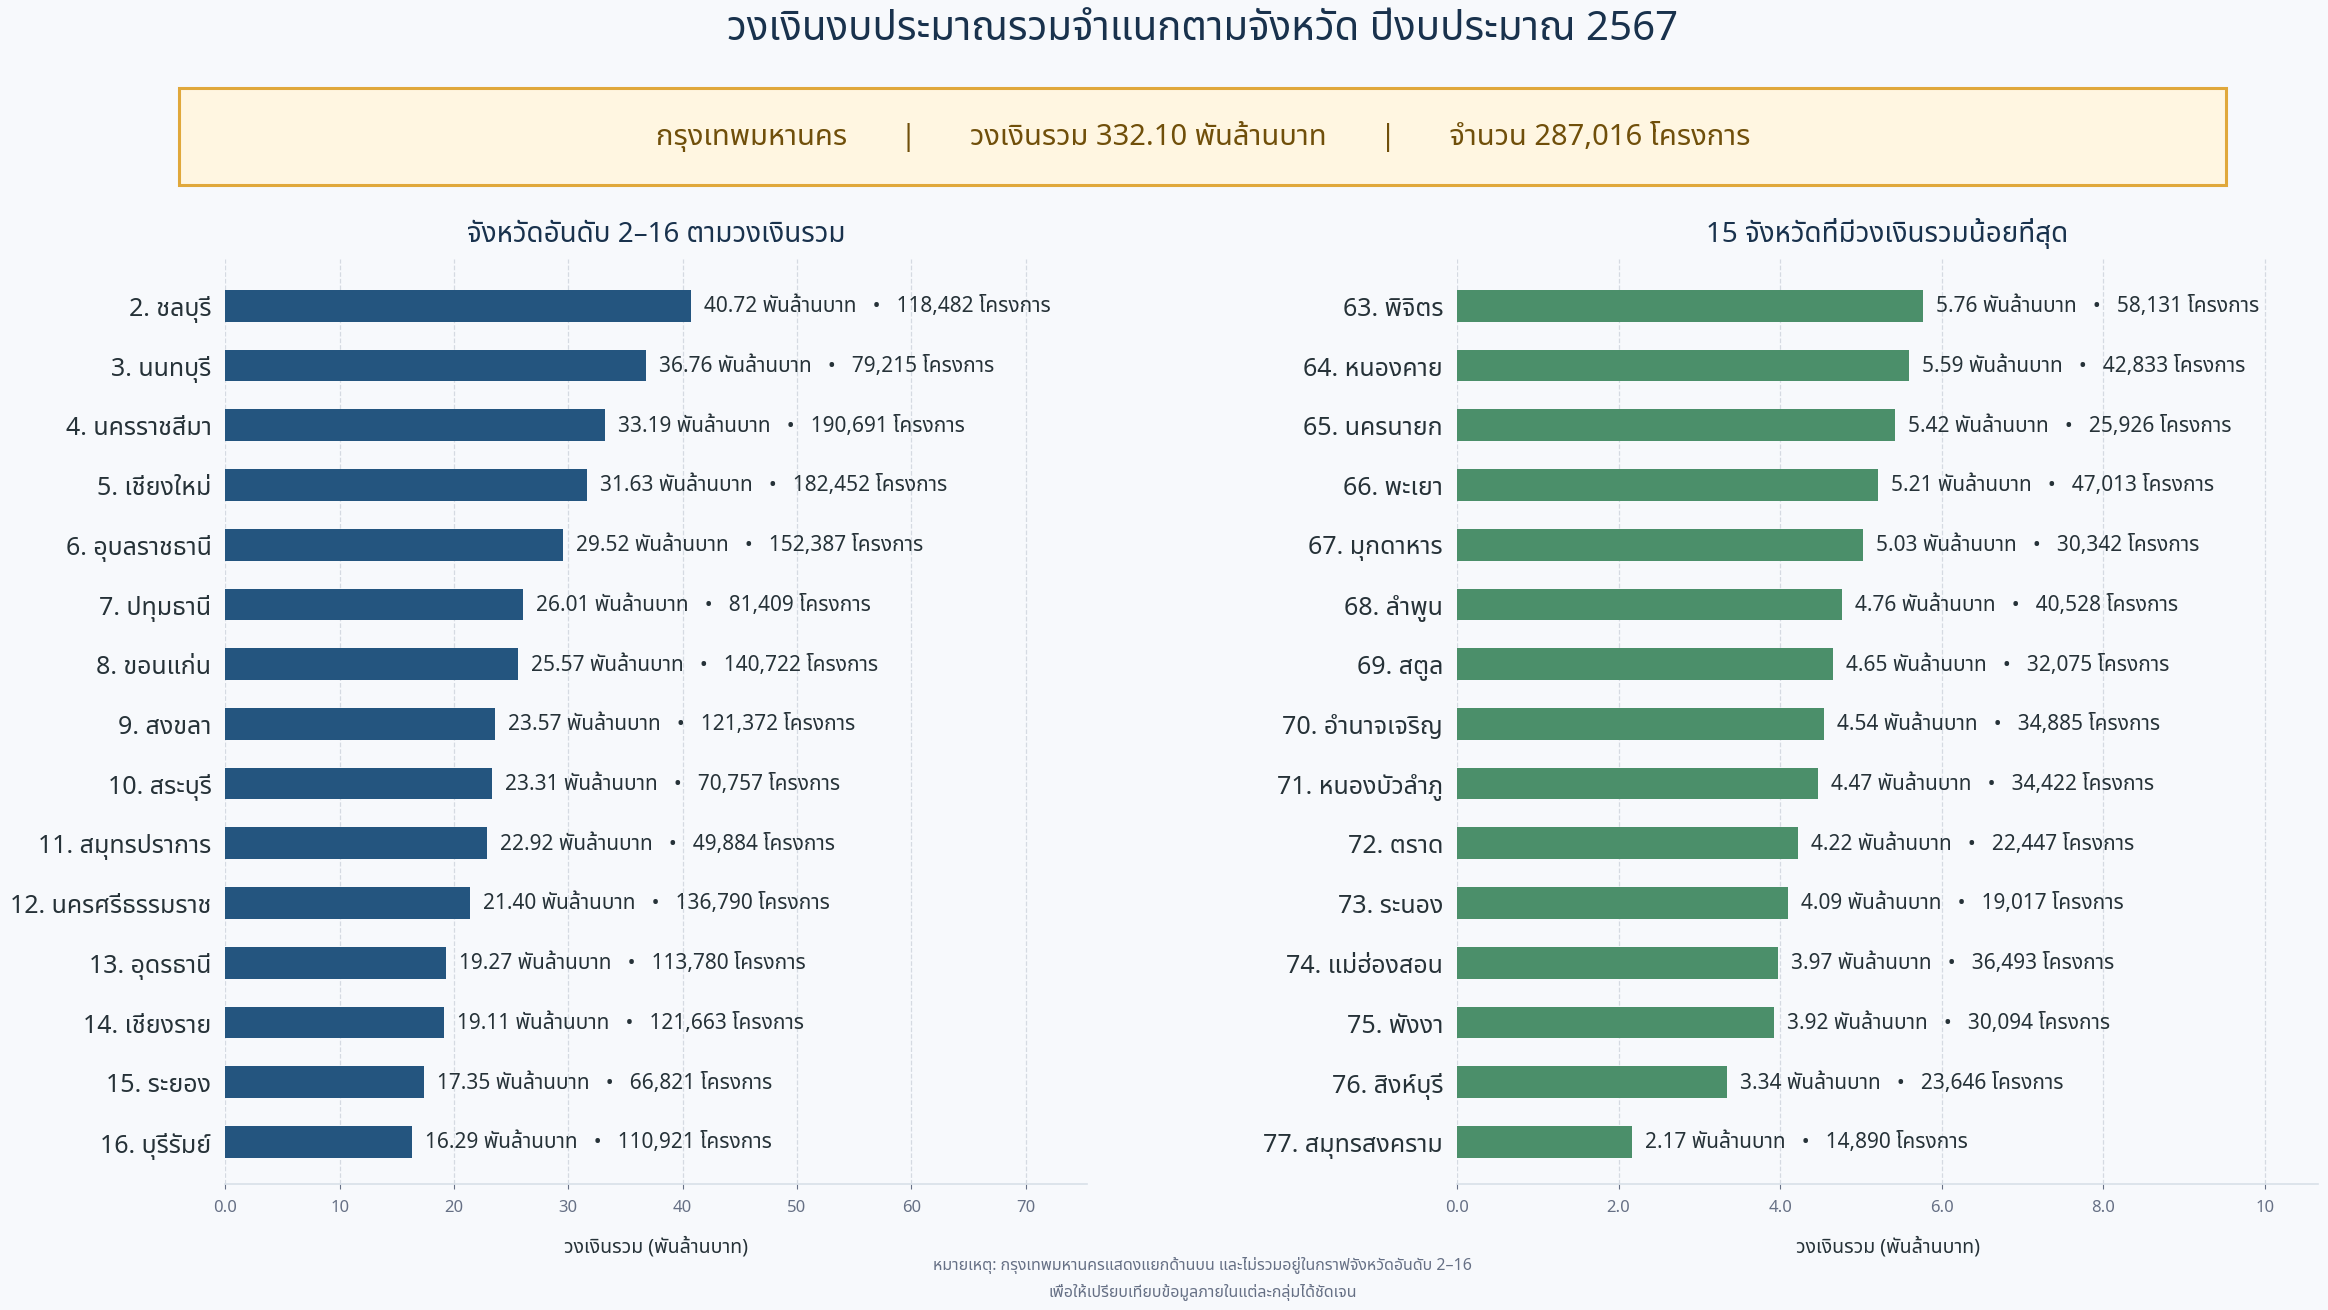

In [11]:
# ============================================================
# GRAPH 3 : จังหวัดอันดับ 2–16 และ 15 จังหวัดอันดับล่าง
# รุ่นเพิ่มขนาดตัวอักษรและระยะห่าง
# ============================================================

svg_file, png_file = figure_files(
    "04_province_budget_top2_16_and_lower15"
)

# ============================================================
# 2) เตรียมข้อมูล
# ใช้ชื่อคอลัมน์ภาษาอังกฤษเพื่อป้องกันปัญหา Unicode
# ============================================================

province_plot_base = province_df.iloc[:, :4].copy()

province_plot_base.columns = [
    "province",
    "project_count",
    "total_budget",
    "average_budget"
]

for column in [
    "project_count",
    "total_budget",
    "average_budget"
]:
    province_plot_base[column] = pd.to_numeric(
        province_plot_base[column],
        errors="coerce"
    ).fillna(0)

province_ranked_df = (
    province_plot_base
    .sort_values(
        "total_budget",
        ascending=False
    )
    .reset_index(drop=True)
)

province_ranked_df["rank"] = (
    np.arange(len(province_ranked_df)) + 1
)

province_ranked_df["budget_billion"] = (
    province_ranked_df["total_budget"]
    / 1_000_000_000
)


# ============================================================
# 3) ข้อมูลกรุงเทพมหานคร
# ============================================================

bangkok_rows = province_ranked_df.loc[
    province_ranked_df["province"].eq("กรุงเทพมหานคร")
]

if bangkok_rows.empty:
    raise ValueError(
        "ไม่พบข้อมูลกรุงเทพมหานครใน province_df"
    )

bangkok_data = bangkok_rows.iloc[0]

bangkok_budget_billion = bangkok_data[
    "budget_billion"
]

bangkok_project_count = bangkok_data[
    "project_count"
]


# ============================================================
# 4) แยกข้อมูลสำหรับแต่ละ Subplot
# ============================================================

# อันดับ 2–16 โดยตัดกรุงเทพมหานครออก
top_2_16_df = (
    province_ranked_df.loc[
        province_ranked_df["rank"].between(2, 16)
    ]
    .sort_values(
        "total_budget",
        ascending=True
    )
    .reset_index(drop=True)
)

# 15 จังหวัดที่มีวงเงินรวมน้อยที่สุด
lower_15_df = (
    province_ranked_df
    .nsmallest(
        15,
        "total_budget"
    )
    .sort_values(
        "total_budget",
        ascending=True
    )
    .reset_index(drop=True)
)


# ============================================================
# 5) กำหนดสี
# ============================================================

figure_background = "#F7F9FC"
title_color = "#19324D"
bangkok_color = "#E0A83B"

top_color = "#24557F"
lower_color = "#4B8F6A"

text_color = "#263238"
secondary_text_color = "#667085"
grid_color = "#D8E0E8"


# ============================================================
# 6) สร้าง Figure ขนาดใหญ่
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(23, 13.5),
    facecolor=figure_background
)

ax_top, ax_lower = axes

for ax in axes:
    ax.set_facecolor(figure_background)


# ============================================================
# 7) ชื่อกราฟหลัก
# ============================================================

fig.suptitle(
    (
        f"วงเงินงบประมาณรวมจำแนกตามจังหวัด "
        f"ปีงบประมาณ {YEAR}"
    ),
    fontsize=29,
    fontweight="bold",
    color=title_color,
    y=0.975
)


# ============================================================
# 8) แถบข้อมูลกรุงเทพมหานคร
# ============================================================

bangkok_banner = Rectangle(
    (0.055, 0.845),
    0.89,
    0.072,
    transform=fig.transFigure,
    facecolor="#FFF6E1",
    edgecolor=bangkok_color,
    linewidth=2.2
)

fig.add_artist(bangkok_banner)

fig.text(
    0.50,
    0.881,
    (
        f"กรุงเทพมหานคร"
        f"       |       "
        f"วงเงินรวม {bangkok_budget_billion:,.2f} พันล้านบาท"
        f"       |       "
        f"จำนวน {bangkok_project_count:,.0f} โครงการ"
    ),
    ha="center",
    va="center",
    fontsize=21,
    fontweight="bold",
    color="#704F0A"
)


# ============================================================
# 9) ฟังก์ชันวาดกราฟ
# ============================================================

def draw_province_subplot(
    ax,
    data,
    title,
    bar_color
):
    # เพิ่มระยะห่างระหว่างแต่ละจังหวัด
    row_spacing = 1.28

    y_positions = (
        np.arange(len(data)) * row_spacing
    )

    budget_values = data["budget_billion"]

    province_labels = [
        f"{int(rank)}. {province}"
        for rank, province in zip(
            data["rank"],
            data["province"]
        )
    ]

    bars = ax.barh(
        y_positions,
        budget_values,
        height=0.68,
        color=bar_color,
        edgecolor="none",
        zorder=3
    )

    ax.set_yticks(y_positions) #############

    ax.set_yticklabels(
        province_labels,
        fontsize=18,
        fontweight="bold"
    )

    local_maximum = budget_values.max()

    # เผื่อพื้นที่ด้านขวาสำหรับข้อความ
    ax.set_xlim(
        0,
        local_maximum * 1.85
    )

    # เพิ่มพื้นที่บนและล่างของกราฟ
    ax.set_ylim(
        -0.9,
        y_positions[-1] + 1.0
    )

    # ตัวเลขท้ายแท่ง
    for bar, (_, row) in zip(
        bars,
        data.iterrows()
    ):
        value = row["budget_billion"]
        count = row["project_count"]

        ax.text(
            value + local_maximum * 0.028,
            bar.get_y() + bar.get_height() / 2,
            (
                f"{value:,.2f} พันล้านบาท"
                f"   •   {count:,.0f} โครงการ"
            ),
            ha="left",
            va="center",
            fontsize=15,              ###############
            fontweight="bold",
            color=text_color
        )

    # ชื่อ Subplot
    ax.set_title(
        title,
        fontsize=20,
        fontweight="bold",
        color=title_color,
        pad=13
    )

    ax.set_xlabel(
        "วงเงินรวม (พันล้านบาท)",
        fontsize=14,
        fontweight="bold",
        color=text_color,
        labelpad=15
    )

    ax.set_ylabel("")

    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda value, position: (
                f"{value:,.1f}"
                if value < 10
                else f"{value:,.0f}"
            )
        )
    )

    # เส้น Grid
    ax.grid(
        axis="x",
        linestyle="--",
        linewidth=0.9,
        alpha=0.35,
        color="#98A2B3",
        zorder=0
    )

    # ซ่อนเส้นกรอบที่ไม่จำเป็น
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(grid_color)
    ax.spines["bottom"].set_linewidth(1.2)

    # เพิ่มระยะห่างระหว่างชื่อจังหวัดกับกราฟ
    ax.tick_params(
        axis="y",
        length=0,
        pad=10,
        colors=text_color
    )

    ax.tick_params(
        axis="x",
        labelsize=12,
        pad=8,
        colors=secondary_text_color
    )


# ============================================================
# 10) วาด Subplot 1
# ============================================================

draw_province_subplot(
    ax=ax_top,
    data=top_2_16_df,
    title="จังหวัดอันดับ 2–16 ตามวงเงินรวม",
    bar_color=top_color
)


# ============================================================
# 11) วาด Subplot 2
# ============================================================

draw_province_subplot(
    ax=ax_lower,
    data=lower_15_df,
    title="15 จังหวัดที่มีวงเงินรวมน้อยที่สุด",
    bar_color=lower_color
)


# ============================================================
# 12) หมายเหตุด้านล่าง
# ============================================================

missing_count = (
    missing_province
    if "missing_province" in globals()
    else 0
)

fig.text(
    0.50,
    0.035,
    (
        "หมายเหตุ: กรุงเทพมหานครแสดงแยกด้านบน "
        "และไม่รวมอยู่ในกราฟจังหวัดอันดับ 2–16\n"
        "เพื่อให้เปรียบเทียบข้อมูลภายในแต่ละกลุ่มได้ชัดเจน"
    ),
    ha="center",
    va="center",
    fontsize=11.5,
    linespacing=1.7,
    color=secondary_text_color
)


# ============================================================
# 13) จัดตำแหน่งองค์ประกอบ
# ============================================================

plt.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.105,
    top=0.79,
    wspace=0.43
)


# ============================================================
# 14) บันทึก SVG
# ============================================================

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


# ============================================================
# 15) บันทึก PNG ความละเอียดสูง
# ============================================================

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


# ============================================================
# 16) แสดงผล
# ============================================================

plt.show()

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

print()

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


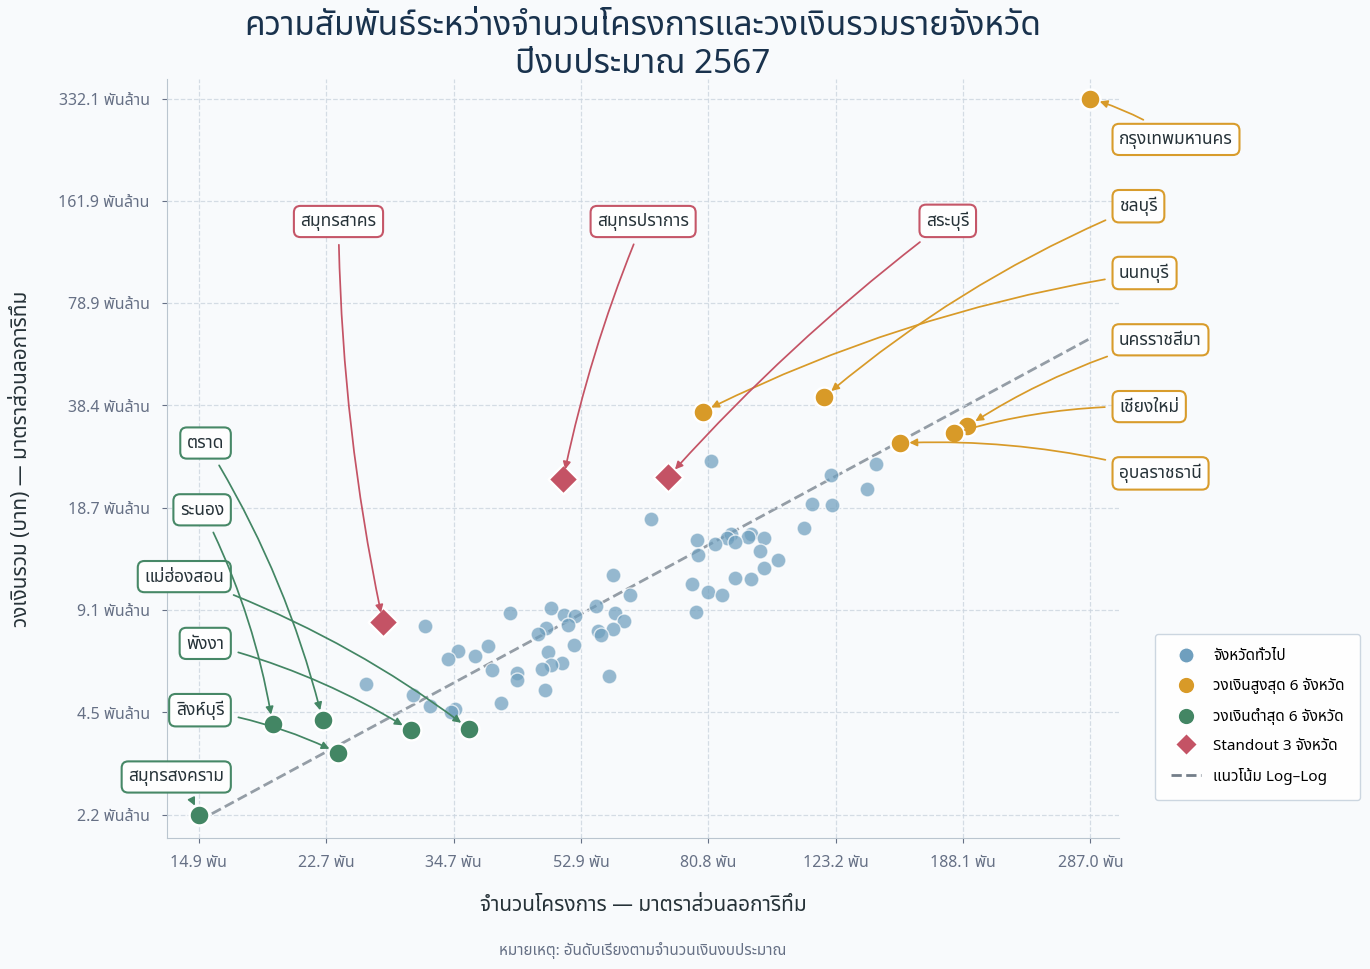

In [12]:
# ============================================================
# GRAPH 4 : ความสัมพันธ์ระหว่างวงเงินรวมกับจำนวนโครงการตามจังหวัด
# จัดกล่องชื่อไว้นอกพื้นที่กราฟ และใช้ Log Scale ทั้งสองแกน
# ============================================================

# ปิด Figure ก่อนหน้าเพื่อลดการใช้หน่วยความจำใน Colab
plt.close("all")

TOP_N = 6
LOWER_N = 6
STANDOUT_N = 3

svg_file, png_file = figure_files("05_province_log_scatter")

# ============================================================
# เตรียมข้อมูล
# ============================================================

scatter_df = province_df.iloc[:, :4].copy()

scatter_df.columns = [
    "province",
    "project_count",
    "total_budget",
    "average_budget"
]

for column in ["project_count", "total_budget", "average_budget"]:
    scatter_df[column] = pd.to_numeric(
        scatter_df[column],
        errors="coerce"
    )

scatter_df = (
    scatter_df
    .dropna(subset=["province", "project_count", "total_budget"])
    .loc[
        lambda data:
        (data["project_count"] > 0)
        & (data["total_budget"] > 0)
    ]
    .reset_index(drop=True)
)


# ============================================================
# คำนวณแนวโน้มและหา Standout
# ============================================================

scatter_df["log_x"] = np.log10(scatter_df["project_count"])
scatter_df["log_y"] = np.log10(scatter_df["total_budget"])

slope, intercept = np.polyfit(
    scatter_df["log_x"],
    scatter_df["log_y"],
    1
)

scatter_df["predicted_log_y"] = (
    intercept + slope * scatter_df["log_x"]
)

scatter_df["absolute_residual"] = abs(
    scatter_df["log_y"]
    - scatter_df["predicted_log_y"]
)

top_df = (
    scatter_df
    .nlargest(TOP_N, "total_budget")
    .reset_index(drop=True)
)

lower_df = (
    scatter_df
    .nsmallest(LOWER_N, "total_budget")
    .reset_index(drop=True)
)

top_names = set(top_df["province"])
lower_names = set(lower_df["province"])

standout_df = (
    scatter_df.loc[
        ~scatter_df["province"].isin(top_names | lower_names)
    ]
    .nlargest(STANDOUT_N, "absolute_residual")
    .reset_index(drop=True)
)

standout_names = set(standout_df["province"])

general_df = scatter_df.loc[
    ~scatter_df["province"].isin(
        top_names | lower_names | standout_names
    )
]


# ============================================================
# สี
# ============================================================

background = "#F8FAFC"
general_color = "#6F9FBE"
top_color = "#D89A28"
lower_color = "#438664"
standout_color = "#C45365"

title_color = "#19324D"
text_color = "#263238"
secondary_color = "#667085"
grid_color = "#CBD5DF"


# ============================================================
# สร้างกราฟ
# ============================================================

fig, ax = plt.subplots(
    figsize=(17, 11.5),
    facecolor=background
)

ax.set_facecolor(background)
ax.set_xscale("log")
ax.set_yscale("log")

# จังหวัดทั่วไป
ax.scatter(
    general_df["project_count"],
    general_df["total_budget"],
    s=115,
    color=general_color,
    alpha=0.72,
    edgecolor="white",
    linewidth=1,
    zorder=2
)

# Top 6
ax.scatter(
    top_df["project_count"],
    top_df["total_budget"],
    s=205,
    color=top_color,
    edgecolor="white",
    linewidth=1.7,
    zorder=5
)

# Lower 6
ax.scatter(
    lower_df["project_count"],
    lower_df["total_budget"],
    s=205,
    color=lower_color,
    edgecolor="white",
    linewidth=1.7,
    zorder=5
)

# Standout
ax.scatter(
    standout_df["project_count"],
    standout_df["total_budget"],
    s=230,
    color=standout_color,
    marker="D",
    edgecolor="white",
    linewidth=1.7,
    zorder=6
)


# ============================================================
# เส้นแนวโน้ม
# ============================================================

min_x = scatter_df["project_count"].min()
max_x = scatter_df["project_count"].max()

min_y = scatter_df["total_budget"].min()
max_y = scatter_df["total_budget"].max()

trend_x = np.geomspace(min_x, max_x, 200)

trend_y = 10 ** (
    intercept + slope * np.log10(trend_x)
)

ax.plot(
    trend_x,
    trend_y,
    color="#737E89",
    linestyle="--",
    linewidth=2,
    alpha=0.75,
    zorder=1
)


# ============================================================
# กำหนดขอบเขตแกน
# ============================================================

ax.set_xlim(min_x * 0.90, max_x * 1.10)
ax.set_ylim(min_y * 0.85, max_y * 1.15)


# ============================================================
# ฟังก์ชันกล่องชื่อด้านซ้ายและขวา
# ============================================================

def add_side_labels(
    ax,
    data,
    side,
    y_start,
    y_end,
    box_color
):
    # เรียงตามตำแหน่งแนวตั้งของจุด
    ordered_data = (
        data
        .sort_values("total_budget", ascending=True)
        .reset_index(drop=True)
    )

    label_y_positions = np.linspace(
        y_start,
        y_end,
        len(ordered_data)
    )

    if side == "right":
        label_x = 1.0   ###############################################
        text_align = "left"
        curve = 0.08
    else:
        label_x = 0.06   ###############################################
        text_align = "right"
        curve = -0.08

    for (_, row), label_y in zip(
        ordered_data.iterrows(),
        label_y_positions
    ):
        ax.annotate(
            row["province"],

            # จุดที่ลูกศรชี้
            xy=(
                row["project_count"],
                row["total_budget"]
            ),
            xycoords="data",

            # กล่องชื่ออยู่นอกพื้นที่ Plot
            xytext=(
                label_x,
                label_y
            ),
            textcoords="axes fraction",

            ha=text_align,
            va="center",
            fontsize=12.5,
            fontweight="bold",
            color=text_color,

            bbox={
                "boxstyle": "round,pad=0.38",
                "facecolor": "white",
                "edgecolor": box_color,
                "linewidth": 1.5,
                "alpha": 0.98
            },

            arrowprops={
                "arrowstyle": "-|>",
                "color": box_color,
                "linewidth": 1.25,
                "mutation_scale": 11,
                "shrinkA": 5,
                "shrinkB": 7,
                "connectionstyle": f"arc3,rad={curve}"
            },

            annotation_clip=False,
            zorder=8
        )


# Top 6 อยู่ด้านขวา
add_side_labels(
    ax=ax,
    data=top_df,
    side="right",
    y_start=0.48,
    y_end=0.92,
    box_color=top_color
)

# Lower 6 อยู่ด้านซ้าย
add_side_labels(
    ax=ax,        ###########################################################
    data=lower_df,
    side="left",
    y_start=0.08,
    y_end=0.52,
    box_color=lower_color
)


# ============================================================
# Standout 3 จังหวัดไว้ด้านบน
# ============================================================

standout_ordered = (
    standout_df
    .sort_values("project_count")
    .reset_index(drop=True)
)

standout_x_positions = np.linspace(
    0.18,
    0.82,
    len(standout_ordered)
)

for (_, row), label_x in zip(
    standout_ordered.iterrows(),
    standout_x_positions
):
    ax.annotate(
        row["province"],
        xy=(
            row["project_count"],
            row["total_budget"]
        ),
        xycoords="data",

        xytext=(
            label_x,
            0.8   ################################################################
        ),
        textcoords="axes fraction",

        ha="center",
        va="bottom",
        fontsize=12.5,
        fontweight="bold",
        color=text_color,

        bbox={
            "boxstyle": "round,pad=0.38",
            "facecolor": "white",
            "edgecolor": standout_color,
            "linewidth": 1.5,
            "alpha": 0.98
        },

        arrowprops={
            "arrowstyle": "-|>",
            "color": standout_color,
            "linewidth": 1.25,
            "mutation_scale": 11,
            "shrinkA": 5,
            "shrinkB": 7,
            "connectionstyle": "arc3,rad=0.05"
        },

        annotation_clip=False,
        zorder=8
    )


# ============================================================
# Tick ตั้งแต่ Min ถึง Max
# ============================================================

x_ticks = np.geomspace(min_x, max_x, 8)
y_ticks = np.geomspace(min_y, max_y, 8)

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.yaxis.set_major_locator(FixedLocator(y_ticks))

ax.xaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_locator(NullLocator())


def format_count(value, position):
    if value >= 1_000_000:
        return f"{value / 1_000_000:,.2f} ล้าน"
    if value >= 1_000:
        return f"{value / 1_000:,.1f} พัน"
    return f"{value:,.0f}"


def format_budget(value, position):
    if value >= 1_000_000_000_000:
        return (
            f"{value / 1_000_000_000_000:,.2f} "
            "ล้านล้าน"
        )
    if value >= 1_000_000_000:
        return (
            f"{value / 1_000_000_000:,.1f} "
            "พันล้าน"
        )
    if value >= 1_000_000:
        return (
            f"{value / 1_000_000:,.1f} ล้าน"
        )
    return f"{value:,.0f}"


ax.xaxis.set_major_formatter(
    FuncFormatter(format_count)
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_budget)
)


# ============================================================
# ชื่อกราฟ
# ============================================================

fig.suptitle(
    (
        "ความสัมพันธ์ระหว่างจำนวนโครงการและวงเงินรวมรายจังหวัด\n"
        f"ปีงบประมาณ {YEAR}"
    ),
    fontsize=24,
    fontweight="bold",
    color=title_color,
    y=0.85 #################################################################
)

ax.set_xlabel(
    "จำนวนโครงการ — มาตราส่วนลอการิทึม",
    fontsize=15,
    fontweight="bold",
    color=text_color,
    labelpad=17
)

ax.set_ylabel(
    "วงเงินรวม (บาท) — มาตราส่วนลอการิทึม",
    fontsize=15,
    fontweight="bold",
    color=text_color,
    labelpad=19
)


# ============================================================
# Grid
# ============================================================

ax.grid(
    which="major",
    linestyle="--",
    linewidth=0.9,
    color=grid_color,
    alpha=0.8,
    zorder=0
)

ax.tick_params(
    axis="both",
    labelsize=11.5,
    pad=9,
    colors=secondary_color
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#BAC5CF")
ax.spines["bottom"].set_color("#BAC5CF")


# ============================================================
# Legend — วางไว้นอกกราฟด้านขวาล่าง
# ============================================================

legend_items = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=general_color,
        markeredgecolor="white",
        markersize=11,
        label="จังหวัดทั่วไป"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=top_color,
        markeredgecolor="white",
        markersize=12,
        label="วงเงินสูงสุด 6 จังหวัด"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=lower_color,
        markeredgecolor="white",
        markersize=12,
        label="วงเงินต่ำสุด 6 จังหวัด"
    ),
    Line2D(
        [0], [0],
        marker="D",
        linestyle="none",
        markerfacecolor=standout_color,
        markeredgecolor="white",
        markersize=11,
        label="Standout 3 จังหวัด"
    ),
    Line2D(
        [0], [0],
        color="#737E89",
        linestyle="--",
        linewidth=2,
        label="แนวโน้ม Log–Log"
    )
]

ax.legend(
    handles=legend_items,
    loc="lower left",
    bbox_to_anchor=(1.03, 0.04),
    fontsize=11,
    facecolor="white",
    edgecolor=grid_color,
    framealpha=0.97,
    borderpad=1,
    labelspacing=0.9
)


# ============================================================
# หมายเหตุ
# ============================================================

fig.text(
    0.5,
    0.028,
    (
        "หมายเหตุ: อันดับเรียงตามจำนวนเงินงบประมาณ"
    ),
    ha="center",
    fontsize=11,
    color=secondary_color
)


# ============================================================
# Layout — เผื่อพื้นที่สำหรับกล่องชื่อทั้งสองด้าน
# ============================================================

plt.subplots_adjust(
    left=0.22,
    right=0.78,
    top=0.79,
    bottom=0.13
)


# ============================================================
# บันทึก SVG และ PNG
# ============================================================

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

plt.show()
plt.close(fig)

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


## Analysis 4 — สรุปตามหน่วยงาน


In [13]:
# ============================================================
# ANALYSIS 4 : สรุปข้อมูลการจัดซื้อจัดจ้างตามหน่วยงาน
# ============================================================

# จัดกลุ่มข้อมูลตาม "ชื่อหน่วยงาน"
# observed=True ป้องกันการสร้างกลุ่ม Category ที่ไม่มีข้อมูลจริง
# size() = จำนวนโครงการ เพราะข้อมูลของเราเป็น 1 Project = 1 Row
agency_df = (
    project_overview_df
    .groupby(
        "ชื่อหน่วยงาน",
        observed=True,
        dropna=False,
        sort=False
    )
    .agg(
        project_count=("รหัสโครงการ", "size"),
        total_budget=("วงเงินงบประมาณ (บาท)", "sum")
    )
    .reset_index()
)

# แปลงชื่อหน่วยงานหลัง GroupBy ซึ่งมีจำนวนแถวน้อยกว่าข้อมูลต้นฉบับมาก
# วิธีนี้ประหยัด RAM กว่าการแปลงข้อความหลายล้านแถวก่อน GroupBy
agency_df["ชื่อหน่วยงาน"] = (
    agency_df["ชื่อหน่วยงาน"]
    .astype("string")
    .str.strip()
    .fillna("ไม่ระบุชื่อหน่วยงาน")
)

# รวมชื่อหน่วยงานอีกครั้งหลังตัดช่องว่าง เพื่อป้องกันชื่อเดียวกันแยกเป็นหลายแถว
agency_df = (
    agency_df
    .groupby(
        "ชื่อหน่วยงาน",
        as_index=False,
        dropna=False,
        sort=False
    )
    .agg({
        "project_count": "sum",
        "total_budget": "sum"
    })
)

# คำนวณวงเงินเฉลี่ยจากยอดรวมและจำนวนโครงการหลังรวมชื่อที่สะกดเหมือนกันแล้ว
agency_df["average_budget"] = np.divide(
    agency_df["total_budget"],
    agency_df["project_count"],
    out=np.zeros(len(agency_df), dtype="float64"),
    where=agency_df["project_count"].to_numpy() > 0
)


# ============================================================
# หาสังกัดหลักของแต่ละหน่วยงานจาก project_overview_df
# ============================================================

# นับจำนวนครั้งของคู่ "ชื่อหน่วยงาน + สังกัด" โดยไม่สร้างสำเนาข้อมูลหลัก
# หากหน่วยงานเดียวมีหลายสังกัด จะเลือกสังกัดที่พบในโครงการมากที่สุด
agency_affiliation_counts = (
    project_overview_df
    .groupby(
        ["ชื่อหน่วยงาน", "สังกัด"],
        observed=True,
        dropna=True,
        sort=False
    )
    .size()
    .reset_index(name="จำนวนรายการสังกัด")
)

# ทำความสะอาดข้อความบนตารางสรุปขนาดเล็กแทนการแก้ข้อมูลหลายล้านแถว
for text_column in ["ชื่อหน่วยงาน", "สังกัด"]:
    agency_affiliation_counts[text_column] = (
        agency_affiliation_counts[text_column]
        .astype("string")
        .str.strip()
    )

valid_affiliation_mask = (
    agency_affiliation_counts["ชื่อหน่วยงาน"].notna()
    & agency_affiliation_counts["ชื่อหน่วยงาน"].ne("")
    & agency_affiliation_counts["สังกัด"].notna()
    & agency_affiliation_counts["สังกัด"].ne("")
)

agency_affiliation_counts = (
    agency_affiliation_counts
    .loc[valid_affiliation_mask]
    .groupby(
        ["ชื่อหน่วยงาน", "สังกัด"],
        as_index=False,
        dropna=False,
        sort=False
    )["จำนวนรายการสังกัด"]
    .sum()
)

# เรียงจำนวนที่พบจากมากไปน้อย แล้วเก็บสังกัดอันดับแรกของแต่ละหน่วยงาน
# กรณีจำนวนเท่ากัน ใช้ชื่อสังกัดเรียงตามตัวอักษรเพื่อให้ผลลัพธ์คงที่ทุกครั้ง
primary_affiliation_df = (
    agency_affiliation_counts
    .sort_values(
        ["ชื่อหน่วยงาน", "จำนวนรายการสังกัด", "สังกัด"],
        ascending=[True, False, True],
        kind="stable"
    )
    .drop_duplicates("ชื่อหน่วยงาน", keep="first")
    [["ชื่อหน่วยงาน", "สังกัด"]]
)

# ตรวจความสัมพันธ์ก่อน Merge เพื่อป้องกันจำนวนแถวเพิ่มแบบ many-to-many
if primary_affiliation_df["ชื่อหน่วยงาน"].duplicated().any():
    raise ValueError("พบชื่อหน่วยงานซ้ำในตารางสังกัดหลัก")

agency_df = agency_df.merge(
    primary_affiliation_df,
    on="ชื่อหน่วยงาน",
    how="left",
    validate="one_to_one"
)

missing_primary_affiliation = int(agency_df["สังกัด"].isna().sum())

# แปลงเป็น String ก่อน fillna เพื่อหลีกเลี่ยง Error ของ Category
agency_df["สังกัด"] = (
    agency_df["สังกัด"]
    .astype("string")
    .fillna("ไม่พบข้อมูลสังกัด")
)

# เปลี่ยนชื่อคอลัมน์และเรียงจากวงเงินรวมมากที่สุดไปน้อยที่สุด
agency_df = (
    agency_df
    .rename(columns={
        "project_count": "จำนวนโครงการ",
        "total_budget": "วงเงินรวม (บาท)",
        "average_budget": "วงเงินเฉลี่ย (บาท)"
    })
    .sort_values("วงเงินรวม (บาท)", ascending=False)
    .reset_index(drop=True)
)

# จัดลำดับคอลัมน์ให้สังกัดอยู่ถัดจากชื่อหน่วยงาน
agency_df = agency_df[[
    "ชื่อหน่วยงาน",
    "สังกัด",
    "จำนวนโครงการ",
    "วงเงินรวม (บาท)",
    "วงเงินเฉลี่ย (บาท)"
]]

print(f"จำนวนหน่วยงานที่พบในข้อมูล : {agency_df['ชื่อหน่วยงาน'].nunique():,} หน่วยงาน")
print(f"หน่วยงานที่ไม่พบข้อมูลสังกัด : {missing_primary_affiliation:,} หน่วยงาน")

# Cleanup เฉพาะตารางสรุปชั่วคราว โดยเก็บ project_overview_df และ agency_df ไว้
del agency_affiliation_counts
del primary_affiliation_df
del valid_affiliation_mask
gc.collect()

# แสดงตาราง
display(agency_df)


จำนวนหน่วยงานที่พบในข้อมูล : 42,137 หน่วยงาน
หน่วยงานที่ไม่พบข้อมูลสังกัด : 409 หน่วยงาน


,ชื่อหน่วยงาน,สังกัด,จำนวนโครงการ,วงเงินรวม (บาท),วงเงินเฉลี่ย (บาท)
0,กรมทางหลวง,ส่วนราชการทั่วไป,56870,1.092553e+11,1.921142e+06
1,กรมชลประทาน,ส่วนราชการทั่วไป,108312,5.812020e+10,5.365998e+05
2,กรมทางหลวงชนบท,ส่วนราชการทั่วไป,23164,5.538241e+10,2.390883e+06
3,การไฟฟ้าส่วนภูมิภาค,รัฐวิสาหกิจนอกตลาดหลักทรัพย์,33011,4.824993e+10,1.461632e+06
4,กรมโยธาธิการและผังเมือง,ส่วนราชการทั่วไป,3882,3.522829e+10,9.074778e+06
...,...,...,...,...,...
42132,โรงเรียนบ้านหนองแสงคำ,ส่วนราชการประเภทสถานศึกษา,1,1.300000e+03,1.300000e+03
42133,โรงเรียนบ้านหนองบัวแพ,ส่วนราชการประเภทสถานศึกษา,1,1.262600e+03,1.262600e+03
42134,ศูนย์ กศน.นาคู,ส่วนราชการประเภทสถานศึกษา,1,1.000000e+03,1.000000e+03
42135,โรงเรียนบ้านประทุนทอง,ส่วนราชการประเภทสถานศึกษา,1,1.000000e+03,1.000000e+03


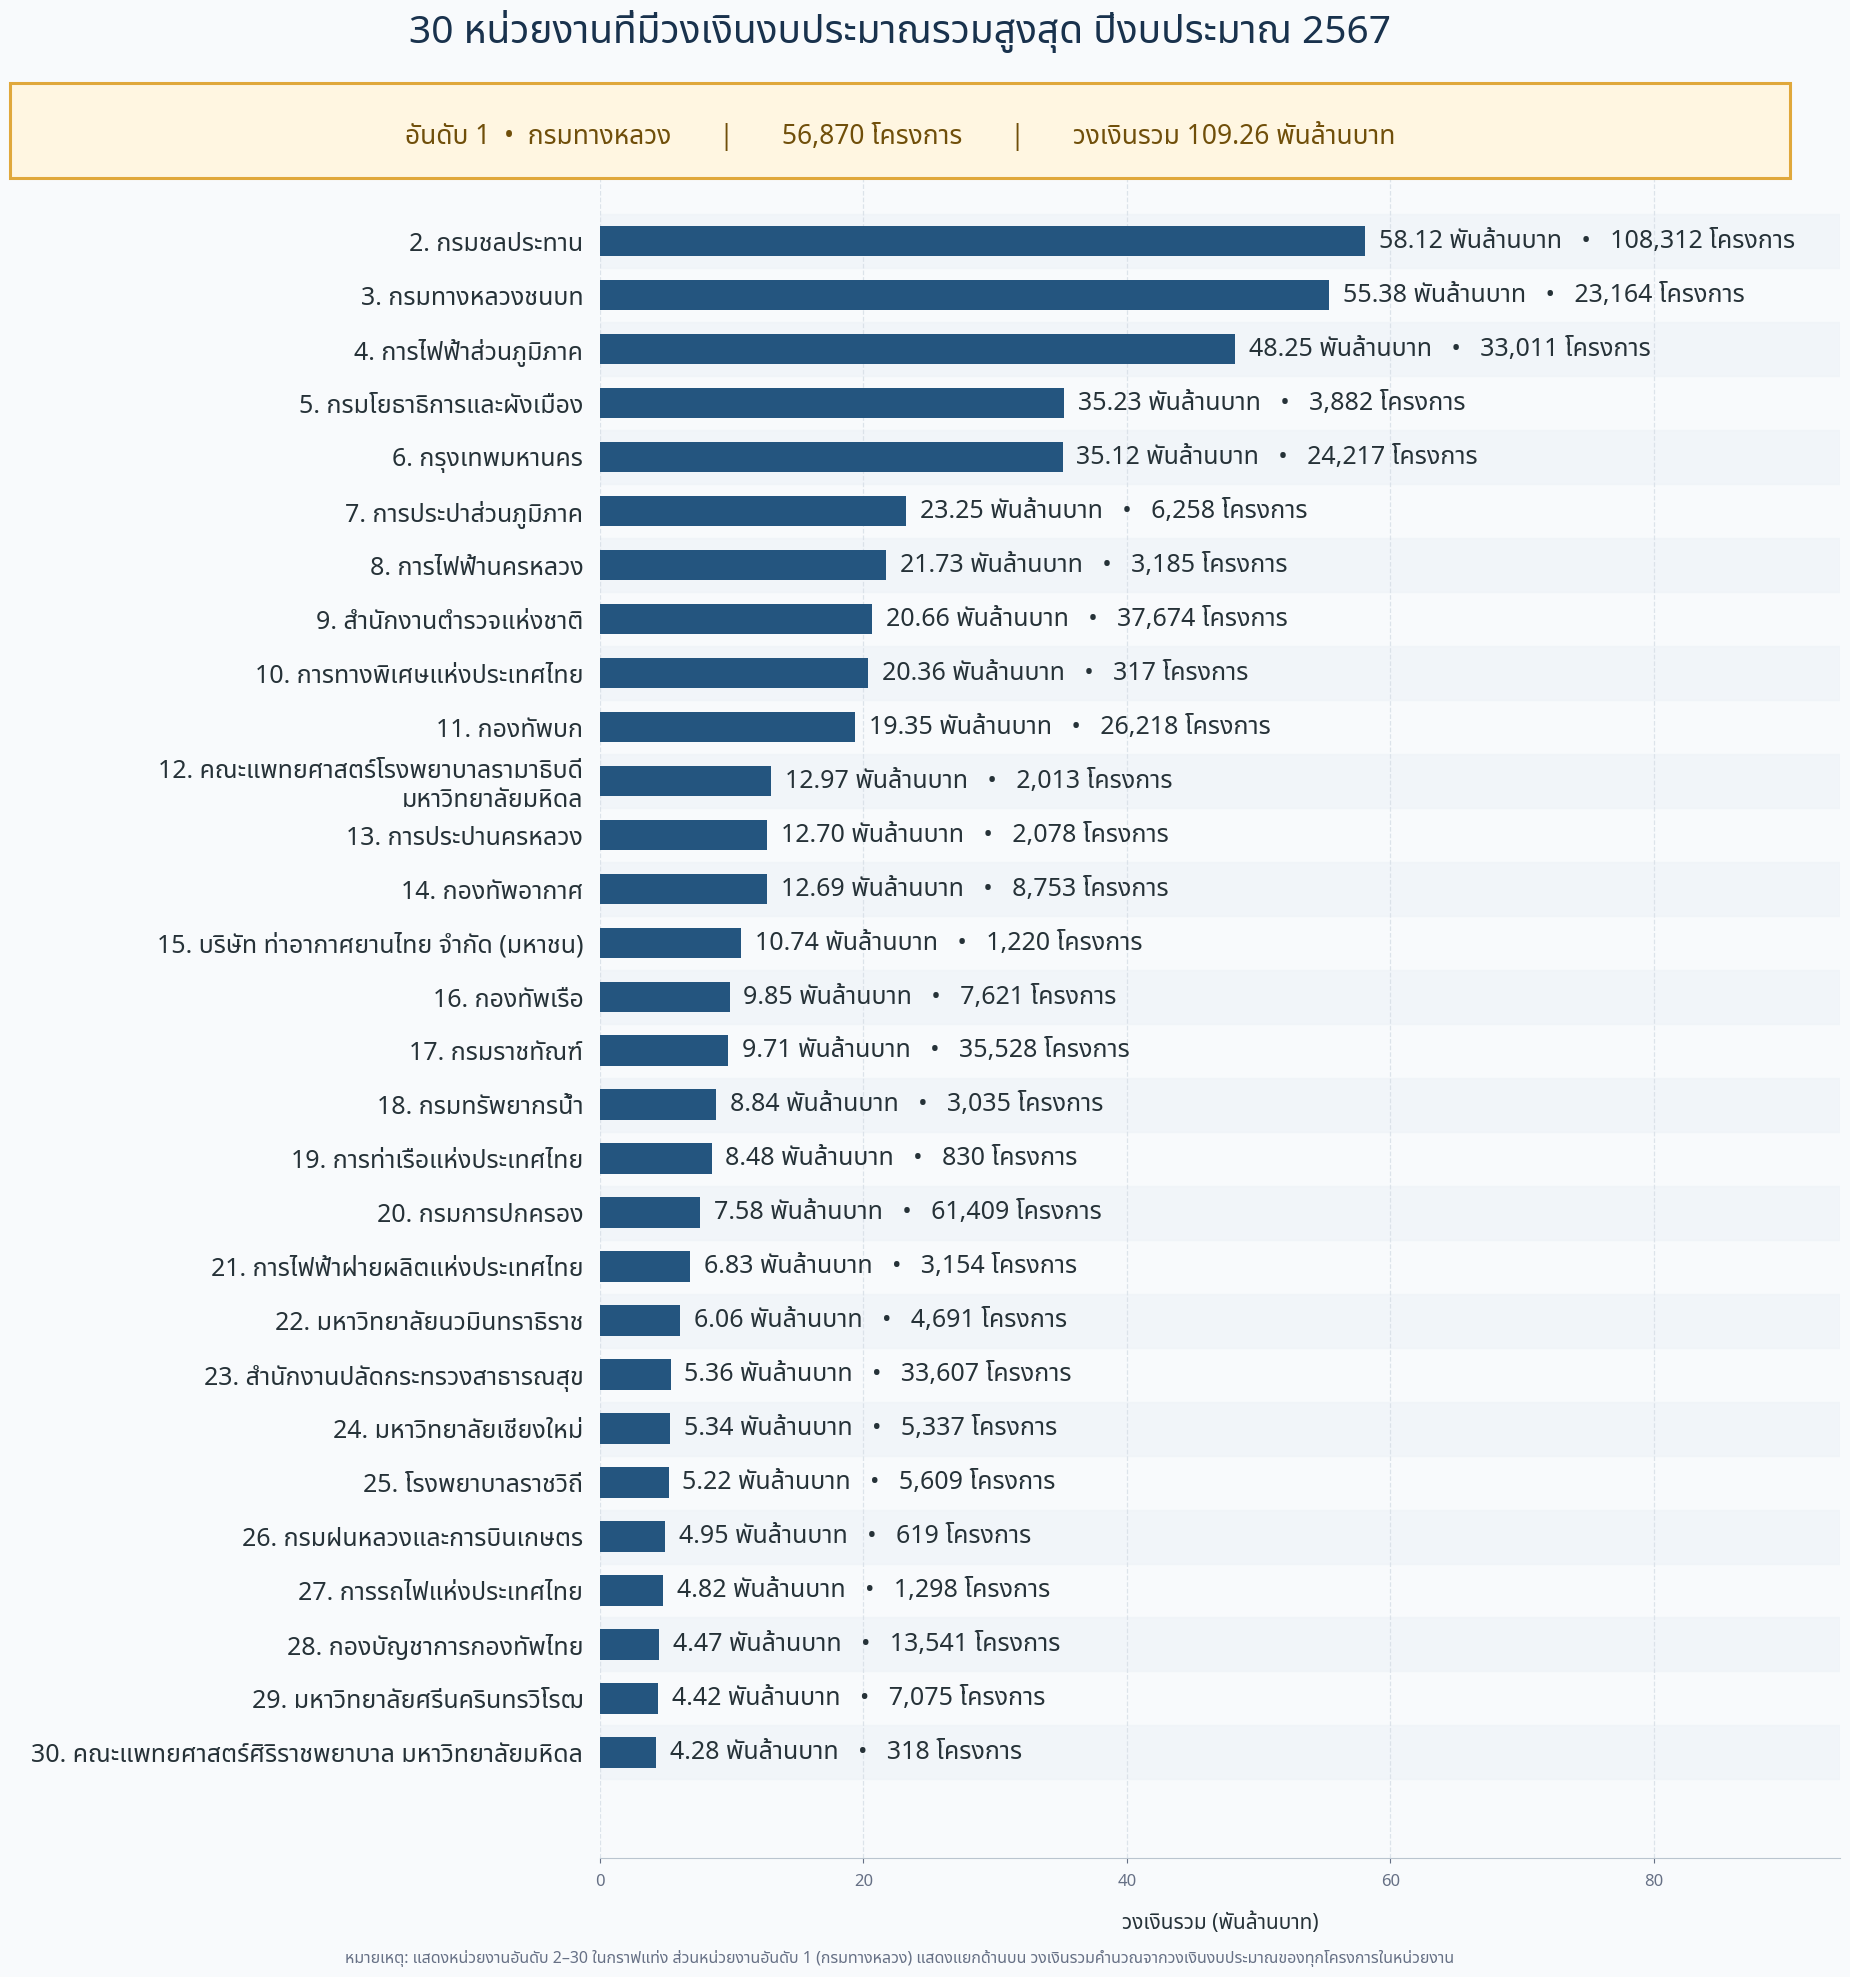

In [14]:
# ============================================================
# GRAPH 5 : 30 หน่วยงานที่มีวงเงินรวมสูงสุด
# แยกอันดับ 1 ไว้ด้านบน และ Plot อันดับ 2–30
# ============================================================

# คืนหน่วยความจำจาก Figure ก่อนหน้า
plt.close("all")

TOP_N = 30
svg_file, png_file = figure_files("06_top_30_agencies_budget")

# ============================================================
# 3) เตรียมข้อมูล
# ใช้ชื่อคอลัมน์ภาษาอังกฤษเพื่อป้องกันปัญหา Unicode
# ============================================================

# ระบุชื่อคอลัมน์โดยตรง ไม่เลือกด้วยตำแหน่ง iloc
# เพราะ agency_df มีคอลัมน์ "สังกัด" เพิ่มเข้ามา และลำดับคอลัมน์อาจเปลี่ยนได้
required_agency_plot_columns = [
    "ชื่อหน่วยงาน",
    "จำนวนโครงการ",
    "วงเงินรวม (บาท)",
    "วงเงินเฉลี่ย (บาท)"
]

missing_agency_plot_columns = [
    column
    for column in required_agency_plot_columns
    if column not in agency_df.columns
]

if missing_agency_plot_columns:
    raise KeyError(
        "agency_df ขาดคอลัมน์ที่กราฟ 5 ต้องใช้: "
        + ", ".join(missing_agency_plot_columns)
        + " กรุณารัน Analysis 4 เวอร์ชันล่าสุดก่อน"
    )

agency_plot_df = (
    agency_df[required_agency_plot_columns]
    .copy()
    .rename(columns={
        "ชื่อหน่วยงาน": "agency",
        "จำนวนโครงการ": "project_count",
        "วงเงินรวม (บาท)": "total_budget",
        "วงเงินเฉลี่ย (บาท)": "average_budget"
    })
)

for column in [
    "project_count",
    "total_budget",
    "average_budget"
]:
    agency_plot_df[column] = pd.to_numeric(
        agency_plot_df[column],
        errors="coerce"
    )

agency_plot_df = (
    agency_plot_df
    .dropna(
        subset=[
            "agency",
            "project_count",
            "total_budget"
        ]
    )
    .sort_values(
        "total_budget",
        ascending=False
    )
    .reset_index(drop=True)
)

# ตรวจสอบหลังแปลงข้อมูล เพื่อไม่ให้ Error เป็น IndexError ที่ตีความยาก
if agency_plot_df.empty:
    raise ValueError(
        "กราฟ 5 ไม่มีข้อมูลหน่วยงานหลังเตรียมข้อมูล "
        "กรุณาตรวจชนิดข้อมูลของจำนวนโครงการและวงเงินรวม"
    )

if len(agency_plot_df) < 2:
    raise ValueError(
        "กราฟ 5 ต้องมีข้อมูลอย่างน้อย 2 หน่วยงาน "
        "เพื่อแยกอันดับ 1 และสร้างกราฟแท่ง"
    )

# หากปีใดมีหน่วยงานน้อยกว่า 30 ให้แสดงเท่าที่มีจริง
DISPLAY_N = min(TOP_N, len(agency_plot_df))

# เพิ่มอันดับ
agency_plot_df["rank"] = (
    np.arange(len(agency_plot_df)) + 1
)

# แปลงหน่วยเป็นพันล้านบาท
agency_plot_df["budget_billion"] = (
    agency_plot_df["total_budget"]
    / 1_000_000_000
)


# ============================================================
# 4) แยกอันดับ 1 และอันดับ 2–30
# ============================================================

number_one_agency = agency_plot_df.iloc[0]

chart_df = (
    agency_plot_df
    .iloc[1:DISPLAY_N]
    .sort_values(
        "total_budget",
        ascending=True
    )
    .reset_index(drop=True)
)

number_one_name = number_one_agency["agency"]
number_one_count = number_one_agency["project_count"]
number_one_budget = number_one_agency["budget_billion"]


# ============================================================
# 5) ตัดชื่อหน่วยงานที่ยาวให้ขึ้นบรรทัดใหม่
# ============================================================

def wrap_agency_name(name, width=44):
    return "\n".join(
        textwrap.wrap(
            str(name),
            width=width,
            break_long_words=True,
            break_on_hyphens=False
        )
    )


agency_labels = [
    f"{int(rank)}. {wrap_agency_name(agency)}"
    for rank, agency in zip(
        chart_df["rank"],
        chart_df["agency"]
    )
]


# ============================================================
# 6) กำหนดสี
# ============================================================

background_color = "#F8FAFC"
title_color = "#19324D"
bar_color = "#24557F"
highlight_color = "#E0A83B"

text_color = "#263238"
secondary_text_color = "#667085"
grid_color = "#D6DEE6"


# ============================================================
# 7) สร้าง Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(20, 21),
    facecolor=background_color
)

ax.set_facecolor(background_color)


# ============================================================
# 8) ชื่อกราฟหลัก
# ============================================================

fig.suptitle(
    (
        f"{DISPLAY_N} หน่วยงานที่มีวงเงินงบประมาณรวมสูงสุด "
        f"ปีงบประมาณ {YEAR}"
    ),
    fontsize=28,
    fontweight="bold",
    color=title_color,
    y=0.95 ###########################################################################
)


# ============================================================
# 9) แถบสรุปหน่วยงานอันดับ 1
# ============================================================

summary_box = Rectangle(
    (0.055, 0.87),
    0.89,                                     #########################################
    0.045,
    transform=fig.transFigure,
    facecolor="#FFF6E1",
    edgecolor=highlight_color,
    linewidth=2.2
)

fig.add_artist(summary_box)

fig.text(
    0.5,
    0.89,                                             ##########
    (
        f"อันดับ 1  •  {number_one_name}"
        f"       |       "
        f"{number_one_count:,.0f} โครงการ"
        f"       |       "
        f"วงเงินรวม {number_one_budget:,.2f} พันล้านบาท"
    ),
    ha="center",
    va="center",
    fontsize=19,
    fontweight="bold",
    color="#704F0A"
)


# ============================================================
# 10) สร้างกราฟแท่งอันดับ 2–30
# ============================================================

row_spacing = 1.28
y_positions = np.arange(len(chart_df)) * row_spacing

bars = ax.barh(
    y_positions,
    chart_df["budget_billion"],
    height=0.72,
    color=bar_color,
    edgecolor="none",
    zorder=3
)


# ============================================================
# 11) เพิ่มพื้นหลังบาง ๆ เพื่อช่วยแยกแต่ละแถว
# ============================================================

for position, y_value in enumerate(y_positions):
    if position % 2 == 0:
        ax.axhspan(
            y_value - row_spacing / 2,
            y_value + row_spacing / 2,
            color="#EDF2F7",
            alpha=0.55,
            zorder=0
        )


# ============================================================
# 12) แสดงวงเงินและจำนวนโครงการท้ายแท่ง
# ============================================================

maximum_budget = chart_df["budget_billion"].max()

for bar, (_, row) in zip(
    bars,
    chart_df.iterrows()
):
    budget_value = row["budget_billion"]
    project_count = row["project_count"]

    ax.text(
        budget_value + maximum_budget * 0.018,
        bar.get_y() + bar.get_height() / 2,
        (
            f"{budget_value:,.2f} พันล้านบาท"
            f"   •   {project_count:,.0f} โครงการ"
        ),
        ha="left",
        va="center",
        fontsize=18,
        fontweight="bold",
        color=text_color,
        zorder=5
    )


# ============================================================
# 13) ชื่อหน่วยงานบนแกน Y
# ============================================================

ax.set_yticks(y_positions)

ax.set_yticklabels(
    agency_labels,
    fontsize=18,             ##############################
    fontweight="bold",
    color=text_color
)

ax.tick_params(
    axis="y",
    length=0,
    pad=12
)


# ============================================================
# 14) ชื่อ Subplot
# ============================================================


# ============================================================
# 15) ตั้งค่าแกน X
# ============================================================

ax.set_xlabel(
    "วงเงินรวม (พันล้านบาท)",
    fontsize=15,
    fontweight="bold",
    color=text_color,
    labelpad=16
)

ax.set_ylabel("")

# เผื่อพื้นที่ด้านขวาสำหรับข้อความท้ายแท่ง
ax.set_xlim(
    0,
    maximum_budget * 1.62
)

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)

ax.tick_params(
    axis="x",
    labelsize=12,
    pad=8,
    colors=secondary_text_color
)


# ============================================================
# 16) Grid และเส้นขอบ
# ============================================================

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.9,
    color=grid_color,
    alpha=0.8,
    zorder=1
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#BAC5CF")


# ============================================================
# 17) หมายเหตุ
# ============================================================

fig.text(
    0.5,
    0.022,
    (
        f"หมายเหตุ: แสดงหน่วยงานอันดับ 2–{DISPLAY_N} ในกราฟแท่ง "
        f"ส่วนหน่วยงานอันดับ 1 ({number_one_name}) แสดงแยกด้านบน "
        "วงเงินรวมคำนวณจากวงเงินงบประมาณของทุกโครงการในหน่วยงาน"
    ),
    ha="center",
    va="center",
    fontsize=11.5,
    color=secondary_text_color
)


# ============================================================
# 18) ปรับ Layout
# ============================================================

plt.subplots_adjust(
    left=0.35,
    right=0.97,
    top=0.89,
    bottom=0.07
)


# ============================================================
# 19) GitHub Version: ไม่บันทึก SVG
# ============================================================

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


# ============================================================
# 20) GitHub Version: ไม่บันทึก PNG
# ============================================================

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


# ============================================================
# 21) แสดงผลและคืนหน่วยความจำ
# ============================================================

plt.show()
plt.close(fig)

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

print()

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


## Analysis 6 — การกระจายของขนาดโครงการ


In [15]:
# ============================================================
# ANALYSIS 6 : การกระจายของขนาดโครงการ
# ============================================================

# กำหนด Feature ที่ใช้แบ่งขนาดโครงการ
budget_col = "วงเงินงบประมาณ (บาท)"

# กำหนดจุดแบ่งช่วงของวงเงิน
# เช่น ช่วงที่ 2 ในทางคำนวณหมายถึง มากกว่า 100,000 ถึง 500,000 บาท
size_bins = [
    -np.inf,
    100_000,
    500_000,
    1_000_000,
    10_000_000,
    100_000_000,
    np.inf
]

# กำหนดชื่อของแต่ละช่วงตามที่ต้องการแสดงในตาราง
size_labels = [
    "ไม่เกิน 100,000 บาท",
    "100,001–500,000 บาท",
    "500,001–1 ล้านบาท",
    "มากกว่า 1–10 ล้านบาท",
    "มากกว่า 10–100 ล้านบาท",
    "มากกว่า 100 ล้านบาท"
]

# สร้างสำเนาเฉพาะข้อมูลที่จำเป็น เพื่อไม่แก้ project_overview_df ต้นฉบับ
project_size_temp = project_overview_df[
    ["รหัสโครงการ", budget_col]
].copy()

# แบ่งแต่ละโครงการเข้าสู่ช่วงขนาดตามวงเงินงบประมาณ
# right=True หมายถึงค่าขอบบนรวมอยู่ในช่วงนั้น เช่น 100,000 อยู่ในช่วงแรก
project_size_temp["project_size"] = pd.cut(
    project_size_temp[budget_col],
    bins=size_bins,
    labels=size_labels,
    right=True,
    include_lowest=True
)

# สรุปจำนวนโครงการและวงเงินรวมของแต่ละช่วง
project_size_df = project_size_temp.groupby(
    "project_size",
    observed=False
).agg(
    project_count=("รหัสโครงการ", "size"),
    total_budget=(budget_col, "sum")
).reset_index()

# เปลี่ยนชื่อคอลัมน์เป็นภาษาไทยหลังคำนวณเสร็จ
project_size_df = project_size_df.rename(columns={
    "project_size": "ช่วงขนาดโครงการ",
    "project_count": "จำนวนโครงการ",
    "total_budget": "วงเงินรวม (บาท)"
})

# แสดงตาราง
display(
    project_size_df.style.format({
        "จำนวนโครงการ": "{:,.0f}",
        "วงเงินรวม (บาท)": "{:,.2f}"
    })
)

# คืน RAM ของตารางระดับโครงการชั่วคราวหลังสรุปผลเสร็จแล้ว
del project_size_temp
gc.collect()


,ช่วงขนาดโครงการ,จำนวนโครงการ,วงเงินรวม (บาท)
0,"ไม่เกิน 100,000 บาท","4,481,812","109,139,864,579.46"
1,"100,001–500,000 บาท","812,297","221,539,908,439.52"
2,"500,001–1 ล้านบาท","37,375","28,069,715,299.22"
3,มากกว่า 1–10 ล้านบาท,"83,091","281,193,054,023.51"
4,มากกว่า 10–100 ล้านบาท,"12,957","331,313,366,997.30"
5,มากกว่า 100 ล้านบาท,757,"271,934,079,945.87"


4915

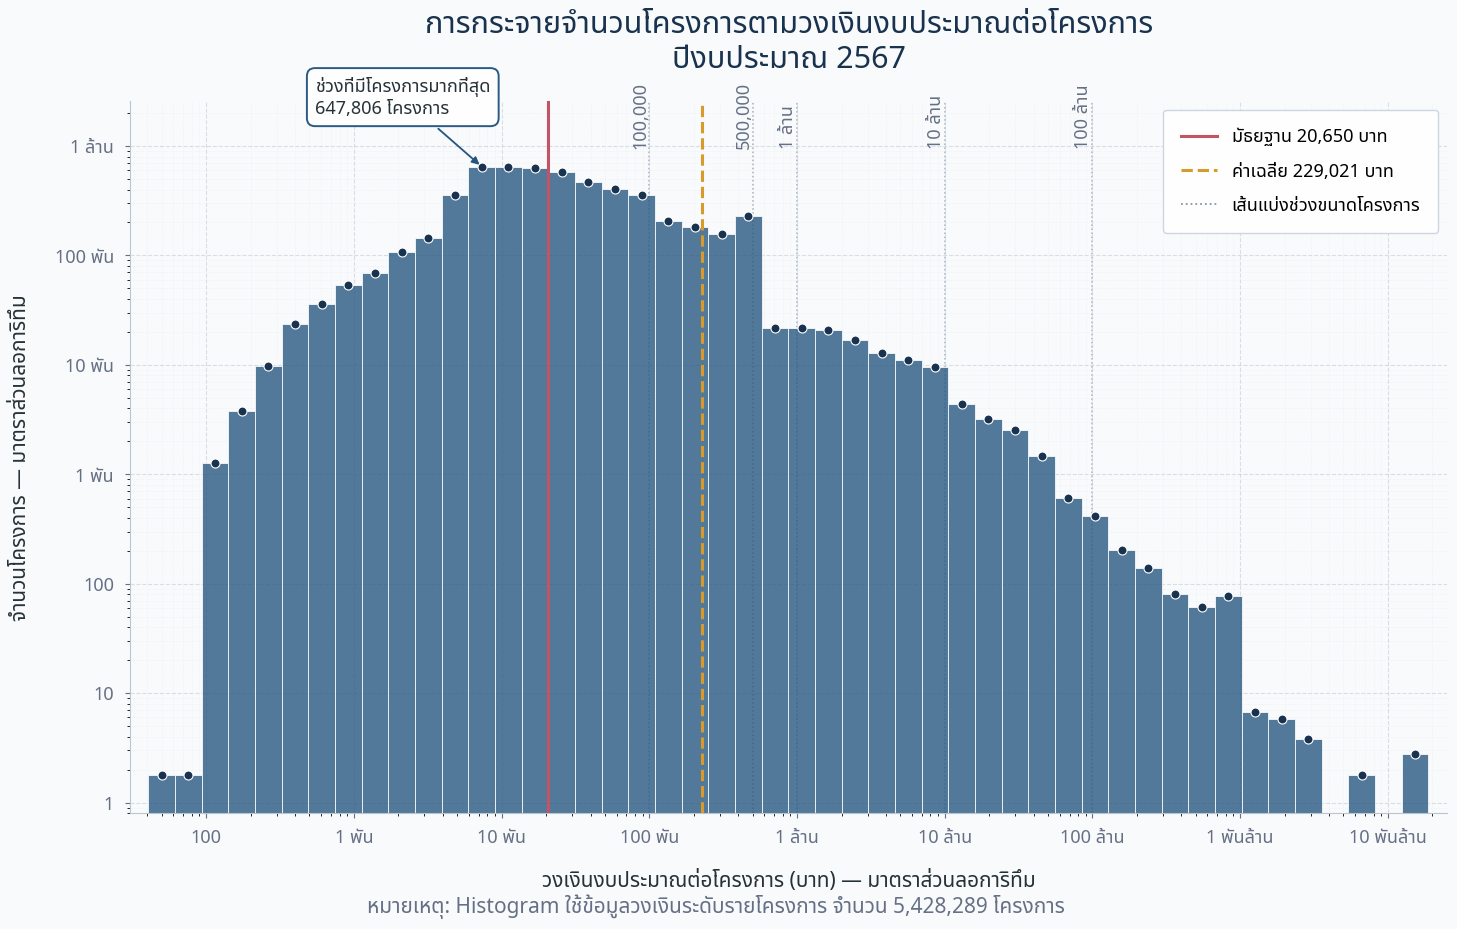

In [16]:
# ============================================================
# GRAPH 6 : การกระจายจำนวนโครงการตามวงเงินต่อโครงการ
# ใช้ Log Scale ทั้งแกน X และ Y
# ============================================================

# ปิด Figure เก่าและคืนหน่วยความจำ
plt.close("all")
gc.collect()

budget_col = "วงเงินงบประมาณ (บาท)"
NUMBER_OF_BINS = 48  # จำนวนช่วงย่อยของ Histogram

svg_file, png_file = figure_files(
    "07_project_budget_distribution_loglog"
)

# ============================================================
# 3) เตรียมข้อมูลวงเงินรายโครงการ
# ============================================================

budget_values = (
    project_overview_df[budget_col]
    .to_numpy(
        dtype="float64",
        copy=False
    )
)

# Log Scale ใช้ได้เฉพาะค่าที่มากกว่า 0
valid_mask = (
    np.isfinite(budget_values)
    & (budget_values > 0)
)

valid_budgets = budget_values[valid_mask]

excluded_projects = (
    len(budget_values)
    - len(valid_budgets)
)

minimum_budget_value = valid_budgets.min()
maximum_budget_value = valid_budgets.max()

# ใช้ค่าเดิมจาก ANALYSIS 1 หากมีอยู่แล้ว
if "mean_budget" in globals():
    mean_budget_value = mean_budget
else:
    mean_budget_value = valid_budgets.mean()

if "median_budget" in globals():
    median_budget_value = median_budget
else:
    median_budget_value = np.median(valid_budgets)


# ============================================================
# 4) สร้างช่วง Histogram แบบ Logarithmic
# ============================================================

bin_edges = np.geomspace(
    minimum_budget_value,
    maximum_budget_value,
    NUMBER_OF_BINS + 1
)

project_counts, bin_edges = np.histogram(
    valid_budgets,
    bins=bin_edges
)

# จุดกึ่งกลางของแต่ละช่วงแบบเรขาคณิต
bin_centers = np.sqrt(
    bin_edges[:-1]
    * bin_edges[1:]
)

bin_widths = np.diff(bin_edges)

# เลือกเฉพาะช่วงที่มีโครงการ
nonzero_mask = project_counts > 0

# คืนหน่วยความจำก่อนสร้างกราฟ
del budget_values
del valid_mask
del valid_budgets
gc.collect()


# ============================================================
# 5) กำหนดสี
# ============================================================

background_color = "#F8FAFC"
bar_color = "#24557F"
point_color = "#19324D"

median_color = "#C45365"
mean_color = "#D89A28"
boundary_color = "#8795A3"

title_color = "#19324D"
text_color = "#263238"
secondary_text_color = "#667085"
grid_color = "#CBD5DF"


# ============================================================
# 6) สร้างกราฟ
# ============================================================

fig, ax = plt.subplots(
    figsize=(15.5, 9.5),
    facecolor=background_color
)

ax.set_facecolor(background_color)

# ใช้ Log Scale ทั้งสองแกน
ax.set_xscale("log")
ax.set_yscale("log")


# ============================================================
# 7) Plot Histogram
# ============================================================

ax.bar(
    bin_edges[:-1][nonzero_mask],
    project_counts[nonzero_mask],
    width=bin_widths[nonzero_mask],
    align="edge",
    bottom=0.8,
    color=bar_color,
    alpha=0.78,
    edgecolor="white",
    linewidth=0.7,
    zorder=2
)

# เพิ่มจุดบนยอดแท่ง
ax.scatter(
    bin_centers[nonzero_mask],
    project_counts[nonzero_mask] + 0.8,
    s=42,
    color=point_color,
    edgecolor="white",
    linewidth=0.8,
    zorder=4
)


# ============================================================
# 8) แสดงช่วงที่มีจำนวนโครงการสูงที่สุด
# ============================================================

peak_index = np.argmax(project_counts)

peak_count = project_counts[peak_index]
peak_center = bin_centers[peak_index]
peak_lower = bin_edges[peak_index]
peak_upper = bin_edges[peak_index + 1]

ax.annotate(
    (
        f"ช่วงที่มีโครงการมากที่สุด\n"
        f"{peak_count:,.0f} โครงการ"
    ),
    xy=(
        peak_center,
        peak_count
    ),
                                     #################################################
    xytext=(-120, 35),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=13,
    fontweight="bold",
    color=text_color,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "white",
        "edgecolor": bar_color,
        "linewidth": 1.4,
        "alpha": 0.97
    },
    arrowprops={
        "arrowstyle": "-|>",
        "color": bar_color,
        "linewidth": 1.3,
        "mutation_scale": 11
    },
    zorder=6
)


# ============================================================
# 9) เส้นค่าเฉลี่ยและค่ามัธยฐาน
# ============================================================

ax.axvline(
    median_budget_value,
    color=median_color,
    linestyle="-",
    linewidth=2.2,
    zorder=5
)

ax.axvline(
    mean_budget_value,
    color=mean_color,
    linestyle="--",
    linewidth=2.2,
    zorder=5
)


# ============================================================
# 10) เส้นแบ่งช่วงจาก ANALYSIS 6
# ============================================================

size_boundaries = [
    (100_000, "100,000"),
    (500_000, "500,000"),
    (1_000_000, "1 ล้าน"),
    (10_000_000, "10 ล้าน"),
    (100_000_000, "100 ล้าน")
]

maximum_count = project_counts.max()

# เพิ่มพื้นที่ด้านบนสำหรับชื่อเส้นแบ่ง
ax.set_ylim(
    0.8,
    maximum_count * 4
)

for boundary_value, boundary_label in size_boundaries:
    ax.axvline(
        boundary_value,
        color=boundary_color,
        linestyle=":",
        linewidth=1.1,
        alpha=0.75,
        zorder=1
    )

    ax.text(
        boundary_value,
        maximum_count * 1.45,
        boundary_label,
        rotation=90,
        ha="right",
        va="bottom",
        fontsize=13,
        color=secondary_text_color
    )


# ============================================================
# 11) กำหนดขอบเขตแกน X
# ============================================================

ax.set_xlim(
    minimum_budget_value * 0.75,
    maximum_budget_value * 1.35
)


# ============================================================
# 12) จัดรูปแบบตัวเลขบนแกน
# ============================================================

def format_budget_axis(value, position):
    if value >= 1_000_000_000:
        return (
            f"{value / 1_000_000_000:g} "
            "พันล้าน"
        )
    elif value >= 1_000_000:
        return (
            f"{value / 1_000_000:g} "
            "ล้าน"
        )
    elif value >= 1_000:
        return (
            f"{value / 1_000:g} "
            "พัน"
        )
    return f"{value:g}"


def format_count_axis(value, position):
    if value >= 1_000_000:
        return (
            f"{value / 1_000_000:g} ล้าน"
        )
    elif value >= 1_000:
        return (
            f"{value / 1_000:g} พัน"
        )
    return f"{value:g}"


ax.xaxis.set_major_formatter(
    FuncFormatter(format_budget_axis)
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_count_axis)
)


# ============================================================
# 13) ชื่อกราฟและชื่อแกน
# ============================================================

ax.set_title(
    (
        "การกระจายจำนวนโครงการตามวงเงินงบประมาณต่อโครงการ\n"
        f"ปีงบประมาณ {YEAR}"
    ),
    fontsize=22,
    fontweight="bold",
    color=title_color,
    pad=24
)

ax.set_xlabel(
    "วงเงินงบประมาณต่อโครงการ (บาท) — มาตราส่วนลอการิทึม",
    fontsize=15,
    fontweight="bold",
    color=text_color,
    labelpad=16
)

ax.set_ylabel(
    "จำนวนโครงการ — มาตราส่วนลอการิทึม",
    fontsize=15,
    fontweight="bold",
    color=text_color,
    labelpad=17
)


# ============================================================
# 14) Legend
# ============================================================

legend_items = [
    Line2D(
        [0], [0],
        color=median_color,
        linestyle="-",
        linewidth=2.2,
        label=(
            f"มัธยฐาน "
            f"{median_budget_value:,.0f} บาท"
        )
    ),
    Line2D(
        [0], [0],
        color=mean_color,
        linestyle="--",
        linewidth=2.2,
        label=(
            f"ค่าเฉลี่ย "
            f"{mean_budget_value:,.0f} บาท"
        )
    ),
    Line2D(
        [0], [0],
        color=boundary_color,
        linestyle=":",
        linewidth=1.3,
        label="เส้นแบ่งช่วงขนาดโครงการ"
    )
]

ax.legend(
    handles=legend_items,
    loc="upper right",
    fontsize=13,
    facecolor="white",
    edgecolor=grid_color,
    framealpha=0.96,
    borderpad=1,
    labelspacing=0.9
)


# ============================================================
# 15) Grid และรูปแบบแกน
# ============================================================

ax.grid(
    which="major",
    linestyle="--",
    linewidth=0.8,
    color=grid_color,
    alpha=0.75,
    zorder=0
)

ax.grid(
    which="minor",
    linestyle=":",
    linewidth=0.5,
    color=grid_color,
    alpha=0.30,
    zorder=0
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=13,
    pad=8,
    colors=secondary_text_color
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#BAC5CF")
ax.spines["bottom"].set_color("#BAC5CF")


# ============================================================
# 16) หมายเหตุ
# ============================================================

fig.text(
    0.5,
    0.025,
    (
        f"หมายเหตุ: Histogram ใช้ข้อมูลวงเงินระดับรายโครงการ "
        f"จำนวน {project_counts.sum():,.0f} โครงการ "
    ),
    ha="center",
    fontsize=15,
    color=secondary_text_color
)


# ============================================================
# 17) ปรับ Layout
# ============================================================

plt.subplots_adjust(
    left=0.12,
    right=0.97,
    top=0.88,
    bottom=0.13
)


# ============================================================
# 18) บันทึก SVG
# ============================================================

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


# ============================================================
# 19) บันทึก PNG
# ============================================================

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


# ============================================================
# 20) แสดงผลและคืนหน่วยความจำ
# ============================================================

plt.show()
plt.close(fig)
gc.collect()

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

print()

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


## Analysis 7 — โครงการวงเงินสูงสุดและต่ำสุด


In [17]:
# ============================================================
# ANALYSIS 7 : โครงการที่มีวงเงินงบประมาณสูงสุดและต่ำสุด
# ============================================================

# กำหนดชื่อคอลัมน์ที่ใช้วิเคราะห์
budget_col = "วงเงินงบประมาณ (บาท)"

# ============================================================
# TOP 10 : โครงการที่มีวงเงินงบประมาณสูงที่สุด
# ============================================================

# เลือกเฉพาะรหัสโครงการและวงเงินงบประมาณ
# nlargest(10) = เลือก 10 โครงการที่มีวงเงินสูงที่สุด
top10_projects_df = project_overview_df[
    ["รหัสโครงการ", budget_col]
].nlargest(10, budget_col).reset_index(drop=True)

# เพิ่มอันดับ 1–10
top10_projects_df.insert(
    0,
    "อันดับ",
    range(1, len(top10_projects_df) + 1)
)

# ============================================================
# BOTTOM 10 : โครงการที่มีวงเงินงบประมาณต่ำที่สุด
# ============================================================

# nsmallest(10) = เลือก 10 โครงการที่มีวงเงินต่ำที่สุด
bottom10_projects_df = project_overview_df[
    ["รหัสโครงการ", budget_col]
].nsmallest(10, budget_col).reset_index(drop=True)

# เพิ่มอันดับ 1–10 โดยอันดับ 1 คือโครงการที่มีวงเงินต่ำที่สุด
bottom10_projects_df.insert(
    0,
    "อันดับ",
    range(1, len(bottom10_projects_df) + 1)
)

# ============================================================
# แสดงผล
# ============================================================

print("TOP 10 โครงการที่มีวงเงินงบประมาณสูงที่สุด")
display(
    top10_projects_df.style.format({
        budget_col: "{:,.2f}"
    })
)

print("\nBOTTOM 10 โครงการที่มีวงเงินงบประมาณต่ำที่สุด")
display(
    bottom10_projects_df.style.format({
        budget_col: "{:,.2f}"
    })
)


TOP 10 โครงการที่มีวงเงินงบประมาณสูงที่สุด


,อันดับ,รหัสโครงการ,วงเงินงบประมาณ (บาท)
0,1,67019022972,"18,740,000,000.00"
1,2,66099492923,"12,491,897,877.44"
2,3,66049381853,"7,424,830,000.00"
3,4,67069198831,"3,501,686,000.00"
4,5,66099086824,"2,550,000,000.00"
5,6,67049421235,"2,500,000,000.00"
6,7,66109198741,"1,858,484,781.00"
7,8,67069007819,"1,680,000,000.00"
8,9,66017101879,"1,614,591,000.00"
9,10,67049264946,"1,600,000,000.00"



BOTTOM 10 โครงการที่มีวงเงินงบประมาณต่ำที่สุด


,อันดับ,รหัสโครงการ,วงเงินงบประมาณ (บาท)
0,1,67069423037,40.65
1,2,67069423153,81.30
2,3,67089249357,100.00
3,4,67089701799,100.00
4,5,67089468968,100.00
5,6,67089020059,100.00
6,7,67089316036,100.00
7,8,67089130251,100.00
8,9,67089547938,100.00
9,10,67089654518,100.00


In [18]:
# ============================================================
# DISPLAY ONLY : ไม่บันทึก Top 10 และ Bottom 10 เป็น CSV
# ============================================================

top10_file = os.path.join(
    output_path,
    f"07_top10_projects_by_budget_{YEAR}.csv"
)

bottom10_file = os.path.join(
    output_path,
    f"07_bottom10_projects_by_budget_{YEAR}.csv"
)

# บันทึกเป็น UTF-8-SIG เพื่อรองรับภาษาไทยใน Excel
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

# เก็บ project_overview_df ไว้ในหน่วยความจำตลอด Runtime
# เพื่อให้ย้อนกลับไปรัน Analysis หรือสร้างกราฟเพิ่มเติมได้โดยไม่ต้อง Import ใหม่
print("✅ เก็บ project_overview_df ไว้สำหรับการวิเคราะห์ต่อเนื่อง")


✅ เก็บ project_overview_df ไว้สำหรับการวิเคราะห์ต่อเนื่อง


In [19]:
# ============================================================
# IMPORT : Top 10 และ Lower 10 Project Budget CSV
# ============================================================

# ใช้ Path ที่สร้างจาก YEAR ใน Cell SETUP
# จึงเปลี่ยนปีได้จากตัวแปร YEAR เพียงจุดเดียว
required_budget_files = {
    "top10_project_budget": top10_budget_file,
    "lower10_project_budget": lower10_budget_file
}

# ตรวจสอบไฟล์อีกครั้ง เผื่อผู้ใช้รันเซลล์นี้แยกจากลำดับ Run all
missing_budget_files = {
    input_name: input_path
    for input_name, input_path in required_budget_files.items()
    if not os.path.exists(input_path)
}

if missing_budget_files:
    missing_file_message = "\n".join(
        f"- {input_name}: {input_path}"
        for input_name, input_path in missing_budget_files.items()
    )
    raise FileNotFoundError(
        "ไม่พบไฟล์ Top 10 / Lower 10 ที่ต้องใช้สร้างตาราง:\n"
        + missing_file_message
    )

# Import เฉพาะไฟล์ขนาดเล็ก Top 10 และ Lower 10
# กำหนดรหัสโครงการเป็น String เพราะเป็น Identifier ไม่ใช่ตัวเลขสำหรับคำนวณ
top10_budget_df = pd.read_csv(
    top10_budget_file,
    dtype={"รหัสโครงการ": "string"}
)

lower10_budget_df = pd.read_csv(
    lower10_budget_file,
    dtype={"รหัสโครงการ": "string"}
)

print("TOP 10")
display(top10_budget_df)

print("\nLOWER 10")
display(lower10_budget_df)


TOP 10


,อันดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,จังหวัด,เขต/อําเภอ,วงเงินงบประมาณ (บาท)
0,1,67019022972,ประกวดราคาจ้างก่อสร้างก่อสร้างโครงการทางพิเศษฉ...,การทางพิเศษแห่งประเทศไทย,กรุงเทพมหานคร,สายไหม,1.874000e+10
1,2,66099492923,จ้างงานจ้างเอกชนบริหารจัดการผลิตน้ำประปาและบำร...,การประปาส่วนภูมิภาค,สระบุรี,เมืองสระบุรี,1.249190e+10
2,3,66049381853,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาก่อสร้างโครงก...,การท่าเรือแห่งประเทศไทย,ชลบุรี,บางละมุง,7.424830e+09
3,4,67069198831,จ้างก่อสร้างอาคารผู้ป่วยในเฉลิมพระเกียรติ คณะแ...,มหาวิทยาลัยนวมินทราธิราช,กรุงเทพมหานคร,ดุสิต,3.501686e+09
4,5,66099086824,ซื้อโครงการจัดหาเฮลิคอปเตอร์ภารกิจบุคคลสำคัญ จ...,สำนักงานตำรวจแห่งชาติ,กรุงเทพมหานคร,ดุสิต,2.550000e+09
5,6,67049421235,ประกวดราคาจ้างก่อสร้างทางแนวใหม่ สายแยกทางหลวง...,กรมทางหลวง,ปทุมธานี,สามโคก,2.500000e+09
6,7,66109198741,ประกวดราคาจ้างโครงการบริหารจัดการขยะมูลฝอยชุมช...,เทศบาลตำบลกุดน้ำใส,ขอนแก่น,น้ำพอง,1.858485e+09
7,8,67069007819,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาโครงการก่อสร้...,กรมทางหลวง,อ่างทอง,เมืองอ่างทอง,1.680000e+09
8,9,66017101879,จ้างก่อสร้างโครงการจ้่างก่อสร้างเรือนจำกลางลำป...,กรมราชทัณฑ์,ลำปาง,เมืองลำปาง,1.614591e+09
9,10,67049264946,ประกวดราคาจ้างก่อสร้างถนนสาย จ ผังเมืองรวมเมือ...,กรมทางหลวงชนบท,กำแพงเพชร,เมืองกำแพงเพชร,1.600000e+09



LOWER 10


,อันดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อหน่วยงาน,จังหวัด,เขต/อําเภอ,วงเงินงบประมาณ (บาท)
0,1,67069423037,ซื้ออาหารเสริม (นม) ปีการศึกษา 2567 สำหรับศูนย...,องค์การบริหารส่วนตำบลวังไทร,กำแพงเพชร,คลองขลุง,40.65
1,2,67069423153,ซื้ออาหารเสริม (นม) ปีการศึกษา 2567 สำหรับโรงเ...,องค์การบริหารส่วนตำบลวังไทร,กำแพงเพชร,คลองขลุง,81.30
2,3,67089249357,ซื้อวัสดุอุปกรณ์โครงการสนับสนุนศูนย์คัดกรองและ...,องค์การบริหารส่วนตำบลนาป่า,เพชรบูรณ์,เมืองเพชรบูรณ์,100.00
3,4,67089701799,จ้างเหมาจัดทำป้ายโครงการพัฒนาคุณภาพผู้เรียน ปร...,องค์การบริหารส่วนตำบลป่าแฝก,บึงกาฬ,พรเจริญ,100.00
4,5,67089468968,จ้างเหมาจัดทำตรายาง จำนวน 1 อัน กองช่าง โดยวิธ...,เทศบาลตำบลฟากท่า,อุตรดิตถ์,เมืองอุตรดิตถ์,100.00
5,6,67089020059,ซื้อวัสดุก่อสร้าง (กิจการประปา) โดยวิธีเฉพาะเ...,เทศบาลตำบลวังสวรรค์,ขอนแก่น,บ้านแฮด,100.00
6,7,67089316036,ซื้อวัสดุเชื้อเพลิงและหล่อลื่น จำนวน 1 รายการ ...,กรมอุทยานแห่งชาติ สัตว์ป่า และพันธุ์พืช,ราชบุรี,จอมบึง,100.00
7,8,67089130251,ซื้อปูนขาว จำนวน ๒ ถุง โดยวิธีเฉพาะเจาะจง,โรงพยาบาลสิชล,นครศรีธรรมราช,สิชล,100.00
8,9,67089547938,จ้างถ่ายเอกสารบันทึกการอยู่เวรยาม โดยวิธีเฉพาะ...,สำนักงานคณะกรรมการการศึกษาขั้นพื้นฐาน,เพชรบูรณ์,เมืองเพชรบูรณ์,100.00
9,10,67089654518,จ้างเหมาจัดทำป้ายโครงการพัฒนาคุณภาพผู้เรียน ปร...,องค์การบริหารส่วนตำบลป่าแฝก,บึงกาฬ,พรเจริญ,100.00


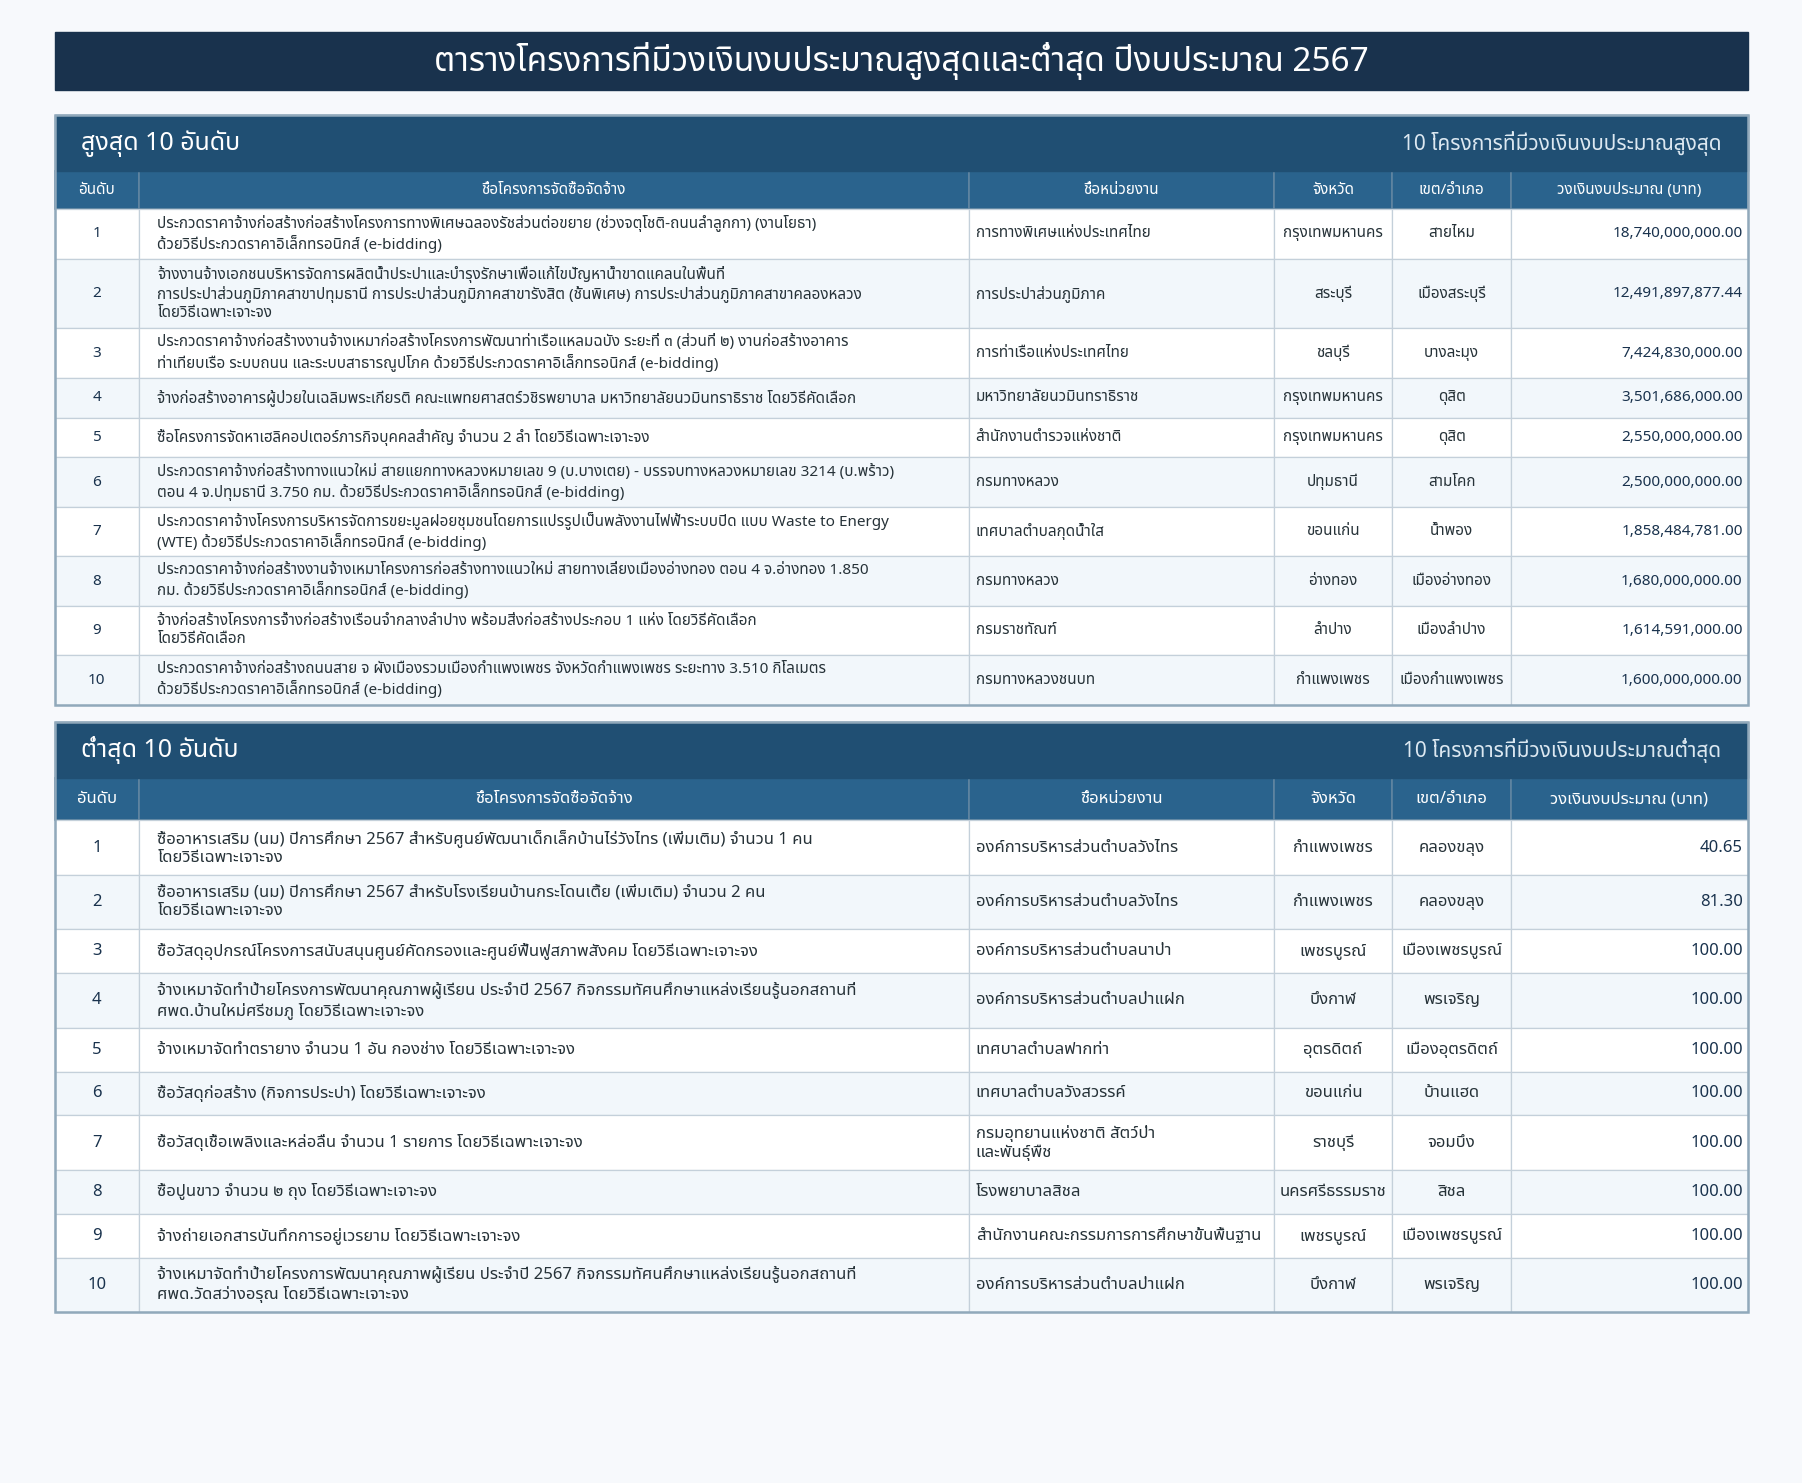

In [20]:
# ============================================================
# TABLE 7 : Top 10 และ Lower 10
# ปรับคอลัมน์ชื่อโครงการให้กว้างและลดจำนวนบรรทัด
# ============================================================

# ปิด Figure ก่อนหน้าเพื่อลดการใช้หน่วยความจำใน Colab
plt.close("all")

svg_file, png_file = figure_files(
    "08_top10_lower10_project_budget_table"
)

# ============================================================
# 2) ค้นหาคอลัมน์
# ============================================================

def find_column(dataframe, keyword):
    for column in dataframe.columns:
        if keyword in str(column):
            return column

    raise KeyError(
        f"ไม่พบคอลัมน์ที่มีคำว่า '{keyword}'"
    )


# ============================================================
# 3) เตรียม DataFrame
# ============================================================

def prepare_project_table(dataframe):
    selected_columns = [
        find_column(dataframe, "อันดับ"),
        find_column(dataframe, "ชื่อโครงการ"),
        find_column(dataframe, "ชื่อหน่วยงาน"),
        find_column(dataframe, "จังหวัด"),
        find_column(dataframe, "เขต/"),
        find_column(dataframe, "วงเงินงบประมาณ")
    ]

    prepared_df = dataframe[
        selected_columns
    ].copy()

    prepared_df.columns = [
        "rank",
        "project_name",
        "agency",
        "province",
        "district",
        "budget"
    ]

    prepared_df["rank"] = pd.to_numeric(
        prepared_df["rank"],
        errors="coerce"
    )

    prepared_df["budget"] = pd.to_numeric(
        prepared_df["budget"],
        errors="coerce"
    )

    return (
        prepared_df
        .sort_values("rank")
        .reset_index(drop=True)
    )


top_table_df = prepare_project_table(
    top10_budget_df
)

lower_table_df = prepare_project_table(
    lower10_budget_df
)


# ============================================================
# 4) ฟังก์ชันจัดข้อความ
# ============================================================

def clean_text(value):
    if pd.isna(value):
        return "-"

    return " ".join(str(value).split())


def character_width(character):
    """
    ประมาณความกว้างของตัวอักษร
    ภาษาอังกฤษและตัวเลขกว้างกว่าตัวอักษรไทยเล็กน้อย
    """
    if character.isascii():
        return 1.35

    return 1.0


def text_width(text):
    return sum(
        character_width(character)
        for character in text
    )


def split_long_word(word, max_width):
    pieces = []
    current = ""

    for character in word:
        candidate = current + character

        if text_width(candidate) <= max_width:
            current = candidate
        else:
            if current:
                pieces.append(current)

            current = character

    if current:
        pieces.append(current)

    return pieces


def smart_wrap(
    value,
    max_width=110,
    max_lines=3
):
    """
    ตัดข้อความโดยพยายามใช้พื้นที่เต็มความกว้างของเซลล์
    และตัดตรงช่องว่างก่อน
    """
    text = clean_text(value)
    words = text.split(" ")

    lines = []
    current_line = ""

    for word in words:
        candidate = (
            word
            if not current_line
            else current_line + " " + word
        )

        if text_width(candidate) <= max_width:
            current_line = candidate
            continue

        if current_line:
            lines.append(current_line)
            current_line = ""

        # กรณีคำภาษาไทยยาวมากและไม่มีช่องว่าง
        if text_width(word) > max_width:
            word_parts = split_long_word(
                word,
                max_width
            )

            for word_part in word_parts[:-1]:
                lines.append(word_part)

            current_line = word_parts[-1]
        else:
            current_line = word

    if current_line:
        lines.append(current_line)

    # จำกัดไม่เกิน 3 บรรทัด
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1].rstrip() + "…"

    return "\n".join(lines)


def format_rank(value):
    if pd.isna(value):
        return "-"

    return f"{int(value)}"


def format_budget(value):
    if pd.isna(value):
        return "-"

    return f"{value:,.2f}"


# ============================================================
# 5) สร้างข้อความในแต่ละเซลล์
# ============================================================

def create_cell_text(dataframe):
    rows = []

    for _, row in dataframe.iterrows():
        rows.append(
            [
                format_rank(row["rank"]),

                # ใช้ความยาวประมาณ 110 หน่วยต่อบรรทัด
                smart_wrap(
                    row["project_name"],
                    max_width=110,
                    max_lines=3
                ),

                smart_wrap(
                    row["agency"],
                    max_width=38,
                    max_lines=3
                ),

                smart_wrap(
                    row["province"],
                    max_width=18,
                    max_lines=2
                ),

                smart_wrap(
                    row["district"],
                    max_width=18,
                    max_lines=2
                ),

                format_budget(row["budget"])
            ]
        )

    return rows


top_cell_text = create_cell_text(
    top_table_df
)

lower_cell_text = create_cell_text(
    lower_table_df
)


# ============================================================
# 6) หัวคอลัมน์และความกว้าง
# ============================================================

column_labels = [
    "อันดับ",
    "ชื่อโครงการจัดซื้อจัดจ้าง",
    "ชื่อหน่วยงาน",
    "จังหวัด",
    "เขต/อำเภอ",
    "วงเงินงบประมาณ (บาท)"
]

# รวมเท่ากับ 1.00
# เพิ่มคอลัมน์ชื่อโครงการเป็น 49%
column_widths = [
    0.05,   # อันดับ
    0.49,   # ชื่อโครงการ
    0.18,   # ชื่อหน่วยงาน
    0.07,   # จังหวัด
    0.07,   # เขต/อำเภอ
    0.14    # วงเงิน
]


# ============================================================
# 7) สี
# ============================================================

figure_background = "#F7F9FC"

title_color = "#19324D"
section_color = "#204F73"
header_color = "#2A638D"

header_border = "#6085A1"
cell_border = "#C4D0DA"

body_white = "#FFFFFF"
body_blue = "#F2F7FB"

text_color = "#263238"
budget_text_color = "#19324D"
secondary_text_color = "#667085"


# ============================================================
# 8) สร้าง Figure
# ลดความสูงลงจากรุ่นเดิม
# ============================================================

fig, ax = plt.subplots(
    figsize=(23, 19),
    facecolor=figure_background
)

ax.set_facecolor(figure_background)
ax.axis("off")


# ============================================================
# 9) ตำแหน่งองค์ประกอบ
# ============================================================

left = 0.025
full_width = 0.95

title_y = 0.945
title_height = 0.040

top_section_y = 0.890
section_height = 0.038

top_table_y = 0.525
table_height = 0.365

lower_section_y = 0.475
lower_table_y = 0.110

note_y = 0.035
note_height = 0.045


# ============================================================
# 10) ชื่อตารางหลัก
# ============================================================

ax.add_patch(
    Rectangle(
        (left, title_y),
        full_width,
        title_height,
        transform=ax.transAxes,
        facecolor=title_color,
        edgecolor=title_color
    )
)

ax.text(
    0.5,
    title_y + title_height / 2,
    (
        "ตารางโครงการที่มีวงเงินงบประมาณสูงสุดและต่ำสุด "
        f"ปีงบประมาณ {YEAR}"
    ),
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color="white"
)


# ============================================================
# 11) หัวข้อ Top 10 และ Lower 10
# ============================================================

def add_section_header(y, title, subtitle):
    ax.add_patch(
        Rectangle(
            (left, y),
            full_width,
            section_height,
            transform=ax.transAxes,
            facecolor=section_color,
            edgecolor=section_color
        )
    )

    ax.text(
        left + 0.015,
        y + section_height / 2,
        title,
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="white"
    )

    ax.text(
        left + full_width - 0.015,
        y + section_height / 2,
        subtitle,
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=15,
        color="#DCE8F1"
    )


add_section_header(
    top_section_y,
    "สูงสุด 10 อันดับ",
    "10 โครงการที่มีวงเงินงบประมาณสูงสุด"
)

add_section_header(
    lower_section_y,
    "ต่ำสุด 10 อันดับ",
    "10 โครงการที่มีวงเงินงบประมาณต่ำสุด"
)


# ============================================================
# 12) คำนวณความสูงของแต่ละแถว
# ============================================================

def calculate_row_heights(cell_text):
    row_weights = [1.30]

    for row in cell_text:
        maximum_lines = max(
            str(value).count("\n") + 1
            for value in row
        )

        row_weight = max(
            1.35,
            1.0 + (maximum_lines - 1) * 0.68
        )

        row_weights.append(row_weight)

    total_weight = sum(row_weights)

    return [
        weight / total_weight
        for weight in row_weights
    ]


# ============================================================
# 13) สร้างตารางแบบ Dynamic Height
# ============================================================

def draw_dynamic_table(cell_text, table_y):
    row_heights = calculate_row_heights(
        cell_text
    )

    table = Table(
        ax,
        bbox=[
            left,
            table_y,
            full_width,
            table_height
        ]
    )

    # หัวคอลัมน์
    for column_index, column_label in enumerate(
        column_labels
    ):
        cell = table.add_cell(
            row=0,
            col=column_index,
            width=column_widths[column_index],
            height=row_heights[0],
            text=column_label,
            loc="center",
            facecolor=header_color,
            edgecolor=header_border
        )

        cell.set_linewidth(1.2)
        cell.PAD = 0.022

        text = cell.get_text()
        text.set_color("white")
        text.set_fontsize(15)
        text.set_fontweight("bold")
        text.set_ha("center")
        text.set_va("center")

    # ข้อมูล
    for row_index, row_values in enumerate(
        cell_text,
        start=1
    ):
        row_color = (
            body_white
            if row_index % 2 == 1
            else body_blue
        )

        for column_index, value in enumerate(
            row_values
        ):
            if column_index in [0, 3, 4]:
                location = "center"
            elif column_index == 5:
                location = "right"
            else:
                location = "left"

            cell = table.add_cell(
                row=row_index,
                col=column_index,
                width=column_widths[column_index],
                height=row_heights[row_index],
                text=value,
                loc=location,
                facecolor=row_color,
                edgecolor=cell_border
            )

            cell.set_linewidth(0.9)
            cell.PAD = 0.022

            text = cell.get_text()
            text.set_va("center")
            text.set_linespacing(1.23)
            text.set_color(text_color)

            if column_index == 0:
                text.set_fontsize(15)
                text.set_fontweight("bold")
                text.set_color(title_color)
                text.set_ha("center")

            elif column_index == 1:
                # เพิ่มขนาดชื่อโครงการ
                text.set_fontsize(15)
                text.set_ha("left")

            elif column_index == 2:
                text.set_fontsize(15)
                text.set_ha("left")

            elif column_index in [3, 4]:
                text.set_fontsize(15)
                text.set_ha("center")

            elif column_index == 5:
                text.set_fontsize(15)
                text.set_fontweight("bold")
                text.set_color(budget_text_color)
                text.set_ha("right")

    ax.add_table(table)

    return table


top_table = draw_dynamic_table(
    top_cell_text,
    top_table_y
)

lower_table = draw_dynamic_table(
    lower_cell_text,
    lower_table_y
)


# ============================================================
# 14) เส้นขอบรอบ Section
# ============================================================

for table_y, section_y in [
    (top_table_y, top_section_y),
    (lower_table_y, lower_section_y)
]:
    ax.add_patch(
        Rectangle(
            (left, table_y),
            full_width,
            section_y + section_height - table_y,
            transform=ax.transAxes,
            facecolor="none",
            edgecolor="#91A9BB",
            linewidth=1.8
        )
    )


# ============================================================
# 15) หมายเหตุ
# ============================================================

# ax.add_patch(
#     Rectangle(
#         (left, note_y),
#         full_width,
#         note_height,
#         transform=ax.transAxes,
#         facecolor="#EAF2F8",
#         edgecolor="#9EB5C6",
#         linewidth=1.2
#     )
# )

# ax.text(
#     0.5,
#     note_y + note_height / 2,
#     (
#         "หมายเหตุ: ---- "
#     ),
#     transform=ax.transAxes,
#     ha="center",
#     va="center",
#     fontsize=15,
#     color=secondary_text_color
# )


# ============================================================
# 16) บันทึก SVG และ PNG
# ============================================================

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


# ============================================================
# 17) แสดงผล
# ============================================================

plt.show()
plt.close(fig)

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


## Analysis 8 — Map plot

In [21]:
# ============================================================
# โหลดแผนที่ประเทศไทยระดับจังหวัดจาก GeoJSON บน GitHub
# ============================================================

import geopandas as gpd

# URL ของไฟล์ GeoJSON ขอบเขต 77 จังหวัดของประเทศไทย
geojson_url = (
    "https://raw.githubusercontent.com/"
    "chingchai/OpenGISData-Thailand/master/provinces.geojson"
)

# Cache ไฟล์ไว้ใน Colab Runtime เพื่อไม่ต้องดาวน์โหลดใหม่เมื่อรันซ้ำ
geojson_cache_path = "/content/thailand_provinces.geojson"

if not os.path.exists(geojson_cache_path):
    urllib.request.urlretrieve(geojson_url, geojson_cache_path)

# อ่านเฉพาะไฟล์ Cache ที่ตรวจสอบแล้ว
thai_map = gpd.read_file(geojson_cache_path)

# ตรวจสอบขนาดข้อมูล
print("จำนวนจังหวัด:", len(thai_map))

# ตรวจสอบชื่อ column
print("\nColumns:")
print(thai_map.columns.tolist())

# ดูข้อมูลตัวอย่าง
display(thai_map.head())


จำนวนจังหวัด: 77

Columns:
['pro_code', 'pro_th', 'pro_en', 'reg_nesdb', 'reg_royin', 'perimeter', 'area_sqkm', 'geometry']


,pro_code,pro_th,pro_en,reg_nesdb,reg_royin,perimeter,area_sqkm,geometry
0,56,พะเยา,Phayao,UpperNorth,North,442.838839,6189.635950,"MULTIPOLYGON (((100.27194 18.81875, 100.23968 ..."
1,57,เชียงราย,Chiang Rai,UpperNorth,North,668.416725,11583.012365,"MULTIPOLYGON (((99.53646 19.16314, 99.55039 19..."
2,54,แพร่,Phrae,UpperNorth,North,515.746817,6484.532497,"MULTIPOLYGON (((99.49711 17.77145, 99.48698 17..."
3,55,น่าน,Nan,UpperNorth,North,674.017891,12165.114094,"MULTIPOLYGON (((100.5524 18.03491, 100.55055 1..."
4,63,ตาก,Tak,LowwerNorth,West,1350.975407,17318.857031,"MULTIPOLYGON (((99.10549 16.0496, 99.08806 16...."


RAM ก่อนสร้างแผนที่: 19.3%
จำนวนจังหวัดใน GeoJSON: 77 จังหวัด
จำนวนจังหวัดที่ใช้คำนวณสเกลสี: 76 จังหวัด
ไม่นำกรุงเทพมหานครมาคำนวณสเกลสี เนื่องจากมีวงเงินสูงโดดเด่นกว่าจังหวัดอื่นมาก
จับคู่ข้อมูลสำเร็จ: 76 จังหวัด
จำนวนภูมิภาคที่พบ: 6 ภูมิภาค


,ภูมิภาค,จังหวัด,วงเงินรวม (บาท)
0,ภาคตะวันออก,ชลบุรี,"40,721,485,350.78"
1,ภาคกลาง,นนทบุรี,"36,758,658,669.84"
2,ภาคตะวันออกเฉียงเหนือ,นครราชสีมา,"33,188,537,204.98"
3,ภาคเหนือ,เชียงใหม่,"31,634,539,717.58"
4,ภาคใต้,สงขลา,"23,567,448,181.47"
5,ภาคตะวันตก,กาญจนบุรี,"15,150,262,403.99"


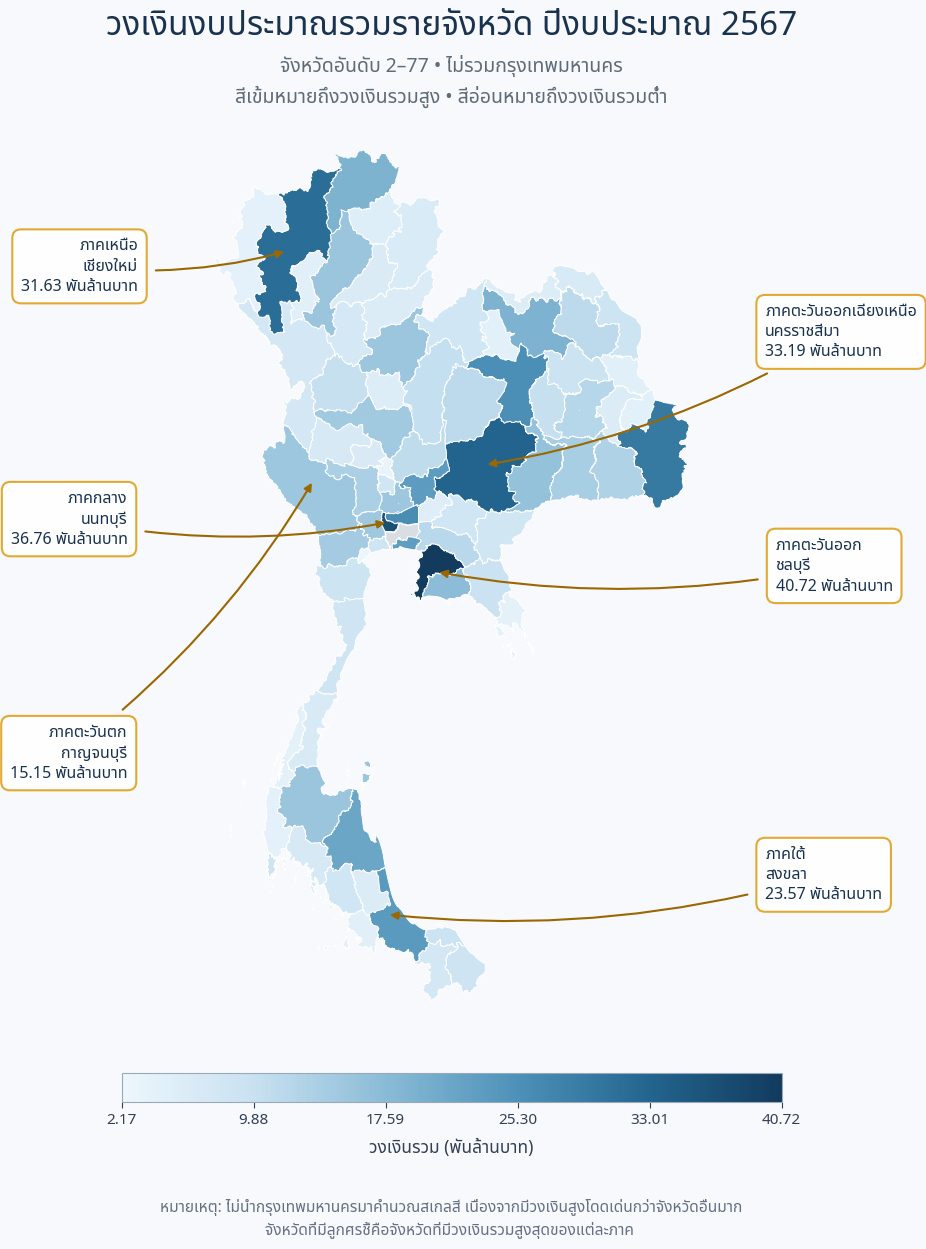

✅ ปิด Figure และลบ DataFrame ชั่วคราวแล้ว
✅ ไม่มี worker หรือ subprocess ถูกสร้างจากขั้นตอนนี้


In [22]:
# ============================================================
# MAP : วงเงินงบประมาณรวมรายจังหวัด อันดับ 2–77
# พร้อมลูกศรชี้จังหวัดที่มีวงเงินสูงสุดของแต่ละภาค
#
# - ไม่รวมกรุงเทพมหานครในการคำนวณสเกลสี
# ============================================================

import unicodedata


# ============================================================
# 1) ตรวจสอบตัวแปรที่จำเป็น
# ============================================================

if "YEAR" not in globals():
    raise NameError(
        "ไม่พบตัวแปร YEAR กรุณารันเซลล์ PARAMETERS ก่อน"
    )

if "province_df" not in globals():
    raise NameError(
        "ไม่พบ province_df กรุณารันส่วน Analysis 3 ก่อน"
    )

required_province_columns = [
    "จังหวัด",
    "วงเงินรวม (บาท)"
]

missing_columns = [
    column
    for column in required_province_columns
    if column not in province_df.columns
]

if missing_columns:
    raise KeyError(
        "province_df ขาดคอลัมน์ที่จำเป็น: "
        + ", ".join(missing_columns)
    )


# ============================================================
# 2) Memory-Safe Cleanup และตรวจสอบ RAM
# ============================================================

# ปิด Figure ที่อาจค้างจากกราฟก่อนหน้า
plt.close("all")
gc.collect()

try:
    import psutil

    memory_status = psutil.virtual_memory()

    print(
        f"RAM ก่อนสร้างแผนที่: "
        f"{memory_status.percent:.1f}%"
    )

    if memory_status.percent >= 80:

        gc.collect()
        memory_status = psutil.virtual_memory()

        if memory_status.percent >= 80:
            raise MemoryError(
                "RAM ถูกใช้งานตั้งแต่ 80% ขึ้นไป "
                "แนะนำให้ Restart Runtime ก่อนสร้างแผนที่"
            )

except ImportError:
    print(
        "ไม่พบ psutil — ดำเนินการด้วยวิธีประหยัดหน่วยความจำ"
    )


# ============================================================
# 3) กำหนดตำแหน่งบันทึกไฟล์
# ============================================================

# ใช้ฟังก์ชันส่วนกลางเพื่อสร้างชื่อไฟล์ตาม YEAR โดยอัตโนมัติ
svg_file, png_file = figure_files(
    "09_thailand_province_budget_map_highlights"
)


# ============================================================
# 4) ใช้ GeoJSON ที่โหลดและ Cache ไว้ใน Cell ก่อนหน้า
# ============================================================

if "thai_map" not in globals():
    raise NameError(
        "ไม่พบ thai_map กรุณารัน Cell โหลดแผนที่ก่อน"
    )

required_map_columns = [
    "pro_th",
    "reg_royin",
    "geometry"
]

missing_map_columns = [
    column
    for column in required_map_columns
    if column not in thai_map.columns
]

if missing_map_columns:
    raise KeyError(
        "GeoJSON ขาดคอลัมน์ที่จำเป็น: "
        + ", ".join(missing_map_columns)
    )

print(
    f"จำนวนจังหวัดใน GeoJSON: "
    f"{len(thai_map):,} จังหวัด"
)


# ============================================================
# 5) ฟังก์ชันปรับชื่อจังหวัดก่อน Merge
# ============================================================

def normalize_province_name(value):
    """
    ปรับชื่อจังหวัดให้อยู่ในรูปแบบเดียวกัน
    เพื่อลดปัญหาช่องว่างและ Unicode ที่แตกต่างกัน
    """

    if pd.isna(value):
        return pd.NA

    province_name = unicodedata.normalize(
        "NFC",
        str(value)
    ).strip()

    # ลบคำว่า "จังหวัด" หากอยู่ด้านหน้า
    if province_name.startswith("จังหวัด"):

        province_name = province_name.removeprefix(
            "จังหวัด"
        ).strip()

    # รองรับชื่อจังหวัดที่อาจเขียนแตกต่างกัน
    province_aliases = {
        "กรุงเทพ": "กรุงเทพมหานคร",
        "กรุงเทพฯ": "กรุงเทพมหานคร",
        "กทม.": "กรุงเทพมหานคร",
        "อยุธยา": "พระนครศรีอยุธยา"
    }

    return province_aliases.get(
        province_name,
        province_name
    )


# ============================================================
# 6) เตรียมข้อมูลงบประมาณเฉพาะคอลัมน์ที่ใช้
# ============================================================

# province_df มีเพียง 77 แถว
# เลือกเฉพาะคอลัมน์ที่จำเป็นเพื่อลดการใช้หน่วยความจำ
province_budget_small = province_df[
    [
        "จังหวัด",
        "วงเงินรวม (บาท)"
    ]
].copy()

province_budget_small["province_key"] = (
    province_budget_small["จังหวัด"]
    .map(normalize_province_name)
)

province_budget_small["total_budget"] = pd.to_numeric(
    province_budget_small["วงเงินรวม (บาท)"],
    errors="coerce"
)

province_budget_small = (
    province_budget_small[
        [
            "province_key",
            "total_budget"
        ]
    ]
    .dropna(
        subset=[
            "province_key",
            "total_budget"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 7) ตัดกรุงเทพมหานครออกจากการคำนวณ
# ============================================================

excluded_province = "กรุงเทพมหานคร"

province_budget_small = (
    province_budget_small.loc[
        province_budget_small["province_key"]
        != excluded_province
    ]
    .sort_values(
        "total_budget",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    f"จำนวนจังหวัดที่ใช้คำนวณสเกลสี: "
    f"{len(province_budget_small):,} จังหวัด"
)

print(
    "ไม่นำกรุงเทพมหานครมาคำนวณสเกลสี "
    "เนื่องจากมีวงเงินสูงโดดเด่นกว่าจังหวัดอื่นมาก"
)


# ============================================================
# 8) เตรียมข้อมูลแผนที่เฉพาะคอลัมน์ที่ใช้
# ============================================================

map_small = thai_map[
    [
        "pro_th",
        "reg_royin",
        "geometry"
    ]
].copy()

map_small["province_key"] = (
    map_small["pro_th"]
    .map(normalize_province_name)
)

map_small["region"] = (
    map_small["reg_royin"]
    .astype("string")
    .str.strip()
)


# ============================================================
# 9) ตรวจ Duplicate Keys ก่อน Merge
# ป้องกัน Many-to-Many Row Explosion
# ============================================================

duplicate_budget_keys = (
    province_budget_small.loc[
        province_budget_small["province_key"].duplicated(
            keep=False
        ),
        "province_key"
    ]
    .dropna()
    .unique()
    .tolist()
)

duplicate_map_keys = (
    map_small.loc[
        map_small["province_key"].duplicated(
            keep=False
        ),
        "province_key"
    ]
    .dropna()
    .unique()
    .tolist()
)

if duplicate_budget_keys:
    raise ValueError(
        "พบชื่อจังหวัดซ้ำใน province_df: "
        + ", ".join(duplicate_budget_keys)
    )

if duplicate_map_keys:
    raise ValueError(
        "พบชื่อจังหวัดซ้ำใน GeoJSON: "
        + ", ".join(duplicate_map_keys)
    )


# ============================================================
# 10) ตรวจชื่อจังหวัดที่จับคู่ไม่ได้
# ============================================================

budget_provinces = set(
    province_budget_small["province_key"]
)

map_provinces = set(
    map_small["province_key"]
)

not_found_in_map = sorted(
    budget_provinces - map_provinces
)

# ไม่นับกรุงเทพมหานครเป็นจังหวัดที่ไม่มีข้อมูล
no_budget_data = sorted(
    (map_provinces - budget_provinces)
    - {excluded_province}
)

if not_found_in_map:
    print(
        "⚠️ จังหวัดในข้อมูลงบประมาณที่ไม่พบในแผนที่:",
        not_found_in_map
    )

if no_budget_data:
    print(
        "⚠️ จังหวัดในแผนที่ที่ไม่มีข้อมูลงบประมาณ:",
        no_budget_data
    )


# ============================================================
# 11) Merge ข้อมูลงบประมาณกับแผนที่
# ============================================================

thai_budget_map = map_small.merge(
    province_budget_small,
    on="province_key",
    how="left",
    validate="one_to_one"
)

thai_budget_map = gpd.GeoDataFrame(
    thai_budget_map,
    geometry="geometry",
    crs=thai_map.crs
)

matched_provinces = (
    thai_budget_map["total_budget"]
    .notna()
    .sum()
)

print(
    f"จับคู่ข้อมูลสำเร็จ: "
    f"{matched_provinces:,} จังหวัด"
)


# ============================================================
# 12) กำหนดสเกลสี
# ============================================================

positive_budget = thai_budget_map.loc[
    thai_budget_map["total_budget"] > 0,
    "total_budget"
]

if positive_budget.empty:
    raise ValueError(
        "ไม่พบวงเงินรวมที่มากกว่า 0 สำหรับสร้างแผนที่"
    )

minimum_budget = positive_budget.min()
maximum_budget = positive_budget.max()

# สีฟ้าอ่อน → น้ำเงินเข้ม
budget_cmap = LinearSegmentedColormap.from_list(
    "province_budget_blue",
    [
        "#EDF6FC",
        "#C8E1F1",
        "#8ABBD6",
        "#4D91B8",
        "#23658F",
        "#123B5D"
    ]
)

# กรุงเทพมหานครและจังหวัดที่ไม่มีข้อมูลเป็นสีเทา
budget_cmap.set_bad("#D9DEE5")

if minimum_budget == maximum_budget:
    maximum_budget = minimum_budget + 1

color_norm = Normalize(
    vmin=minimum_budget,
    vmax=maximum_budget
)

colorbar_ticks = np.linspace(
    minimum_budget,
    maximum_budget,
    num=6
)


# ============================================================
# 13) เลือกจังหวัดวงเงินสูงสุดของแต่ละภาค
# ============================================================

highlight_source = thai_budget_map.loc[
    (
        thai_budget_map["province_key"]
        != excluded_province
    )
    & thai_budget_map["total_budget"].notna()
    & thai_budget_map["region"].notna()
].copy()

# เรียงวงเงินจากมากไปน้อย
# แล้วเลือกจังหวัดอันดับแรกของแต่ละภาค
regional_highlights = (
    highlight_source
    .sort_values(
        "total_budget",
        ascending=False
    )
    .drop_duplicates(
        subset="region",
        keep="first"
    )
    .reset_index(drop=True)
)


# ============================================================
# 14) แปลงชื่อภูมิภาคเป็นภาษาไทย
# ============================================================

region_name_mapping = {
    "north": "ภาคเหนือ",
    "northeast": "ภาคตะวันออกเฉียงเหนือ",
    "north east": "ภาคตะวันออกเฉียงเหนือ",
    "northeastern": "ภาคตะวันออกเฉียงเหนือ",
    "central": "ภาคกลาง",
    "east": "ภาคตะวันออก",
    "eastern": "ภาคตะวันออก",
    "west": "ภาคตะวันตก",
    "western": "ภาคตะวันตก",
    "south": "ภาคใต้",
    "southern": "ภาคใต้"
}


def get_thai_region_name(region_value):

    region_key = str(region_value).strip().lower()

    return region_name_mapping.get(
        region_key,
        str(region_value)
    )


regional_highlights["region_thai"] = (
    regional_highlights["region"]
    .map(get_thai_region_name)
)

print(
    f"จำนวนภูมิภาคที่พบ: "
    f"{len(regional_highlights):,} ภูมิภาค"
)


# ============================================================
# 15) สร้างแผนที่
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 13),
    facecolor="#F7F9FC"
)

ax.set_facecolor("#F7F9FC")

thai_budget_map.plot(
    column="total_budget",
    cmap=budget_cmap,
    norm=color_norm,
    linewidth=0.70,
    edgecolor="#FFFFFF",
    missing_kwds={
        "color": "#D9DEE5",
        "edgecolor": "#FFFFFF",
        "label": "ไม่รวมในการคำนวณ"
    },
    ax=ax
)

ax.set_axis_off()
ax.set_aspect("equal")


# ============================================================
# 16) กำหนดตำแหน่งกล่องข้อความนอกแผนที่
# ============================================================

# ใช้พิกัดแบบ Axes Fraction
# X < 0 หมายถึงอยู่นอกแผนที่ทางซ้าย
# X > 1 หมายถึงอยู่นอกแผนที่ทางขวา
region_box_positions = {
    "ภาคเหนือ": (-0.10, 0.83),
    "ภาคตะวันออกเฉียงเหนือ": (1.10, 0.76),
    "ภาคกลาง": (-0.12, 0.56),
    "ภาคตะวันออก": (1.12, 0.51),
    "ภาคตะวันตก": (-0.12, 0.31),
    "ภาคใต้": (1.10, 0.18)
}

# ตำแหน่งสำรองหากชื่อภูมิภาคไม่ตรงกับ Mapping
fallback_box_positions = [
    (-0.10, 0.83),
    (1.10, 0.76),
    (-0.12, 0.56),
    (1.12, 0.51),
    (-0.12, 0.31),
    (1.10, 0.18)
]

arrow_color = "#9A6700"
box_border_color = "#E1A72D"


# ============================================================
# 17) วาดเฉพาะลูกศรและกล่องข้อความ
# ไม่มีจุด Scatter
# ============================================================

for highlight_index, (_, row) in enumerate(
    regional_highlights.iterrows()
):

    region_thai = row["region_thai"]

    # ใช้จุดที่อยู่ภายในพื้นที่จังหวัดเป็นปลายลูกศร
    anchor_point = row.geometry.representative_point()

    x_position = anchor_point.x
    y_position = anchor_point.y

    box_position = region_box_positions.get(
        region_thai,
        fallback_box_positions[
            highlight_index % len(fallback_box_positions)
        ]
    )

    # จัดข้อความและความโค้งของลูกศรตามด้านของกล่อง
    if box_position[0] < 0:

        horizontal_alignment = "right"
        curve_direction = 0.10

    else:

        horizontal_alignment = "left"
        curve_direction = -0.10

    ax.annotate(
        (
            f"{region_thai}\n"
            f"{row['province_key']}\n"
            f"{row['total_budget'] / 1_000_000_000:,.2f} "
            "พันล้านบาท"
        ),

        # ปลายลูกศร
        xy=(
            x_position,
            y_position
        ),
        xycoords="data",

        # กล่องข้อความอยู่นอกพื้นที่แผนที่
        xytext=box_position,
        textcoords="axes fraction",

        ha=horizontal_alignment,
        va="center",
        fontsize=11.5,
        fontweight="bold",
        color="#19324D",
        linespacing=1.35,

        bbox={
            "boxstyle": "round,pad=0.55",
            "facecolor": "#FFFFFF",
            "edgecolor": box_border_color,
            "linewidth": 1.5,
            "alpha": 0.97
        },

        arrowprops={
            "arrowstyle": "-|>",
            "color": arrow_color,
            "linewidth": 1.5,
            "shrinkA": 6,
            "shrinkB": 2,
            "connectionstyle": (
                f"arc3,rad={curve_direction}"
            )
        },

        # อนุญาตให้กล่องข้อความอยู่นอก Axes
        annotation_clip=False,
        zorder=7
    )


# ============================================================
# 18) ชื่อกราฟ
# ============================================================

fig.suptitle(
    (
        "วงเงินงบประมาณรวมรายจังหวัด "
        f"ปีงบประมาณ {YEAR}"
    ),
    fontsize=24,
    fontweight="bold",
    color="#19324D",
    y=0.965 ###########################################################
)

ax.set_title(
    (
        "จังหวัดอันดับ 2–77 • ไม่รวมกรุงเทพมหานคร\n"
        "สีเข้มหมายถึงวงเงินรวมสูง • สีอ่อนหมายถึงวงเงินรวมต่ำ"
    ),
    fontsize=14,
    color="#5E6B78",
    pad=-200,         #########################
    linespacing=1.5
)


# ============================================================
# 19) เว้นพื้นที่รอบแผนที่สำหรับกล่องข้อความ
# ============================================================

plt.subplots_adjust(
    left=0.25,
    right=0.75,
    top=0.89,
    bottom=0.17
)


# ============================================================
# 20) Colorbar แนวนอน
# ============================================================

scalar_mappable = plt.cm.ScalarMappable(
    norm=color_norm,
    cmap=budget_cmap
)

scalar_mappable.set_array([])

# Colorbar อยู่ด้านล่าง จึงไม่ทับกล่องข้อความ
colorbar_axis = fig.add_axes(
    [
        0.28,   # ตำแหน่งจากด้านซ้าย
        0.125,  # ตำแหน่งจากด้านล่าง  #############################
        0.44,   # ความกว้าง
        0.022   # ความสูง
    ]
)

colorbar = fig.colorbar(
    scalar_mappable,
    cax=colorbar_axis,
    orientation="horizontal"
)

colorbar.set_ticks(colorbar_ticks)

colorbar.ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        f"{value / 1_000_000_000:,.2f}"
    )
)

colorbar.ax.tick_params(
    labelsize=11,
    colors="#334155",
    length=4,
    pad=4
)

colorbar.outline.set_edgecolor("#9AA9B7")
colorbar.outline.set_linewidth(0.8)

colorbar.set_label(
    "วงเงินรวม (พันล้านบาท)",
    fontsize=12.5,
    fontweight="bold",
    color="#334155",
    labelpad=8
)


# ============================================================
# 21) หมายเหตุ
# ============================================================

fig.text(
    0.50,
    0.035,
    (
        "หมายเหตุ: ไม่นำกรุงเทพมหานครมาคำนวณสเกลสี "
        "เนื่องจากมีวงเงินสูงโดดเด่นกว่าจังหวัดอื่นมาก\n"
        "จังหวัดที่มีลูกศรชี้คือจังหวัดที่มีวงเงินรวมสูงสุดของแต่ละภาค "
    ),
    ha="center",
    va="center",
    fontsize=11.2,
    color="#667085",
    linespacing=1.5
)


# ============================================================
# 22) แสดงตารางจังหวัดเด่นเพื่อตรวจสอบ
# ============================================================

highlight_summary = regional_highlights[
    [
        "region_thai",
        "province_key",
        "total_budget"
    ]
].copy()

highlight_summary = highlight_summary.rename(
    columns={
        "region_thai": "ภูมิภาค",
        "province_key": "จังหวัด",
        "total_budget": "วงเงินรวม (บาท)"
    }
)

display(
    highlight_summary.style.format({
        "วงเงินรวม (บาท)": "{:,.2f}"
    })
)


# ============================================================
# 23) บันทึก SVG และ PNG
# ============================================================

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

# DPI 220 เพื่อรักษาความคมชัดและควบคุม RAM
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

plt.show()


# ============================================================
# 24) Cleanup
# ============================================================

plt.close(fig)

del province_budget_small
del map_small
del thai_budget_map
del positive_budget
del highlight_source
del regional_highlights
del highlight_summary
del scalar_mappable
del colorbar
del colorbar_axis
del thai_map
del fig
del ax

gc.collect()

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
print("✅ ปิด Figure และลบ DataFrame ชั่วคราวแล้ว")
print("✅ ไม่มี worker หรือ subprocess ถูกสร้างจากขั้นตอนนี้")


## สรุปวงเงินตามภาระกิจ

In [23]:
# ============================================================
# ANALYSIS 8 : สรุปวงเงินงบประมาณตามหมวดภารกิจของรัฐ
# ============================================================
#
# วิธีการ:
# 1. ใช้ agency_df ซึ่งสรุปข้อมูลระดับหน่วยงานจาก project_overview_df
# 2. ใช้ "สังกัดหลัก" ที่พบมากที่สุดของแต่ละหน่วยงานจาก Analysis 4
# 3. จำแนกหมวดจาก "สังกัด" และ "ชื่อหน่วยงาน"
# 4. รวมจำนวนโครงการและวงเงินตามหมวดภารกิจ
#
# หมายเหตุ:
# ผลลัพธ์เป็นการจำแนกตามภารกิจหลักของหน่วยงาน
# ไม่ใช่การอ่านรายละเอียดของแต่ละโครงการ
# Notebook นี้ไม่ต้องใช้ไฟล์ dept_lookup เพิ่มเติม
# ============================================================

import json


# ============================================================
# 1) ตรวจสอบตัวแปรที่จำเป็น
# ============================================================

if "YEAR" not in globals():
    raise NameError("ไม่พบตัวแปร YEAR กรุณารันเซลล์ PARAMETERS ก่อน")

if "agency_df" not in globals():
    raise NameError(
        "ไม่พบ agency_df กรุณารัน Analysis 4 "
        "ก่อนรันส่วนจำแนกหมวดภารกิจ"
    )

required_agency_columns = [
    "ชื่อหน่วยงาน",
    "สังกัด",
    "จำนวนโครงการ",
    "วงเงินรวม (บาท)"
]

missing_agency_columns = [
    column
    for column in required_agency_columns
    if column not in agency_df.columns
]

if missing_agency_columns:
    raise KeyError(
        "agency_df ขาดคอลัมน์ที่จำเป็น: "
        + ", ".join(missing_agency_columns)
        + " กรุณารัน Analysis 4 เวอร์ชันล่าสุด"
    )


# ============================================================
# 2) Cleanup ผลลัพธ์ชั่วคราวจากการรันครั้งก่อน
# ============================================================

# รองรับการรันเซลล์นี้ซ้ำใน Runtime เดิม โดยไม่ลบ project_overview_df หรือ agency_df
previous_temporary_objects = [
    "department_budget_df",
    "mapping_export_df",
    "agency_text",
    "affiliation_text",
    "combined_text",
    "unclassified_mask",
    "low_confidence_mask",
    "missing_affiliation_mask",
    "duplicate_agency_mask",
    "function_budget_summary_df",
    "function_groups"
]

for object_name in previous_temporary_objects:
    globals().pop(object_name, None)

gc.collect()


# ============================================================
# 3) ตรวจสอบ RAM ก่อนเริ่มคำนวณ
# ============================================================

try:
    import psutil

    memory_status = psutil.virtual_memory()
    print(f"RAM ก่อนเริ่มจำแนกหมวดภารกิจ: {memory_status.percent:.1f}%")

    if memory_status.percent >= 80:
        print(
            "⚠️ RAM ถูกใช้งานตั้งแต่ 80% ขึ้นไป — "
            "ขั้นตอนนี้จะใช้เฉพาะ agency_df ซึ่งเป็นตารางสรุปขนาดเล็ก "
            "และจะไม่สร้างสำเนา project_overview_df"
        )

except ImportError:
    print("ไม่พบ psutil — ดำเนินการด้วยวิธีประหยัดหน่วยความจำ")


# ============================================================
# 4) เตรียมข้อมูลสรุประดับหน่วยงาน
# ============================================================

# agency_df มีขนาดเล็กกว่าข้อมูลโครงการหลายล้านแถวมาก
# จึงคัดลอกเฉพาะ 4 คอลัมน์ที่จำเป็นสำหรับการจัดหมวดภารกิจ
department_budget_df = agency_df[required_agency_columns].copy()

department_budget_df["ชื่อหน่วยงาน"] = (
    department_budget_df["ชื่อหน่วยงาน"]
    .astype("string")
    .str.strip()
)

department_budget_df["สังกัด"] = (
    department_budget_df["สังกัด"]
    .astype("string")
    .str.strip()
)

department_budget_df["จำนวนโครงการ"] = pd.to_numeric(
    department_budget_df["จำนวนโครงการ"],
    errors="coerce"
).fillna(0)

department_budget_df["วงเงินรวม (บาท)"] = pd.to_numeric(
    department_budget_df["วงเงินรวม (บาท)"],
    errors="coerce"
).fillna(0)


# ============================================================
# 5) ตรวจสอบชื่อหน่วยงานก่อนจำแนก
# ============================================================

blank_agency_mask = (
    department_budget_df["ชื่อหน่วยงาน"].isna()
    | department_budget_df["ชื่อหน่วยงาน"].eq("")
)

if blank_agency_mask.any():
    raise ValueError("พบชื่อหน่วยงานว่างใน agency_df")

duplicate_agency_mask = (
    department_budget_df["ชื่อหน่วยงาน"]
    .duplicated(keep=False)
)

if duplicate_agency_mask.any():
    raise ValueError(
        "พบชื่อหน่วยงานซ้ำใน agency_df "
        "กรุณาตรวจสอบขั้นตอน Analysis 4"
    )


# ============================================================
# 6) จัดการหน่วยงานที่ไม่มีข้อมูลสังกัด
# ============================================================

missing_affiliation_mask = (
    department_budget_df["สังกัด"].isna()
    | department_budget_df["สังกัด"].eq("")
    | department_budget_df["สังกัด"].eq("ไม่พบข้อมูลสังกัด")
)

missing_affiliation_agency_count = int(missing_affiliation_mask.sum())

department_budget_df.loc[
    missing_affiliation_mask,
    "สังกัด"
] = "ไม่พบข้อมูลสังกัด"

print(
    f"หน่วยงานที่ไม่มีข้อมูลสังกัดใน project_overview: "
    f"{missing_affiliation_agency_count:,} หน่วยงาน"
)


# ============================================================
# 7) ยืนยันจำนวนแถวก่อนจำแนก
# ============================================================

if len(department_budget_df) != agency_df["ชื่อหน่วยงาน"].nunique():
    raise ValueError("จำนวนหน่วยงานไม่ตรงกันหลังเตรียมข้อมูล")

print(f"เตรียมข้อมูลสำเร็จ: {len(department_budget_df):,} หน่วยงาน")


# ============================================================
# 8) เตรียมเข้าสู่กฎจำแนกหมวดภารกิจ
# ============================================================

# ============================================================
# 9) กำหนดลำดับหมวดภารกิจและสี
# ============================================================

function_order = [
    "การเศรษฐกิจ",
    "การรักษาความสงบภายใน",
    "การป้องกันประเทศ",
    "การบริหารทั่วไปของรัฐ",
    "การสังคมสงเคราะห์",
    "การศึกษา",
    "การศาสนา วัฒนธรรมและนันทนาการ",
    "การสาธารณสุข",
    "การพัฒนาและชุมชน"
]

function_colors = {
    "การเศรษฐกิจ": "#FFD000",
    "การรักษาความสงบภายใน": "#20C777",
    "การป้องกันประเทศ": "#77DDA2",
    "การบริหารทั่วไปของรัฐ": "#566477",
    "การสังคมสงเคราะห์": "#8C6BB1",
    "การศึกษา": "#FFB000",
    "การศาสนา วัฒนธรรมและนันทนาการ": "#555555",
    "การสาธารณสุข": "#FF6D24",
    "การพัฒนาและชุมชน": "#3A9B68"
}


# ============================================================
# 10) เตรียมข้อความสำหรับจำแนก
# ============================================================

agency_text = (
    department_budget_df["ชื่อหน่วยงาน"]
    .astype("string")
    .fillna("")
)

affiliation_text = (
    department_budget_df["สังกัด"]
    .astype("string")
    .fillna("")
)

combined_text = (
    agency_text
    + " "
    + affiliation_text
)

department_budget_df["function_category"] = pd.Series(
    pd.NA,
    index=department_budget_df.index,
    dtype="string"
)

department_budget_df["classification_method"] = pd.Series(
    pd.NA,
    index=department_budget_df.index,
    dtype="string"
)

department_budget_df["confidence"] = pd.Series(
    pd.NA,
    index=department_budget_df.index,
    dtype="string"
)


# ============================================================
# 11) ฟังก์ชันกำหนดหมวดโดยไม่เขียนทับกฎที่มีลำดับสูงกว่า
# ============================================================

def assign_function_category(
    condition,
    category,
    method,
    confidence
):

    available_mask = (
        department_budget_df[
            "function_category"
        ].isna()
    )

    final_mask = (
        condition.fillna(False)
        & available_mask
    )

    department_budget_df.loc[
        final_mask,
        "function_category"
    ] = category

    department_budget_df.loc[
        final_mask,
        "classification_method"
    ] = method

    department_budget_df.loc[
        final_mask,
        "confidence"
    ] = confidence


# ============================================================
# 12) จำแนกจากประเภทสังกัดโดยตรง
# ============================================================

assign_function_category(
    affiliation_text.eq(
        "ส่วนราชการประเภทสถานพยาบาล"
    ),
    "การสาธารณสุข",
    "จำแนกจากประเภทสังกัดโดยตรง",
    "สูง"
)

assign_function_category(
    affiliation_text.eq(
        "ส่วนราชการประเภทสถานศึกษา"
    ),
    "การศึกษา",
    "จำแนกจากประเภทสังกัดโดยตรง",
    "สูง"
)


# ============================================================
# 13) จำแนกจากชื่อหน่วยงานและสังกัด
# ============================================================

# การสาธารณสุข
health_pattern = (
    r"โรงพยาบาล|สาธารณสุข|การแพทย์|แพทยสภา|"
    r"ควบคุมโรค|อนามัย|สุขภาพ|เภสัช|วัคซีน|"
    r"วิทยาศาสตร์การแพทย์|หลักประกันสุขภาพ"
)

assign_function_category(
    combined_text.str.contains(
        health_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การสาธารณสุข",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การศึกษา
education_pattern = (
    r"โรงเรียน|มหาวิทยาลัย|วิทยาลัย|สถานศึกษา|"
    r"การศึกษา|ศึกษาธิการ|เขตพื้นที่การศึกษา|"
    r"สถาบันการศึกษา|ราชบัณฑิต"
)

assign_function_category(
    combined_text.str.contains(
        education_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การศึกษา",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การป้องกันประเทศ
defense_pattern = (
    r"กระทรวงกลาโหม|กองทัพ|ทหาร|กองบัญชาการกองทัพไทย|"
    r"กรมยุทธ|กรมสรรพาวุธ|กรมการทหาร|"
    r"สถาบันเทคโนโลยีป้องกันประเทศ|"
    r"องค์การสงเคราะห์ทหารผ่านศึก"
)

assign_function_category(
    combined_text.str.contains(
        defense_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การป้องกันประเทศ",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การรักษาความสงบภายใน
public_order_pattern = (
    r"ตำรวจ|ราชทัณฑ์|เรือนจำ|คุมประพฤติ|"
    r"กรมสอบสวนคดีพิเศษ|ป้องกันและบรรเทาสาธารณภัย|"
    r"สำนักงานศาล|^ศาล|ศาลยุติธรรม|ศาลปกครอง|"
    r"อัยการ|นิติวิทยาศาสตร์|กรมบังคับคดี|"
    r"ยุติธรรม"
)

assign_function_category(
    combined_text.str.contains(
        public_order_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การรักษาความสงบภายใน",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การสังคมสงเคราะห์
social_welfare_pattern = (
    r"พัฒนาสังคม|สังคมสงเคราะห์|สวัสดิการ|"
    r"ผู้สูงอายุ|คนพิการ|เด็กและเยาวชน|"
    r"คุ้มครองเด็ก|คุ้มครองแรงงาน|ประกันสังคม|"
    r"จัดหางาน|พัฒนาฝีมือแรงงาน|สถานสงเคราะห์|"
    r"บ้านพักเด็ก|นิคมสร้างตนเอง"
)

assign_function_category(
    combined_text.str.contains(
        social_welfare_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การสังคมสงเคราะห์",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การศาสนา วัฒนธรรมและนันทนาการ
culture_pattern = (
    r"วัฒนธรรม|ศิลปากร|ศาสนา|พระพุทธศาสนา|"
    r"หอสมุด|พิพิธภัณฑ์|กีฬา|นันทนาการ|"
    r"ศิลปวัฒนธรรม|หอศิลป์"
)

assign_function_category(
    combined_text.str.contains(
        culture_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การศาสนา วัฒนธรรมและนันทนาการ",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การพัฒนาและชุมชน
community_pattern = (
    r"การเคหะ|เคหะแห่งชาติ|โยธาธิการ|ผังเมือง|"
    r"การประปา|ประปา|บำบัดน้ำเสีย|จัดการน้ำเสีย|"
    r"พัฒนาชุมชน|สุขาภิบาล|สิ่งแวดล้อม|"
    r"ชุมชน|ระบายน้ำ|กำจัดขยะ|จัดการขยะ"
)

assign_function_category(
    combined_text.str.contains(
        community_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การพัฒนาและชุมชน",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การเศรษฐกิจ
economic_pattern = (
    r"ทางหลวง|ขนส่ง|ท่าเรือ|การรถไฟ|รถไฟฟ้า|"
    r"ท่าอากาศยาน|สนามบิน|ชลประทาน|ทรัพยากรน้ำ|"
    r"เกษตร|ปศุสัตว์|ประมง|ข้าว|ยาง|หม่อนไหม|"
    r"พาณิชย์|การค้า|ส่งเสริมการส่งออก|"
    r"อุตสาหกรรม|นิคมอุตสาหกรรม|เหมืองแร่|"
    r"พลังงาน|การไฟฟ้า|เชื้อเพลิง|ปิโตรเลียม|"
    r"โทรคมนาคม|ไปรษณีย์|ดิจิทัลเพื่อเศรษฐกิจ|"
    r"การท่องเที่ยว|ธนาคาร|การคลัง|สรรพากร|"
    r"สรรพสามิต|ศุลกากร|ตลาด|ส่งเสริมวิสาหกิจ|"
    r"พัฒนาธุรกิจ|เศรษฐกิจ"
)

assign_function_category(
    combined_text.str.contains(
        economic_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การเศรษฐกิจ",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# การบริหารทั่วไปของรัฐที่ระบุได้ชัดเจน
general_admin_pattern = (
    r"สำนักนายกรัฐมนตรี|สำนักงานปลัด|"
    r"กรมบัญชีกลาง|สำนักงานคลัง|รัฐสภา|"
    r"สำนักงานจังหวัด|ผู้ตรวจการแผ่นดิน|"
    r"คณะกรรมการการเลือกตั้ง|"
    r"คณะกรรมการป้องกันและปราบปรามการทุจริต|"
    r"สำนักงานสถิติ|สภาพัฒนาการเศรษฐกิจและสังคมแห่งชาติ"
)

assign_function_category(
    combined_text.str.contains(
        general_admin_pattern,
        case=False,
        regex=True,
        na=False
    ),
    "การบริหารทั่วไปของรัฐ",
    "จำแนกจาก Keyword ชื่อหน่วยงาน",
    "กลาง"
)


# ============================================================
# 14) Exact Overrides สำหรับแก้หน่วยงานเฉพาะราย
# ============================================================
#
# สามารถเพิ่มชื่อหน่วยงานที่ต้องการแก้ไขด้วยตนเอง เช่น:
#
# EXACT_CATEGORY_OVERRIDES = {
#     "ชื่อหน่วยงาน A": "การเศรษฐกิจ",
#     "ชื่อหน่วยงาน B": "การพัฒนาและชุมชน"
# }
#
# ค่าเริ่มต้นเป็น Dictionary ว่าง
# ============================================================

EXACT_CATEGORY_OVERRIDES = {
    # "ชื่อหน่วยงาน": "หมวดภารกิจ"
}

invalid_override_categories = sorted(
    {
        category
        for category in EXACT_CATEGORY_OVERRIDES.values()
        if category not in function_order
    }
)

if invalid_override_categories:
    raise ValueError(
        "หมวดใน EXACT_CATEGORY_OVERRIDES ไม่ถูกต้อง: "
        + ", ".join(invalid_override_categories)
    )

for agency_name, category in (
    EXACT_CATEGORY_OVERRIDES.items()
):

    override_mask = agency_text.eq(
        agency_name
    )

    department_budget_df.loc[
        override_mask,
        "function_category"
    ] = category

    department_budget_df.loc[
        override_mask,
        "classification_method"
    ] = "กำหนดด้วย Exact Override"

    department_budget_df.loc[
        override_mask,
        "confidence"
    ] = "สูง"


# ============================================================
# 15) จัดหน่วยงานที่เหลือเป็นการบริหารทั่วไป
# ============================================================
#
# ส่วนนี้ส่วนใหญ่ประกอบด้วย อบต. เทศบาล อบจ.
# และหน่วยงานที่ไม่สามารถระบุภารกิจเฉพาะจากชื่อได้
# จึงกำหนดความมั่นใจเป็น "ต่ำ"
# ============================================================

unclassified_mask = (
    department_budget_df[
        "function_category"
    ].isna()
)

department_budget_df.loc[
    unclassified_mask,
    "function_category"
] = "การบริหารทั่วไปของรัฐ"

department_budget_df.loc[
    unclassified_mask,
    "classification_method"
] = "หมวดเริ่มต้นสำหรับหน่วยงานที่ยังไม่ชัดเจน"

department_budget_df.loc[
    unclassified_mask,
    "confidence"
] = "ต่ำ"


# ============================================================
# 16) กำหนดลำดับหมวดภารกิจ
# ============================================================

department_budget_df["function_category"] = pd.Categorical(
    department_budget_df["function_category"],
    categories=function_order,
    ordered=True
)


# ============================================================
# 17) สรุปจำนวนโครงการและวงเงินตามหมวดภารกิจ
# ============================================================

function_budget_summary_df = (
    department_budget_df
    .groupby(
        "function_category",
        observed=False,
        sort=False
    )
    .agg(
        agency_count=(
            "ชื่อหน่วยงาน",
            "nunique"
        ),
        project_count=(
            "จำนวนโครงการ",
            "sum"
        ),
        total_budget=(
            "วงเงินรวม (บาท)",
            "sum"
        )
    )
    .reset_index()
)

function_budget_summary_df = (
    function_budget_summary_df.rename(
        columns={
            "function_category": "หมวดภารกิจ",
            "agency_count": "จำนวนหน่วยงาน",
            "project_count": "จำนวนโครงการ",
            "total_budget": "วงเงินรวม (บาท)"
        }
    )
)

total_function_budget = (
    function_budget_summary_df[
        "วงเงินรวม (บาท)"
    ].sum()
)

function_budget_summary_df[
    "สัดส่วนวงเงิน (ร้อยละ)"
] = np.where(
    total_function_budget > 0,
    (
        function_budget_summary_df[
            "วงเงินรวม (บาท)"
        ]
        / total_function_budget
        * 100
    ),
    0
)


# ============================================================
# 18) ตรวจสอบยอดรวมให้ตรงกับข้อมูลต้นทาง
# ============================================================

source_project_count = int(
    round(
        department_budget_df[
            "จำนวนโครงการ"
        ].sum()
    )
)

summary_project_count = int(
    round(
        function_budget_summary_df[
            "จำนวนโครงการ"
        ].sum()
    )
)

source_budget_total = (
    department_budget_df[
        "วงเงินรวม (บาท)"
    ].sum()
)

summary_budget_total = (
    function_budget_summary_df[
        "วงเงินรวม (บาท)"
    ].sum()
)

budget_difference = (
    summary_budget_total
    - source_budget_total
)

budget_tolerance = max(
    1.00,
    abs(source_budget_total) * 1e-10
)

if source_project_count != summary_project_count:
    raise ValueError(
        "จำนวนโครงการหลังจำแนกไม่ตรงกับข้อมูลต้นทาง"
    )

if abs(budget_difference) > budget_tolerance:
    raise ValueError(
        "วงเงินรวมหลังจำแนกไม่ตรงกับข้อมูลต้นทาง"
    )

print("✅ จำนวนโครงการรวมตรงกับข้อมูลต้นทาง")
print("✅ วงเงินรวมตรงกับข้อมูลต้นทาง")


# ============================================================
# 19) สรุปส่วนที่มีความมั่นใจต่ำ
# ============================================================

low_confidence_mask = (
    department_budget_df["confidence"]
    .eq("ต่ำ")
)

low_confidence_agencies = int(
    low_confidence_mask.sum()
)

low_confidence_projects = int(
    round(
        department_budget_df.loc[
            low_confidence_mask,
            "จำนวนโครงการ"
        ].sum()
    )
)

low_confidence_budget = (
    department_budget_df.loc[
        low_confidence_mask,
        "วงเงินรวม (บาท)"
    ].sum()
)

print()
print(
    f"หน่วยงานความมั่นใจต่ำ : "
    f"{low_confidence_agencies:,} หน่วยงาน"
)

print(
    f"จำนวนโครงการในกลุ่มนี้ : "
    f"{low_confidence_projects:,} โครงการ"
)

print(
    f"วงเงินในกลุ่มนี้        : "
    f"{low_confidence_budget:,.2f} บาท"
)


# ============================================================
# 20) แสดงตารางสรุป
# ============================================================

display(
    function_budget_summary_df.style.format({
        "จำนวนหน่วยงาน": "{:,.0f}",
        "จำนวนโครงการ": "{:,.0f}",
        "วงเงินรวม (บาท)": "{:,.2f}",
        "สัดส่วนวงเงิน (ร้อยละ)": "{:,.2f}%"
    })
)


# ============================================================
# 21) สร้างตัวแปร function_groups สำหรับนำไป Plot
# ============================================================

function_display_names = {
    "การเศรษฐกิจ": "การเศรษฐกิจ",
    "การรักษาความสงบภายใน": "การรักษาความ\nสงบภายใน",
    "การป้องกันประเทศ": "การป้องกัน\nประเทศ",
    "การบริหารทั่วไปของรัฐ": "การบริหารทั่วไป\nของรัฐ",
    "การสังคมสงเคราะห์": "การสังคมสงเคราะห์",
    "การศึกษา": "การศึกษา",
    "การศาสนา วัฒนธรรมและนันทนาการ":
        "การศาสนา\nวัฒนธรรมและ\nนันทนาการ",
    "การสาธารณสุข": "การสาธารณสุข",
    "การพัฒนาและชุมชน": "การพัฒนาและ\nชุมชน"
}

function_groups = []

for _, row in function_budget_summary_df.iterrows():

    category = str(
        row["หมวดภารกิจ"]
    )

    function_groups.append({
        "name": function_display_names.get(
            category,
            category
        ),
        "value": float(
            row["วงเงินรวม (บาท)"]
        ),
        "color": function_colors[
            category
        ]
    })

print()
print("function_groups:")
print(
    json.dumps(
        function_groups,
        ensure_ascii=False,
        indent=4
    )
)


# ============================================================
# 22) GitHub Version: เตรียมผลลัพธ์โดยไม่บันทึก CSV
# ============================================================

mapping_output_file = os.path.join(
    output_path,
    f"10_department_function_mapping_{YEAR}.csv"
)

summary_output_file = os.path.join(
    output_path,
    f"10_budget_by_function_{YEAR}.csv"
)

mapping_export_df = (
    department_budget_df[
        [
            "ชื่อหน่วยงาน",
            "สังกัด",
            "function_category",
            "classification_method",
            "confidence",
            "จำนวนโครงการ",
            "วงเงินรวม (บาท)"
        ]
    ]
    .rename(
        columns={
            "function_category": "หมวดภารกิจ",
            "classification_method": "วิธีจำแนก",
            "confidence": "ระดับความมั่นใจ"
        }
    )
)

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

print()
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


# ============================================================
# 23) Cleanup
# ============================================================
#
# เก็บไว้เฉพาะ:
# - project_overview_df และ agency_df สำหรับวิเคราะห์ต่อใน Runtime เดิม
# - function_budget_summary_df และ function_groups สำหรับสร้างกราฟ
# ============================================================

# ลบเฉพาะ Object ชั่วคราวของ Analysis 8 อย่างปลอดภัย
analysis_8_temporary_objects = [
    "department_budget_df",
    "mapping_export_df",
    "agency_text",
    "affiliation_text",
    "combined_text",
    "blank_agency_mask",
    "duplicate_agency_mask",
    "missing_affiliation_mask",
    "unclassified_mask",
    "low_confidence_mask"
]

for object_name in analysis_8_temporary_objects:
    globals().pop(object_name, None)

gc.collect()

print()
print("✅ ลบ DataFrame และตัวแปรชั่วคราวของ Analysis 8 แล้ว")
print("✅ ไม่มี worker หรือ subprocess ถูกสร้างจากขั้นตอนนี้")
print("✅ เก็บ project_overview_df และ agency_df ไว้สำหรับการวิเคราะห์ต่อเนื่อง")
print(
    "✅ เก็บ function_budget_summary_df และ "
    "function_groups ไว้สำหรับสร้างกราฟ"
)


RAM ก่อนเริ่มจำแนกหมวดภารกิจ: 19.3%
หน่วยงานที่ไม่มีข้อมูลสังกัดใน project_overview: 409 หน่วยงาน
เตรียมข้อมูลสำเร็จ: 42,137 หน่วยงาน
✅ จำนวนโครงการรวมตรงกับข้อมูลต้นทาง
✅ วงเงินรวมตรงกับข้อมูลต้นทาง

หน่วยงานความมั่นใจต่ำ : 7,676 หน่วยงาน
จำนวนโครงการในกลุ่มนี้ : 2,196,117 โครงการ
วงเงินในกลุ่มนี้        : 349,374,962,727.15 บาท


,หมวดภารกิจ,จำนวนหน่วยงาน,จำนวนโครงการ,วงเงินรวม (บาท),สัดส่วนวงเงิน (ร้อยละ)
0,การเศรษฐกิจ,274,"415,830","415,820,509,980.33",33.45%
1,การพัฒนาและชุมชน,14,"40,574","78,034,674,172.01",6.28%
2,การบริหารทั่วไปของรัฐ,"7,696","2,217,419","357,378,348,647.76",28.75%
3,การรักษาความสงบภายใน,15,"87,121","39,416,677,287.15",3.17%
4,การป้องกันประเทศ,11,"61,230","50,175,602,065.79",4.04%
5,การสาธารณสุข,"6,675","1,622,955","184,843,190,955.54",14.87%
6,การศึกษา,"27,430","922,786","108,072,961,173.82",8.69%
7,การสังคมสงเคราะห์,12,"46,110","4,677,187,321.65",0.38%
8,การศาสนา วัฒนธรรมและนันทนาการ,10,"14,264","4,770,837,680.83",0.38%



function_groups:
[
    {
        "name": "การเศรษฐกิจ",
        "value": 415820509980.33,
        "color": "#FFD000"
    },
    {
        "name": "การพัฒนาและ\nชุมชน",
        "value": 78034674172.01,
        "color": "#3A9B68"
    },
    {
        "name": "การบริหารทั่วไป\nของรัฐ",
        "value": 357378348647.76,
        "color": "#566477"
    },
    {
        "name": "การรักษาความ\nสงบภายใน",
        "value": 39416677287.15,
        "color": "#20C777"
    },
    {
        "name": "การป้องกัน\nประเทศ",
        "value": 50175602065.78999,
        "color": "#77DDA2"
    },
    {
        "name": "การสาธารณสุข",
        "value": 184843190955.54,
        "color": "#FF6D24"
    },
    {
        "name": "การศึกษา",
        "value": 108072961173.81999,
        "color": "#FFB000"
    },
    {
        "name": "การสังคมสงเคราะห์",
        "value": 4677187321.65,
        "color": "#8C6BB1"
    },
    {
        "name": "การศาสนา\nวัฒนธรรมและ\nนันทนาการ",
        "value": 4770837680.83,
        

RAM ที่กำลังใช้งานก่อนสร้างกราฟ: 19.3%


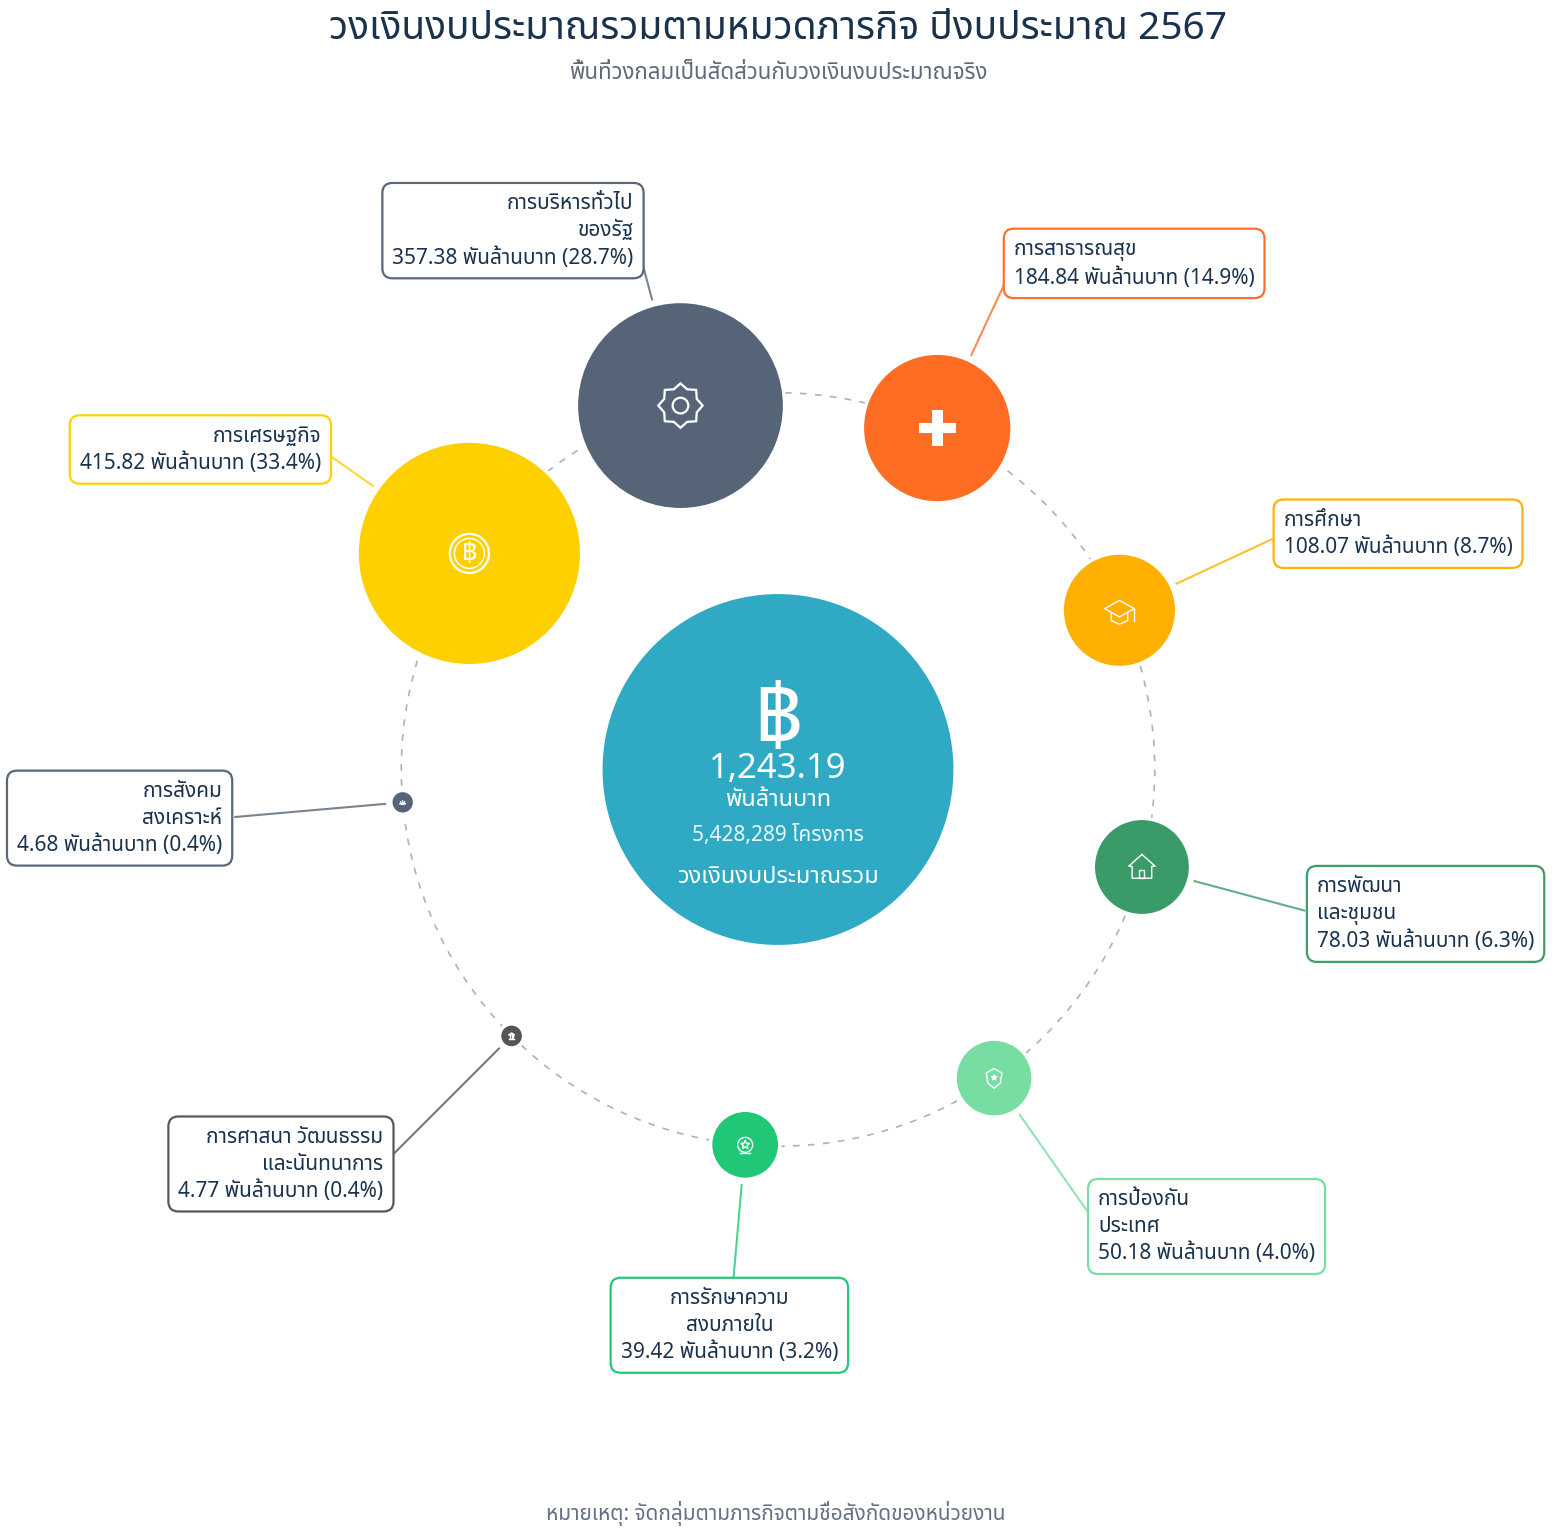

✅ ปิด Figure และ cleanup Object ชั่วคราวของกราฟแล้ว


In [24]:
# ============================================================
# VISUALIZATION : วงเงินงบประมาณรวมตามหมวดภารกิจ (Icon Orbit)
# ใช้ข้อมูลจาก function_budget_summary_df ที่สร้างในขั้นตอนก่อนหน้า
# ============================================================

import re
from matplotlib.patches import Circle, Polygon


# ============================================================
# 1) ใช้ปี โฟลเดอร์ และรูปแบบตัวอักษรจาก Cell SETUP
# ============================================================

# YEAR, figure_path, thai_font และ SVG Font ถูกกำหนดไว้ส่วนกลางแล้ว


# ============================================================
# 2) ตรวจ RAM ก่อนสร้างกราฟ
# ============================================================

try:
    import psutil

    _mission_ram_percent = psutil.virtual_memory().percent
    print(f"RAM ที่กำลังใช้งานก่อนสร้างกราฟ: {_mission_ram_percent:.1f}%")
    if _mission_ram_percent >= 80:
        gc.collect()
        print("RAM ตั้งแต่ 80% ขึ้นไป: cleanup แล้ว และจะใช้เฉพาะตารางสรุปขนาดเล็ก")
except ImportError:
    _mission_ram_percent = None


# ============================================================
# 3) รับข้อมูลสรุป โดยไม่คัดลอก project_overview_df ขนาดใหญ่
# ============================================================

if "function_budget_summary_df" in globals():
    _mission_required = {"หมวดภารกิจ", "วงเงินรวม (บาท)"}
    _mission_missing = _mission_required.difference(function_budget_summary_df.columns)

    if _mission_missing:
        raise KeyError(
            "function_budget_summary_df ขาดคอลัมน์: "
            + ", ".join(sorted(_mission_missing))
        )

    _mission_source = function_budget_summary_df.loc[
        :, [
            column for column in (
                "หมวดภารกิจ",
                "จำนวนโครงการ",
                "วงเงินรวม (บาท)"
            )
            if column in function_budget_summary_df.columns
        ]
    ]

elif "function_groups" in globals():
    # ใช้ได้ในกรณีมีเฉพาะ list ชื่อ function_groups จากขั้นตอนก่อนหน้า
    _mission_source = pd.DataFrame(
        {
            "หมวดภารกิจ": [item["name"] for item in function_groups],
            "วงเงินรวม (บาท)": [item["value"] for item in function_groups]
        }
    )

else:
    raise NameError(
        "กรุณารัน Code จัดหมวดภารกิจก่อน เพื่อสร้าง "
        "function_budget_summary_df หรือ function_groups"
    )


def _mission_normalize_name(value):
    """ปรับชื่อให้เทียบกันได้ แม้มีเว้นวรรคหรือขึ้นบรรทัดใหม่"""
    return re.sub(r"\s+", "", str(value).strip())


# ชื่อ สี ไอคอน และข้อความที่ต้องการแสดงของทั้ง 9 หมวด
_mission_specs = [
    {
        "name": "การเศรษฐกิจ",
        "aliases": ("การเศรษฐกิจ",),
        "display": "การเศรษฐกิจ",
        "color": "#FFD000",
        "icon": "economy"
    },
    {
        "name": "การรักษาความสงบภายใน",
        "aliases": ("การรักษาความสงบภายใน",),
        "display": "การรักษาความ\nสงบภายใน",
        "color": "#20C777",
        "icon": "peace"
    },
    {
        "name": "การป้องกันประเทศ",
        "aliases": ("การป้องกันประเทศ",),
        "display": "การป้องกัน\nประเทศ",
        "color": "#77DDA2",
        "icon": "defense"
    },
    {
        "name": "การบริหารทั่วไปของรัฐ",
        "aliases": ("การบริหารทั่วไปของรัฐ", "การบริหารทั่วไป"),
        "display": "การบริหารทั่วไป\nของรัฐ",
        "color": "#566477",
        "icon": "administration"
    },
    {
        "name": "การสังคมสงเคราะห์",
        "aliases": ("การสังคมสงเคราะห์", "สังคมสงเคราะห์"),
        "display": "การสังคม\nสงเคราะห์",
        "color": "#566477",
        "icon": "welfare"
    },
    {
        "name": "การศึกษา",
        "aliases": ("การศึกษา",),
        "display": "การศึกษา",
        "color": "#FFB000",
        "icon": "education"
    },
    {
        "name": "การศาสนา วัฒนธรรมและนันทนาการ",
        "aliases": (
            "การศาสนา วัฒนธรรมและนันทนาการ",
            "การศาสนาวัฒนธรรมและนันทนาการ"
        ),
        "display": "การศาสนา วัฒนธรรม\nและนันทนาการ",
        "color": "#555555",
        "icon": "culture"
    },
    {
        "name": "การสาธารณสุข",
        "aliases": ("การสาธารณสุข", "สาธารณสุข"),
        "display": "การสาธารณสุข",
        "color": "#FF6D24",
        "icon": "health"
    },
    {
        "name": "การพัฒนาและชุมชน",
        "aliases": (
            "การพัฒนาและชุมชน",
            "การเคหะและชุมชน",
            "การเคหะและการพัฒนาชุมชน"
        ),
        "display": "การพัฒนา\nและชุมชน",
        "color": "#3A9B68",
        "icon": "housing"
    }
]

_mission_alias_to_name = {}
for _mission_spec in _mission_specs:
    for _mission_alias in _mission_spec["aliases"]:
        _mission_alias_to_name[_mission_normalize_name(_mission_alias)] = _mission_spec["name"]

_mission_budget_lookup = {spec["name"]: 0.0 for spec in _mission_specs}
_mission_count_lookup = {spec["name"]: 0 for spec in _mission_specs}
_mission_unmatched = []

# หา Index ของคอลัมน์เพียงครั้งเดียวก่อนเริ่ม Loop
_mission_columns = list(_mission_source.columns)
_mission_name_index = _mission_columns.index("หมวดภารกิจ")
_mission_budget_index = _mission_columns.index("วงเงินรวม (บาท)")
_mission_count_index = (
    _mission_columns.index("จำนวนโครงการ")
    if "จำนวนโครงการ" in _mission_columns
    else None
)

for _mission_row in _mission_source.itertuples(index=False, name=None):
    _mission_name = _mission_row[_mission_name_index]
    _mission_key = _mission_alias_to_name.get(
        _mission_normalize_name(_mission_name)
    )

    if _mission_key is None:
        _mission_unmatched.append(str(_mission_name))
        continue

    _mission_budget = pd.to_numeric(
        _mission_row[_mission_budget_index],
        errors="coerce"
    )
    if pd.notna(_mission_budget):
        _mission_budget_lookup[_mission_key] += float(_mission_budget)

    if _mission_count_index is not None:
        _mission_count = pd.to_numeric(
            _mission_row[_mission_count_index],
            errors="coerce"
        )
        if pd.notna(_mission_count):
            _mission_count_lookup[_mission_key] += int(_mission_count)

if _mission_unmatched:
    raise ValueError(
        "พบชื่อหมวดภารกิจที่ยังไม่ได้กำหนด alias: "
        + ", ".join(sorted(set(_mission_unmatched)))
    )

_mission_rows = []
for _mission_spec in _mission_specs:
    _mission_rows.append(
        {
            **_mission_spec,
            "value": _mission_budget_lookup[_mission_spec["name"]],
            "project_count": _mission_count_lookup[_mission_spec["name"]]
        }
    )

# เรียงวงกลมจากวงเงินมากไปน้อย เพื่อให้เปรียบเทียบได้สะดวกทุกปี
_mission_rows.sort(key=lambda item: item["value"], reverse=True)

_mission_total = sum(item["value"] for item in _mission_rows)
_mission_total_projects = sum(item["project_count"] for item in _mission_rows)

if _mission_total <= 0:
    raise ValueError("วงเงินรวมต้องมากกว่า 0 จึงจะสร้างกราฟได้")

for _mission_item in _mission_rows:
    _mission_item["share"] = _mission_item["value"] / _mission_total * 100


# ============================================================
# 4) ฟังก์ชันวาดไอคอน Vector ไม่ต้องใช้ไฟล์ PNG/SVG ภายนอก
# ============================================================

def _mission_star_points(x, y, outer_radius, inner_radius, points=5):
    angles = np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, points * 2, endpoint=False)
    radii = np.where(np.arange(points * 2) % 2 == 0, outer_radius, inner_radius)
    return np.column_stack((x + radii * np.cos(angles), y + radii * np.sin(angles)))


def _mission_draw_icon(ax, x, y, icon_type, scale=1.0, color="white"):
    """วาดไอคอนด้วย Matplotlib เพื่อให้คมชัดทั้ง PNG และ SVG"""
    lw = max(1.0, 1.8 * scale)

    if icon_type == "economy":
        ax.add_patch(Circle((x, y), 0.30 * scale, fill=False, ec=color, lw=lw, zorder=12))
        ax.add_patch(Circle((x, y), 0.23 * scale, fill=False, ec=color, lw=lw * 0.65, zorder=12))
        ax.text(x, y, "฿", ha="center", va="center", color=color,
                fontsize=max(15, 12 + 8 * scale), fontweight="bold", zorder=13)

    elif icon_type == "peace":
        ax.add_patch(Circle((x, y), 0.30 * scale, fill=False, ec=color, lw=lw, zorder=12))
        star = _mission_star_points(x, y, 0.19 * scale, 0.08 * scale)
        ax.add_patch(Polygon(star, closed=True, fill=False, ec=color, lw=lw, zorder=12))
        ax.plot([x - 0.20 * scale, x + 0.20 * scale],
                [y - 0.34 * scale, y - 0.34 * scale], color=color, lw=lw, zorder=12)

    elif icon_type == "defense":
        shield = np.array([
            [x, y + 0.34 * scale],
            [x + 0.28 * scale, y + 0.18 * scale],
            [x + 0.22 * scale, y - 0.18 * scale],
            [x, y - 0.36 * scale],
            [x - 0.22 * scale, y - 0.18 * scale],
            [x - 0.28 * scale, y + 0.18 * scale]
        ])
        ax.add_patch(Polygon(shield, closed=True, fill=False, ec=color, lw=lw, zorder=12))
        star = _mission_star_points(x, y + 0.02 * scale, 0.12 * scale, 0.05 * scale)
        ax.add_patch(Polygon(star, closed=True, fc=color, ec=color, lw=0.5, zorder=12))

    elif icon_type == "administration":
        angles = np.linspace(0, 2 * np.pi, 16, endpoint=False)
        radii = np.where(np.arange(16) % 2 == 0, 0.34 * scale, 0.27 * scale)
        points = np.column_stack((x + radii * np.cos(angles), y + radii * np.sin(angles)))
        ax.add_patch(Polygon(points, closed=True, fill=False, ec=color, lw=lw, zorder=12))
        ax.add_patch(Circle((x, y), 0.12 * scale, fill=False, ec=color, lw=lw, zorder=12))

    elif icon_type == "welfare":
        ax.add_patch(Circle((x, y + 0.15 * scale), 0.10 * scale, fc=color, ec="none", zorder=12))
        ax.add_patch(Circle((x - 0.23 * scale, y + 0.08 * scale), 0.075 * scale, fc=color, ec="none", zorder=12))
        ax.add_patch(Circle((x + 0.23 * scale, y + 0.08 * scale), 0.075 * scale, fc=color, ec="none", zorder=12))
        ax.plot([x - 0.14 * scale, x, x + 0.14 * scale],
                [y - 0.22 * scale, y - 0.05 * scale, y - 0.22 * scale],
                color=color, lw=lw * 1.5, solid_capstyle="round", zorder=12)
        ax.plot([x - 0.34 * scale, x - 0.23 * scale, x - 0.12 * scale],
                [y - 0.18 * scale, y - 0.06 * scale, y - 0.18 * scale],
                color=color, lw=lw, solid_capstyle="round", zorder=12)
        ax.plot([x + 0.12 * scale, x + 0.23 * scale, x + 0.34 * scale],
                [y - 0.18 * scale, y - 0.06 * scale, y - 0.18 * scale],
                color=color, lw=lw, solid_capstyle="round", zorder=12)

    elif icon_type == "education":
        cap = np.array([
            [x, y + 0.24 * scale],
            [x + 0.36 * scale, y + 0.04 * scale],
            [x, y - 0.16 * scale],
            [x - 0.36 * scale, y + 0.04 * scale]
        ])
        ax.add_patch(Polygon(cap, closed=True, fill=False, ec=color, lw=lw, zorder=12))
        ax.plot([x - 0.20 * scale, x - 0.20 * scale, x, x + 0.20 * scale, x + 0.20 * scale],
                [y - 0.06 * scale, y - 0.25 * scale, y - 0.34 * scale,
                 y - 0.25 * scale, y - 0.06 * scale], color=color, lw=lw, zorder=12)
        ax.plot([x + 0.36 * scale, x + 0.36 * scale],
                [y + 0.04 * scale, y - 0.25 * scale], color=color, lw=lw, zorder=12)

    elif icon_type == "culture":
        roof = np.array([
            [x, y + 0.34 * scale],
            [x + 0.36 * scale, y + 0.10 * scale],
            [x - 0.36 * scale, y + 0.10 * scale]
        ])
        ax.add_patch(Polygon(roof, closed=True, fill=False, ec=color, lw=lw, zorder=12))
        ax.plot([x - 0.30 * scale, x + 0.30 * scale],
                [y - 0.30 * scale, y - 0.30 * scale], color=color, lw=lw, zorder=12)
        for offset in (-0.21, 0.0, 0.21):
            ax.plot([x + offset * scale, x + offset * scale],
                    [y - 0.25 * scale, y + 0.06 * scale], color=color, lw=lw, zorder=12)

    elif icon_type == "health":
        ax.add_patch(Rectangle((x - 0.10 * scale, y - 0.34 * scale),
                               0.20 * scale, 0.68 * scale,
                               fc=color, ec="none", zorder=12))
        ax.add_patch(Rectangle((x - 0.34 * scale, y - 0.10 * scale),
                               0.68 * scale, 0.20 * scale,
                               fc=color, ec="none", zorder=12))

    elif icon_type == "housing":
        roof = np.array([
            [x, y + 0.36 * scale],
            [x + 0.38 * scale, y + 0.02 * scale],
            [x + 0.28 * scale, y + 0.02 * scale],
            [x + 0.28 * scale, y - 0.32 * scale],
            [x - 0.28 * scale, y - 0.32 * scale],
            [x - 0.28 * scale, y + 0.02 * scale],
            [x - 0.38 * scale, y + 0.02 * scale]
        ])
        ax.add_patch(Polygon(roof, closed=True, fill=False, ec=color, lw=lw, zorder=12))
        ax.add_patch(Rectangle((x - 0.07 * scale, y - 0.32 * scale),
                               0.14 * scale, 0.23 * scale,
                               fill=False, ec=color, lw=lw, zorder=12))


# ============================================================
# 5) คำนวณขนาด Bubble โดยให้พื้นที่เทียบกับงบจริง
# ============================================================

_mission_values = np.array([item["value"] for item in _mission_rows], dtype=float)
_mission_max_value = _mission_values.max()
_mission_max_radius = 1.55

if _mission_max_value <= 0:
    raise ValueError("ไม่พบวงเงินที่มากกว่า 0")


def _mission_value_to_radius(value):
    """
    ให้พื้นที่วงกลมแปรผันตรงกับวงเงินงบประมาณจริง
    เพราะ area = pi * radius**2 จึงต้องใช้ square root กับค่าเงิน
    """
    if value <= 0:
        return 0.0
    return _mission_max_radius * np.sqrt(value / _mission_max_value)


for _mission_item in _mission_rows:
    _mission_item["radius"] = _mission_value_to_radius(_mission_item["value"])


# ============================================================
# 6) สร้างกราฟวงโคจรพร้อมไอคอน
# ============================================================

_mission_fig, _mission_ax = plt.subplots(figsize=(16, 16), facecolor="white")
_mission_ax.set_facecolor("white")
_mission_ax.set_aspect("equal")
_mission_ax.axis("off")

_mission_orbit_radius = 5.20
_mission_center_radius = 2.45

_mission_ax.add_patch(
    Circle(
        (0, 0),
        _mission_orbit_radius,
        fill=False,
        linestyle=(0, (4, 5)),
        linewidth=1.2,
        edgecolor="#A8B3BF",
        zorder=1
    )
)

_mission_ax.add_patch(
    Circle(
        (0, 0),
        _mission_center_radius,
        facecolor="#2FA9C4",
        edgecolor="white",
        linewidth=3,
        zorder=2
    )
)

_mission_ax.text(
    0, 0.66, "฿",
    ha="center", va="center",
    fontsize=61, fontweight="bold", color="white", zorder=4
)
_mission_ax.text(
    0, 0.02, f"{_mission_total / 1e9:,.2f}",
    ha="center", va="center",
    fontsize=25, fontweight="bold", color="white", zorder=4
)
_mission_ax.text(
    0, -0.42, "พันล้านบาท",
    ha="center", va="center",
    fontsize=17, color="white", zorder=4
)

if _mission_total_projects > 0:
    _mission_ax.text(
        0, -0.90, f"{_mission_total_projects:,.0f} โครงการ",
        ha="center", va="center",
        fontsize=15, color="#EAF8FB", zorder=4
    )

_mission_ax.text(
    0, -1.48, "วงเงินงบประมาณรวม",
    ha="center", va="center",
    fontsize=17, fontweight="bold", color="white", zorder=4
)

# เริ่มจากด้านซ้ายบนและเรียงตามเข็มนาฬิกา
_mission_angles = np.linspace(145, 145 - 360, len(_mission_rows), endpoint=False)

for _mission_angle, _mission_item in zip(_mission_angles, _mission_rows):
    _mission_rad = np.deg2rad(_mission_angle)
    _mission_x = _mission_orbit_radius * np.cos(_mission_rad)
    _mission_y = _mission_orbit_radius * np.sin(_mission_rad)
    _mission_radius = _mission_item["radius"]

    _mission_ax.add_patch(
        Circle(
            (_mission_x, _mission_y),
            _mission_radius,
            facecolor=_mission_item["color"],
            edgecolor="white",
            linewidth=2.5,
            zorder=3
        )
    )

    # ไอคอนปรับตามขนาดจริงของ Bubble และไม่กำหนดขนาดขั้นต่ำ
    # เพื่อไม่ทำให้หมวดที่มีงบน้อยดูใหญ่เกินจริง
    if _mission_radius > 0:
        _mission_icon_scale = min(_mission_radius * 0.72, 0.90)
        _mission_draw_icon(
            _mission_ax,
            _mission_x,
            _mission_y,
            _mission_item["icon"],
            scale=_mission_icon_scale,
            color="white"
        )

    # ใช้ระยะกล่องคงที่ เพื่อให้ข้อความเรียงสมดุลและไม่ชน Bubble ใหญ่
    _mission_label_distance = (
        _mission_orbit_radius + _mission_max_radius + 0.95
    )
    _mission_label_x = _mission_label_distance * np.cos(_mission_rad)
    _mission_label_y = _mission_label_distance * np.sin(_mission_rad)

    # เส้นเชื่อมจากขอบ Bubble ไปยังกล่องข้อความ
    _mission_line_start = _mission_orbit_radius + _mission_radius + 0.08
    _mission_line_end = _mission_label_distance - 0.18
    _mission_ax.plot(
        [
            _mission_line_start * np.cos(_mission_rad),
            _mission_line_end * np.cos(_mission_rad)
        ],
        [
            _mission_line_start * np.sin(_mission_rad),
            _mission_line_end * np.sin(_mission_rad)
        ],
        color=_mission_item["color"],
        linewidth=1.5,
        alpha=0.80,
        zorder=2
    )

    if _mission_label_x > 0.75:
        _mission_ha = "left"
    elif _mission_label_x < -0.75:
        _mission_ha = "right"
    else:
        _mission_ha = "center"

    _mission_ax.text(
        _mission_label_x,
        _mission_label_y,
        (
            f"{_mission_item['display']}\n"
            f"{_mission_item['value'] / 1e9:,.2f} พันล้านบาท "
            f"({_mission_item['share']:.1f}%)"
        ),
        ha=_mission_ha,
        va="center",
        fontsize=15,
        linespacing=1.35,
        fontweight="bold",
        color="#19324D",
        bbox={
            "boxstyle": "round,pad=0.48",
            "facecolor": "white",
            "edgecolor": _mission_item["color"],
            "linewidth": 1.6,
            "alpha": 0.98
        },
        zorder=14
    )


# ============================================================
# 7) ชื่อกราฟ คำอธิบาย และพื้นที่แสดงผล
# ============================================================

_mission_fig.suptitle(
    f"วงเงินงบประมาณรวมตามหมวดภารกิจ ปีงบประมาณ {YEAR}",
    fontsize=28,
    fontweight="bold",
    color="#19324D",
    y=0.975
)

_mission_fig.text(
    0.5, 0.935,
    "พื้นที่วงกลมเป็นสัดส่วนกับวงเงินงบประมาณจริง",
    ha="center", va="center",
    fontsize=16,
    color="#5F6B7A"
)

_mission_fig.text(
    0.5, 0.035,
    "หมายเหตุ: จัดกลุ่มตามภารกิจตามชื่อสังกัดของหน่วยงาน " ,
    ha="center", va="center",
    fontsize=15,
    color="#667085"
)

_mission_ax.set_xlim(-10.60, 10.60)
_mission_ax.set_ylim(-8.70, 8.70)
_mission_fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.10)


# ============================================================
# 8) GitHub Version: แสดงผลโดยไม่บันทึก SVG และ PNG
# ============================================================

_mission_svg_file, _mission_png_file = figure_files(
    "10_budget_by_function_with_icons"
)

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์

plt.show()
plt.close(_mission_fig)

pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์
pass  # GitHub version: แสดงผลอย่างเดียว ไม่เขียนไฟล์


# ============================================================
# 9) Cleanup เฉพาะ Object ชั่วคราวของกราฟ
# ============================================================

del _mission_source
del _mission_values, _mission_rows
gc.collect()

print("✅ ปิด Figure และ cleanup Object ชั่วคราวของกราฟแล้ว")
